In [ ]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=3, g=14, r=29):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    ax.axis("off")
    im = ax.imshow(img)  # 画像を表示
    plt.show()

# 指定した座標 (x, y) でのスペクトルデータを表示するための関数
def show_spectral(img, param, y, x): 
    fig, ax = plt.subplots()  # fig と ax を定義
    ax.plot(param[ 0: 58,0], img[y, x,  0: 58], label="VNIR Spectrum", color="r");
    ax.plot(param[58:185,0], img[y, x, 58:185], label="SWIR Spectrum", color="g");
    ax.tick_params(labelsize=16)
    ax.legend();    plt.tight_layout(); plt.show()

#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Utility
# =========================
def _find_col(df: pd.DataFrame, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    raise KeyError(f"Columns not found. candidates={candidates}, available={list(df.columns)}")

def load_modtran_csv(modtran_csv_path: str):
    """
    MODTRAN csv を読み込み、(wavelength_nm, Y, spec_cols) を返す。
    - wavelength_nm: (n_w,)
    - Y: (n_spec, n_w)  ※各スペクトル列を行方向に
    """
    df = pd.read_csv(modtran_csv_path)

    wl_col = None
    for key in ["waveln", "wavelength", "lambda", "wl", "nm"]:
        for c in df.columns:
            if c.lower() == key:
                wl_col = c
                break
        if wl_col is not None:
            break
    if wl_col is None:
        wl_col = df.columns[0]  # 最悪は先頭列を波長とみなす

    w = pd.to_numeric(df[wl_col], errors="coerce").to_numpy(dtype=float)

    spec_cols = [c for c in df.columns if c != wl_col]
    Y = df[spec_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float).T  # (n_spec, n_w)

    # 波長がNaNの行を落とす
    m = np.isfinite(w)
    w = w[m]
    Y = Y[:, m]

    # 波長が昇順でない場合はソート
    if np.any(np.diff(w) < 0):
        idx = np.argsort(w)
        w = w[idx]
        Y = Y[:, idx]

    return w, Y, spec_cols

def load_hisui_band_csv(hisui_csv_path: str):
    """
    HISUI band csv から中心波長[nm]とFWHM[nm]を読み込む
    """
    df = pd.read_csv(hisui_csv_path)
    c_col = _find_col(df, ["CenterWavelengthNanometer", "centerwavelengthnanometer", "CenterWavelength", "center"])
    f_col = _find_col(df, ["FullWidthAtHalfMaximumNanometer", "fullwidthathalfmaximumnanometer", "FWHM", "fwhm"])

    centers = pd.to_numeric(df[c_col], errors="coerce").to_numpy(dtype=float)
    fwhm = pd.to_numeric(df[f_col], errors="coerce").to_numpy(dtype=float)

    m = np.isfinite(centers) & np.isfinite(fwhm)
    return centers[m], fwhm[m]

def fwhm_to_sigma(fwhm_nm: float) -> float:
    # FWHM = 2*sqrt(2*ln2)*sigma
    return float(fwhm_nm) / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def gaussian_ils_resample_allbands(
    w_nm: np.ndarray,
    Y: np.ndarray,                 # (n_spec, n_w)
    centers_nm: np.ndarray,         # (n_band,)
    fwhm_nm: np.ndarray,            # (n_band,)
    mu_nm: float = 0.0,
    nsigma: float = 5.0,
):
    """
    各HISUIバンド中心ごとに、ガウスILS(σはFWHMから変換)で重み付け積分して値を出す。
    返り値:
      centers_valid, out (n_spec, n_validband)
    """
    w_nm = np.asarray(w_nm, dtype=float)
    Y = np.asarray(Y, dtype=float)
    centers_nm = np.asarray(centers_nm, dtype=float)
    fwhm_nm = np.asarray(fwhm_nm, dtype=float)

    # 不等間隔でも積分できるように Δλ を作る（台形則の簡易版）
    dw = np.empty_like(w_nm)
    dw[1:-1] = (w_nm[2:] - w_nm[:-2]) * 0.5
    dw[0] = (w_nm[1] - w_nm[0])
    dw[-1] = (w_nm[-1] - w_nm[-2])
    dw = np.abs(dw)

    # MODTRANの波長範囲内のバンドだけ使う（範囲外は捨てる）
    valid = (centers_nm >= w_nm.min()) & (centers_nm <= w_nm.max()) & np.isfinite(fwhm_nm) & (fwhm_nm > 0)
    c = centers_nm[valid]
    f = fwhm_nm[valid]

    out = np.full((Y.shape[0], c.size), np.nan, dtype=float)

    for j, (cj, fj) in enumerate(zip(c, f)):
        sigma = max(fwhm_to_sigma(fj), 1e-9)
        center = cj + mu_nm

        # カーネルは±nsigmaσの範囲だけで計算（高速化）
        m = np.abs(w_nm - center) <= (nsigma * sigma)
        if not np.any(m):
            continue

        g = np.exp(-0.5 * ((w_nm[m] - center) / sigma) ** 2)
        wgt = g * dw[m]
        denom = wgt.sum()
        if denom <= 0:
            continue

        # (n_spec, n_sel) @ (n_sel,) -> (n_spec,)
        out[:, j] = (Y[:, m] @ wgt) / denom

    return c, out  # centers_valid, band_values

def save_resampled_csv(out_csv_path: str, centers_nm: np.ndarray, band_values: np.ndarray, spec_cols):
    """
    出力をCSV保存（行=バンド、列=各スペクトル）
    """
    df_out = pd.DataFrame({"wavelength_nm": centers_nm})
    for i, col in enumerate(spec_cols):
        df_out[col] = band_values[i, :]
    df_out.to_csv(out_csv_path, index=False)
    return df_out

def plot_alignment_demo(w_nm, y_raw, centers_nm, y_band, out_path_png=None, xlim=None, title=""):
    """
    生スペクトルと「HISUI波長に合わせた点（サンプル）」を確認するための簡易プロット
    """
    fig = plt.figure(figsize=(10, 4), dpi=200)
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(w_nm, y_raw, linewidth=1.0, label="MODTRAN raw")
    ax.scatter(centers_nm, y_band, s=12, label="Resampled at HISUI bands")
    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Intensity [a.u.]")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    if xlim is not None:
        ax.set_xlim(*xlim)
    fig.tight_layout()
    if out_path_png:
        fig.savefig(out_path_png, bbox_inches="tight")
    plt.close(fig)

# =========================
# Main (paths)
# =========================
if __name__ == "__main__":
    MODTRAN_CSV = r"E:\refit\water_lut\2.0.csv"
    HISUI_BAND_CSV = r"E:\メタン\HSHL1G_N364E1407_20210810004959_20220830154054_B.csv"

    w_nm, Y, spec_cols = load_modtran_csv(MODTRAN_CSV)
    centers_nm, fwhm_nm = load_hisui_band_csv(HISUI_BAND_CSV)

    # 波長全体に対してHISUIバンドへ変換（バンドごとにσが変わる）
    centers_valid, Y_hisui = gaussian_ils_resample_allbands(
        w_nm, Y, centers_nm, fwhm_nm,
        mu_nm=0.0,   # 必要ならシフト
        nsigma=5.0,  # カーネル幅
    )

    # 保存
    OUT_CSV = "modtran_on_hisui_allbands.csv"
    df_out = save_resampled_csv(OUT_CSV, centers_valid, Y_hisui, spec_cols)
    print("Saved:", OUT_CSV, " shape=", df_out.shape)

    # 図：例として最初のスペクトル列を可視化（SWIR1っぽい範囲）
    demo_col = 0  # 0番目のスペクトル
    plot_alignment_demo(
        w_nm, Y[demo_col],
        centers_valid, Y_hisui[demo_col],
        out_path_png="demo_modtran_to_hisui.png",
        xlim=(1500, 1800),
        title="MODTRAN → HISUI (Gaussian ILS per-band)"
    )
    print("Saved: demo_modtran_to_hisui.png")


Saved: modtran_on_hisui_allbands.csv  shape= (185, 22)
Saved: demo_modtran_to_hisui.png


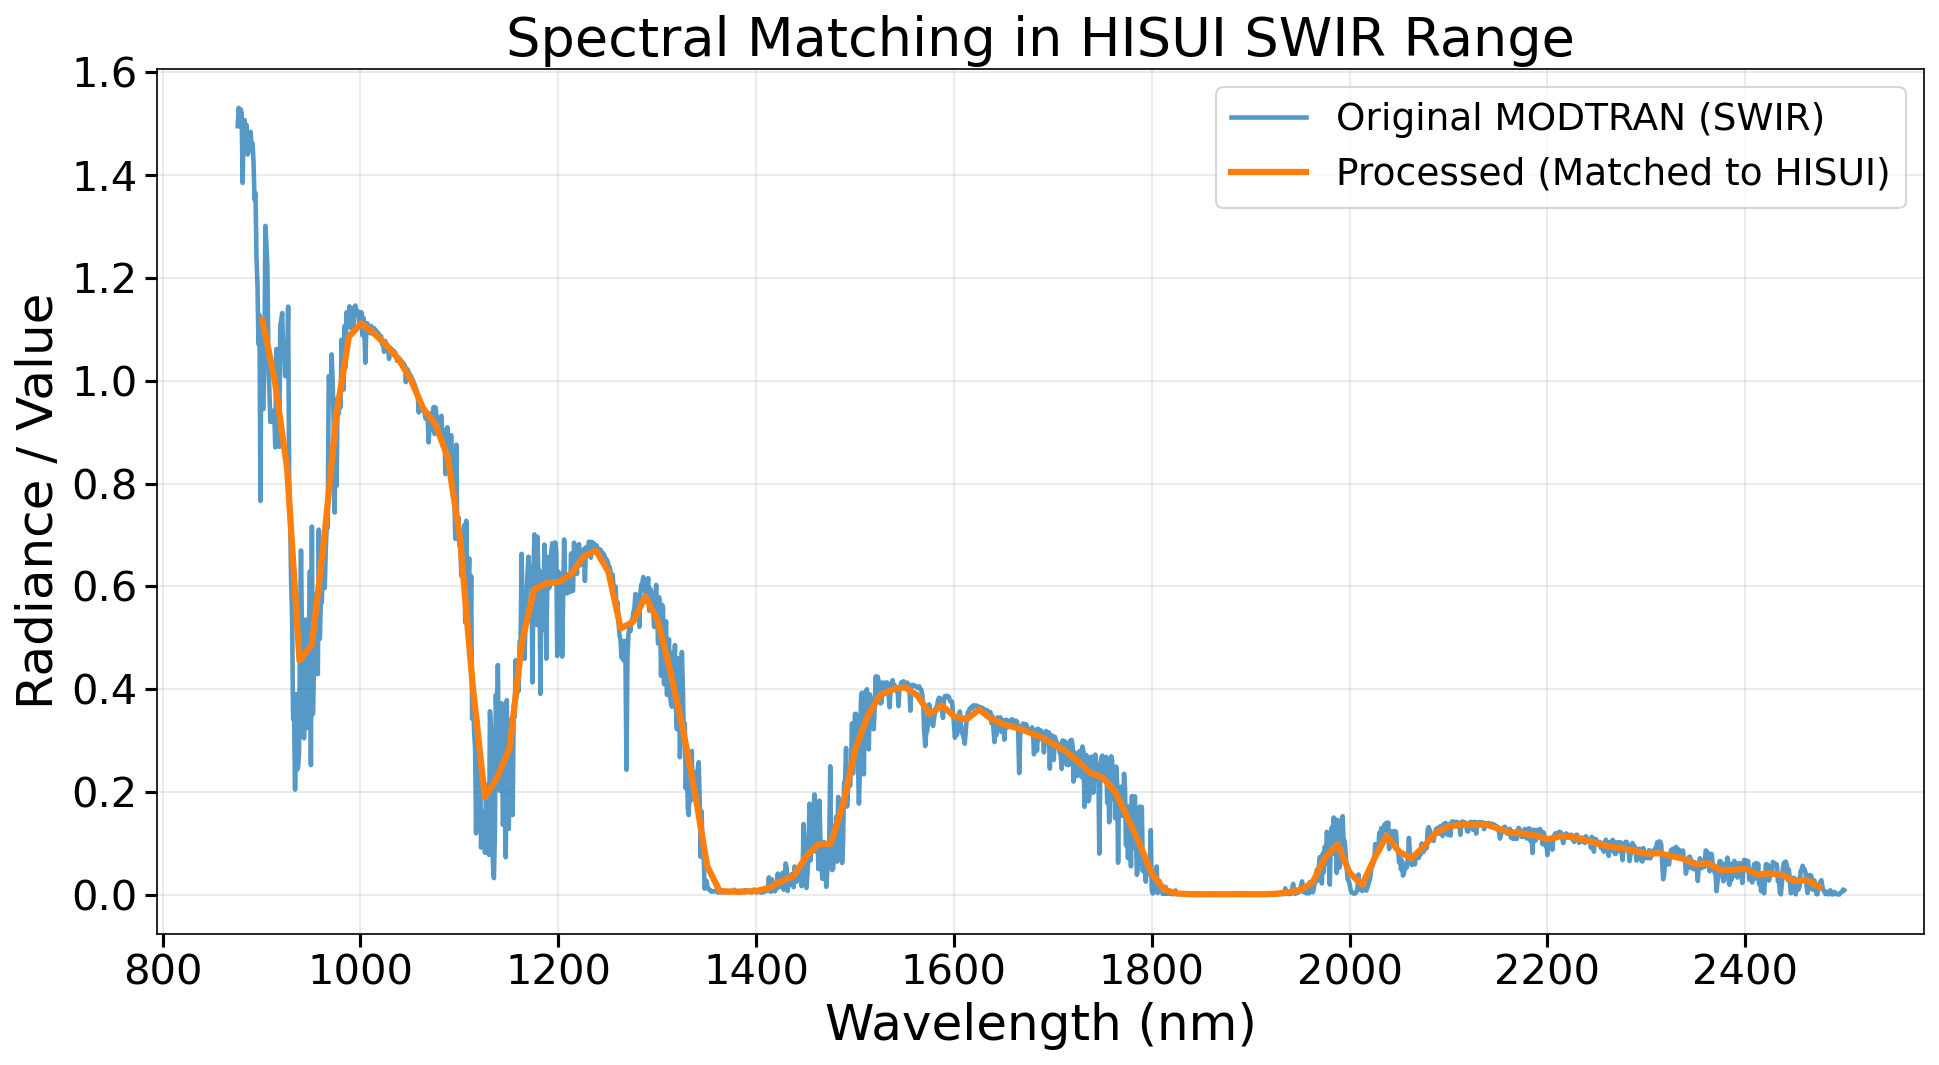

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PPT向け：文字・線を大きく（最重要）
# =========================
plt.rcParams.update({
    "font.size": 20,        # 全体の基準フォント
    "axes.titlesize": 26,   # タイトル
    "axes.labelsize": 24,   # 軸ラベル
    "xtick.labelsize": 20,  # 目盛り
    "ytick.labelsize": 20,
    "legend.fontsize": 18,  # 凡例
})

def instrumental_function(data, sigma, mu):
    column, row = data.shape
    x = data[0, :]
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

# ---------------------------------------------------------
# メイン処理
# ---------------------------------------------------------
pixel_file = r"E:\新しいフォルダー\pixel_1000_1000.csv"
modtran_file = r"E:\refit\water_lut\1.1.csv"

df_pixel = pd.read_csv(pixel_file)
df_modtran = pd.read_csv(modtran_file)

wavelengths_hisui = df_pixel["Wavelength (nm)"].values
wavelengths_modtran = df_modtran['waveln'].values
spectrum_modtran_raw = df_modtran['2'].values

min_wave = wavelengths_hisui.min()
max_wave = wavelengths_hisui.max()

sigma = 6.5
mu = 0.0
buffer = 4 * sigma

mask_mod = (wavelengths_modtran >= (min_wave - buffer)) & (wavelengths_modtran <= (max_wave + buffer))
wavelengths_modtran_swir = wavelengths_modtran[mask_mod]
spectrum_modtran_swir = spectrum_modtran_raw[mask_mod]

data_in = np.vstack([wavelengths_modtran_swir, spectrum_modtran_swir])
data_convolved = instrumental_function(data_in, sigma, mu)
spectrum_convolved = data_convolved[1, :]

spectrum_matched = np.interp(wavelengths_hisui, wavelengths_modtran_swir, spectrum_convolved)

# ---------------------------------------------------------
# プロット（PPT向けに調整）
# ---------------------------------------------------------
fig = plt.figure(figsize=(13.33, 7.5), dpi=150)  # 16:9（パワポ向け）
ax = fig.add_subplot(1, 1, 1)

ax.plot(wavelengths_modtran_swir, spectrum_modtran_swir,
        label='Original MODTRAN (SWIR)', alpha=0.75, linewidth=2.2)

ax.plot(wavelengths_hisui, spectrum_matched,
        label='Processed (Matched to HISUI)', linewidth=3.0)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Radiance / Value')
ax.set_title('Spectral Matching in HISUI SWIR Range')

ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.legend(loc="best", frameon=True)
fig.tight_layout()

# PPTに貼る用に高解像度で保存（推奨）
fig.savefig("spectral_matching_for_ppt.png", dpi=300, bbox_inches="tight")
# ベクターで欲しければこっちも便利
fig.savefig("spectral_matching_for_ppt.svg", bbox_inches="tight")

plt.show()


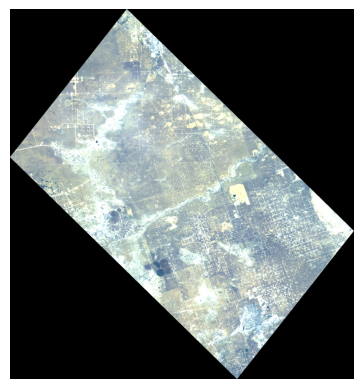

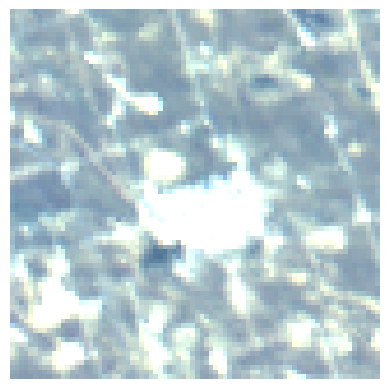

In [3]:
file = (r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif")
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1065, 1463]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 40 : center[0] + 40, center[1] -40 : center[1] + 40, :] #補正後の画像
ims_slice = ims[center[0] - 40 : center[0] +40, center[1] -40 : center[1] + 40, :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

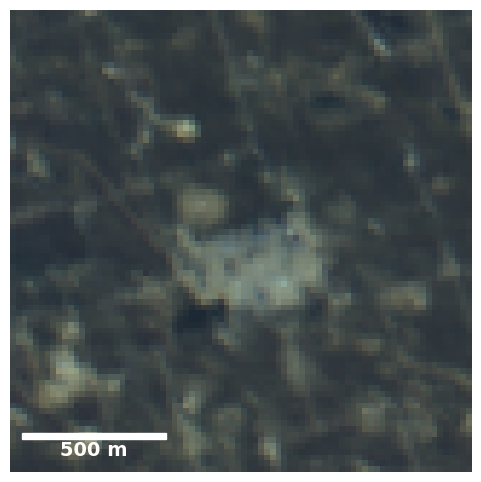

保存完了: hisui_slice_output.eps


In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# --- 設定項目 ---
resolution = 20       # 1ピクセルあたりのメートル数 (HISUIは20m)
scale_meters = 500    # スケールバーで表示したい距離 (例: 500m)
save_path = "hisui_slice_output.eps" # 保存ファイル名
# ----------------

# 1. 描画の準備
fig, ax = plt.subplots(figsize=(6, 6)) # 画像サイズは必要に応じて調整
ax.imshow(ims_slice)
ax.axis('off') # 軸の目盛り（ピクセル番号）を消して見栄えを良くする

# 2. スケールバーの作成
# 500m が何ピクセルになるか計算
scale_pixels = scale_meters / resolution 

# フォント設定（必要であればサイズ等を調整）
fontprops = fm.FontProperties(size=14, weight='bold')

# スケールバーオブジェクトの定義
scalebar = AnchoredSizeBar(
    ax.transData,
    scale_pixels,            # バーの長さ（ピクセル単位）
    f'{scale_meters} m',     # 表示するテキスト
    'lower left',            # 配置場所（左下）
    pad=0.5,                 # 画像の端からの隙間
    color='white',           # バーと文字の色（衛星画像上なら白が見やすい）
    frameon=False,           # 背景のボックスを表示するか（Falseなら透過）
    size_vertical=1,         # バーの太さ
    fontproperties=fontprops # フォント設定
)

# 3. 画像への追加と保存
ax.add_artist(scalebar)

# EPS形式で保存 (bbox_inches='tight'で余白を削除)
plt.savefig(save_path, format='eps', bbox_inches='tight', dpi=300)

# 画面表示
plt.show()

print(f"保存完了: {save_path}")

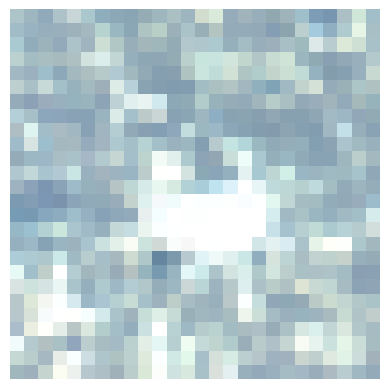

In [6]:
def average_pooling(img, G): #平均プーリング
    H, W, C = img.shape  
    Nh = H // G  
    Nw = W // G  
    out = np.zeros((Nh, Nw, C))
    for y in range(Nh):
        for x in range(Nw):
            for c in range(C):
                out[y,x,c] = np.mean(img[G*y:G*(y+1), G*x:G*(x+1), c])
    return out

def return_pooling(img, G):
    H, W, C = img.shape
    Nh = H * G  
    Nw = W * G  
    out = np.zeros((Nh, Nw, C))
    for y in range(H):
        for x in range(W):
            for c in range(C):
                out[G*y:G*(y+1), G*x:G*(x+1), c] = img[y,x,c]
    return out

img_slice_pooling = average_pooling(img_slice, G=3)
ims_slice_pooling = return_pooling(average_pooling(ims_slice, G=3), G=3)
show_img(ims_slice_pooling)

In [10]:
# =========================================================
# Output Filenames - !!! ここで保存ファイル名を編集 !!!
# =========================================================
OUTPUT_H2O_CSV = "estimated_h2o_pooling1250_550_19sml.csv"
OUTPUT_CH4_PPM_CSV = "estimated_ch4_ppm_pooling1250_550_19sml.csv"
OUTPUT_CH4_SIGMA_CSV = "estimated_ch4_sigma_pooling1250_550_19sml.csv" # «-- シグマCSV保存用
OUTPUT_CH4_PPM_MAP = "estimated_ch4_map_pooling1250_550_19sml.png"
OUTPUT_CH4_SIGMA_MAP = "estimated_ch4_sigma_map_pooling1250_550_19sml.png" # «-- シグマMAP保存用
# =========================================================
#2200
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # «-- 変更: 進行度表示ライブラリtqdmをインポート

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
       ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
       ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)

# =========================================================
# CH4 (メタン) 推定関数群 (バグ対策省略版)
# =========================================================
hi_i = 110
hi_f = 119
mo_i = 1800
mo_f = 2121

def extract_ch4(data):
    # 基本的な形状チェックのみ
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return [] # Return empty list if no levels
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    # idx_lower は最低でも1になるはず (position=1 の場合)
    elif idx_lower < 1: # 念のためチェック
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()


    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return [] # Return empty list if cannot interpolate
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    # エラー時は大きな値を返すように try-except を維持
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェックも維持
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    # ゼロ除算等の基本的なチェックは維持
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # try-except も維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        # リスト空チェック、インデックス範囲チェック、ゼロ除算チェックも維持
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0


# =========================================================
# H2O (水蒸気) 推定関数群 (バグ対策省略版)
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    # try-except 維持
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェック維持
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        # *** ここに return が抜けていました ***
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    # try-except 維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :];
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        # インデックス範囲チェック維持
        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
           # print("Warn: Highlight index out of bounds in estimate_param_h2o") # Debug
           return 0.0, 0.0 # b, a

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        # ゼロ除算チェック維持
        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数 (バグ対策省略版)
# =========================================================
def instrumental_function(data, sigma, mu):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # sigma の最小値チェック維持
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # 負の値クランプ維持
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# *** ここから不足していた関数 ***
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    # フォールバックとして空で初期化
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 基本的なチェックは維持
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        if np.any(wavelength_row == 0):
           pass # warning は省略

        return data_ch4
    # FileNotFoundError などの基本的なエラー処理は維持
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        # print(f"Error loading/processing LUT {filepath}: {e}") # Debugging
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (エラー処理省略版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel (simplified error handling). """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4 # LUT なし

    start_time = time.time()
    
    # «-- 変更: tqdmを使用して行(y)のループにプログレスバーを追加
    print(f"Starting pixel processing for {H}x{W} image...")
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        last_ch4_lut_idx = None
        for x in range(W):
            try: # ピクセル単位のエラー捕捉は維持
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ================================================================
                # *** (CH4推定は2段階のまま - 変更なし) ***
                # ================================================================

                # ---- CH4 (Step 1: Sigma Estimation) ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                # 1回目: 元の初期値(sigma=6.0)で実行
                a0_sigma_est = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_sigma_est = least_squares(residuals_ch4, a0_sigma_est, args=(data_ch4, df_hisui), method="lm")
                
                # 1回目の実行から推定されたシグマを取得
                estimated_sigma = float(res_sigma_est.x[0])
                
                # ---- CH4 (Step 2: Methane Estimation using new sigma) ----
                # 2回目: 1回目で得られたシグマ(estimated_sigma)を初期値として再度実行
                a0_ch4_final = np.array([estimated_sigma, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4_final, args=(data_ch4, df_hisui), method="lm")

                # ---- Save final results from Step 2 ----
                out_ch4[y, x, 0] = float(res_ch4.x[0])  # final sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # final mu
                ch4_ppm_est = float(res_ch4.x[4])      # final ch4 (ppm)
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))
                
            except Exception as e_pix:
                # ピクセル処理中のエラーは NaN のままにする (エラーメッセージ省略)
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN_count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN_count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4


try:
    # --- H2O LUT パス設定 & 読み込み ---
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # 要確認・修正
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # (省略)
    
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # (省略)
    # if 'img_slice_pooling' not in locals():
    #     ...
    # if 'param' not in locals():
    #     ...
    # === ダミーデータの例ここまで ===


    if 'img_slice_pooling' in locals() and 'param' in locals():
        print(f"Processing image with shape: {img_slice_pooling.shape}")

        # --- 推定実行 ---
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice_pooling, param, data_h2o_np,
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        sample_step = max(1, img_slice_pooling.shape[0] // 5) 
        print("H2O (sample):\n", out_h2o[::sample_step, ::sample_step, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        print("\nCH4 sigma (sample):\n", out_ch4[::sample_step, ::sample_step, 0]) # «-- シグマのサンプル表示追加
        
        # CSV保存 (ファイル名は先頭の変数定義で変更)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); 
        df_h2o.to_csv(OUTPUT_H2O_CSV, index=False, header=False, na_rep='NaN')
        
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); 
        df_ch4_ppm.to_csv(OUTPUT_CH4_PPM_CSV, index=False, header=False, na_rep='NaN')
        
        # «-- シグマ(Sigma)をCSVに保存するコードを追加 --»
        ch4_sigma_2d = out_ch4[:, :, 0] # インデックス0がシグマ
        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d); 
        df_ch4_sigma.to_csv(OUTPUT_CH4_SIGMA_CSV, index=False, header=False, na_rep='NaN')
        
        print(f"\nResults saved to CSV: {OUTPUT_H2O_CSV}, {OUTPUT_CH4_PPM_CSV}, {OUTPUT_CH4_SIGMA_CSV}")


        # --- マップ表示 (CH4 PPM) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig(OUTPUT_CH4_PPM_MAP, bbox_inches='tight') # «-- 変数を使用
            print(f"Map saved to '{OUTPUT_CH4_PPM_MAP}'.") # «-- 変数を使用
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate CH4 PPM map: {e_map}")

        # --- マップ表示 (CH4 Sigma) ---
        # «-- シグマ(Sigma)をマップ表示するコードを追加 --»
        try:
            ch4_sigma_map = out_ch4[:, :, 0] # インデックス0がシグマ
            ch4_sigma_map_filled = np.nan_to_num(ch4_sigma_map, nan=0.0) # NaNを0に
            
            interp = 'nearest' if max(ch4_sigma_map_filled.shape) < 100 else 'bilinear'
            
            fig_sigma, ax_sigma = plt.subplots(figsize=(8, 8))
            # シグマの値の範囲に合わせて cmap を 'viridis' や 'cividis' などに変更しても良い
            im_sigma = ax_sigma.imshow(ch4_sigma_map_filled, cmap='viridis', interpolation=interp) 
            cbar_sigma = fig_sigma.colorbar(im_sigma, ax=ax_sigma, fraction=0.046, pad=0.04)
            cbar_sigma.set_label('Estimated Sigma')
            ax_sigma.set_title('Estimated Methane Sigma Map')
            ax_sigma.axis('off')
            plt.savefig(OUTPUT_CH4_SIGMA_MAP, bbox_inches='tight') # «-- 変数を使用
            print(f"Map saved to '{OUTPUT_CH4_SIGMA_MAP}'.") # «-- 変数を使用
            plt.close(fig_sigma)
        except Exception as e_map_sigma:
            print(f"Failed to generate CH4 Sigma map: {e_map_sigma}")


    else:
        print("Error: img_slice_pooling or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
Processing image with shape: (26, 26, 185)
Starting pixel processing for 26x26 image...


Processing 26 rows: 100%|██████████| 26/26 [46:53<00:00, 108.21s/it]



--- Processing Summary ---
Total pixels: 676
NaN_count H2O: 0
NaN_count CH4: 0
Total time: 2813.41 seconds.

--- Results ---
H2O (sample):
 [[1.31534806 1.35601831 1.36745533 1.32772648 1.32918007 1.27304244]
 [1.14654872 1.35247797 1.39620527 1.27907969 1.26584916 1.30555914]
 [1.39711831 1.06446807 1.25487456 1.36275201 1.29182459 1.31596187]
 [1.35968535 1.39617183 0.92387897 1.19811649 1.28685884 1.25323991]
 [1.30735566 1.35778457 1.3594791  0.98458792 1.41073287 1.31417588]
 [1.33748924 1.34070008 1.2864999  1.2579253  0.85112533 1.38884511]]

CH4 ppm (sample):
 [[2.25420511 2.3032064  2.36030845 2.11342279 2.23460893 2.27674979]
 [2.49486173 2.1959686  2.65544368 2.23191447 2.01599244 2.20548023]
 [2.34412388 2.34163772 2.02476758 2.7644868  2.05827736 2.09552609]
 [2.72149522 2.55602393 2.60326926 2.97429716 2.07660747 2.48179585]
 [2.03323904 2.19824555 2.55204815 2.1559548  2.45399687 2.2529907 ]
 [2.03681476 2.15959506 2.59339809 2.33617954 2.53023741 2.3184886 ]]

CH4 sigm

In [5]:
#img_sliceVER
# =========================================================
# Output Filenames - !!! ここで保存ファイル名を編集 !!!
# =========================================================
# 変更点: ファイル名のサフィックスを "_pooling14" から "_slice" に変更しました
OUTPUT_H2O_CSV = "estimated_h2o_slice57_65.csv"
OUTPUT_CH4_PPM_CSV = "estimated_ch4_ppm_slice57_65.csv"
OUTPUT_CH4_SIGMA_CSV = "estimated_ch4_sigma_slice57_65.csv" # «-- シグマCSV保存用
OUTPUT_CH4_PPM_MAP = "estimated_ch4_map_slice57_65.png"
OUTPUT_CH4_SIGMA_MAP = "estimated_ch4_sigma_map_slice57_65.png" # «-- シグマMAP保存用
# =========================================================

# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # «-- 進行度表示

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line]
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    
    im = np.ones(img.shape[:2], dtype=np.uint8)
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float)
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9:
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9:
       ims.fill(1.0)
    else:
       ims.fill(0.0)

    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}.")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds.")
    
    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    return np.column_stack((wave, rad))

# =========================================================
# CH4 (メタン) 推定関数群
# =========================================================
hi_i = 57
hi_f = 65
mo_i = 1000
mo_f = 1700

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25)

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# H2O (水蒸気) 推定関数群
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25)

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)

def estimate_param_h2o(data, data_hisui):
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
           return 0.0, 0.0

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数
# =========================================================
def instrumental_function(data, sigma, mu):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx

def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    H2O_VALUES, H2O_FILES = np.array([]), []

# =========================================================
# LUT 読み込み関数
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath}. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        
        return data_ch4
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception: raise

# =========================================================
# Main Pixel-by-Pixel Estimation Function
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o,
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel. """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4

    start_time = time.time()
    
    print(f"Starting pixel processing for {H}x{W} image...")
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        last_ch4_lut_idx = None
        for x in range(W):
            try:
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ---- CH4 (Step 1: Sigma Estimation) ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                a0_sigma_est = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_sigma_est = least_squares(residuals_ch4, a0_sigma_est, args=(data_ch4, df_hisui), method="lm")
                
                estimated_sigma = float(res_sigma_est.x[0])
                
                # ---- CH4 (Step 2: Methane Estimation using new sigma) ----
                a0_ch4_final = np.array([estimated_sigma, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4_final, args=(data_ch4, df_hisui), method="lm")

                # ---- Save final results from Step 2 ----
                out_ch4[y, x, 0] = float(res_ch4.x[0])  # final sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # final mu
                ch4_ppm_est = float(res_ch4.x[4])      # final ch4 (ppm)
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))
                
            except Exception as e_pix:
                pass

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN_count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN_count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4


try:
    # --- H2O LUT パス設定 & 読み込み ---
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv"
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- 変更箇所：img_slice が存在する場合に実行するように変更 ---
    if 'img_slice' in locals() and 'param' in locals():
        print(f"Processing image with shape: {img_slice.shape}")

        # --- 推定実行 ---
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np, # img_slice_pooling -> img_slice に変更
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        sample_step = max(1, img_slice.shape[0] // 5) # img_slice_pooling -> img_slice に変更
        print("H2O (sample):\n", out_h2o[::sample_step, ::sample_step, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        print("\nCH4 sigma (sample):\n", out_ch4[::sample_step, ::sample_step, 0])
        
        # CSV保存
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); 
        df_h2o.to_csv(OUTPUT_H2O_CSV, index=False, header=False, na_rep='NaN')
        
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); 
        df_ch4_ppm.to_csv(OUTPUT_CH4_PPM_CSV, index=False, header=False, na_rep='NaN')
        
        ch4_sigma_2d = out_ch4[:, :, 0]
        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d); 
        df_ch4_sigma.to_csv(OUTPUT_CH4_SIGMA_CSV, index=False, header=False, na_rep='NaN')
        
        print(f"\nResults saved to CSV: {OUTPUT_H2O_CSV}, {OUTPUT_CH4_PPM_CSV}, {OUTPUT_CH4_SIGMA_CSV}")

        # --- マップ表示 (CH4 PPM) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0)
            
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig(OUTPUT_CH4_PPM_MAP, bbox_inches='tight')
            print(f"Map saved to '{OUTPUT_CH4_PPM_MAP}'.")
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate CH4 PPM map: {e_map}")

        # --- マップ表示 (CH4 Sigma) ---
        try:
            ch4_sigma_map = out_ch4[:, :, 0]
            ch4_sigma_map_filled = np.nan_to_num(ch4_sigma_map, nan=0.0)
            
            interp = 'nearest' if max(ch4_sigma_map_filled.shape) < 100 else 'bilinear'
            
            fig_sigma, ax_sigma = plt.subplots(figsize=(8, 8))
            im_sigma = ax_sigma.imshow(ch4_sigma_map_filled, cmap='viridis', interpolation=interp) 
            cbar_sigma = fig_sigma.colorbar(im_sigma, ax=ax_sigma, fraction=0.046, pad=0.04)
            cbar_sigma.set_label('Estimated Sigma')
            ax_sigma.set_title('Estimated Methane Sigma Map')
            ax_sigma.axis('off')
            plt.savefig(OUTPUT_CH4_SIGMA_MAP, bbox_inches='tight')
            print(f"Map saved to '{OUTPUT_CH4_SIGMA_MAP}'.")
            plt.close(fig_sigma)
        except Exception as e_map_sigma:
            print(f"Failed to generate CH4 Sigma map: {e_map_sigma}")

    else:
        print("Error: img_slice or param not defined in the environment.")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
Processing image with shape: (80, 80, 185)
Starting pixel processing for 80x80 image...


Processing 80 rows: 100%|██████████| 80/80 [10:35:22<00:00, 476.53s/it] 



--- Processing Summary ---
Total pixels: 6400
NaN_count H2O: 0
NaN_count CH4: 0
Total time: 38122.61 seconds.

--- Results ---
H2O (sample):
 [[1.31910798 1.35451496 1.32604717 1.30824699 1.36468415]
 [1.14311274 1.32742845 1.40325087 1.29883031 1.26376057]
 [1.40423282 0.83524635 1.19418194 1.3526051  1.25975399]
 [1.33535107 1.40628217 0.48589189 1.21210809 1.27445049]
 [1.3100097  1.27698752 1.31429627 0.34088461 1.41099605]]

CH4 ppm (sample):
 [[1.02608747 1.36029757 2.70459571 1.53738735 1.33580179]
 [2.59706388 1.60974051 1.31307249 1.43761738 1.52524011]
 [2.13120122 1.00339678 1.96383709 1.51835205 1.01216727]
 [1.57240705 1.85942593 3.48496811 1.60734788 1.80186864]
 [2.19300493 1.96862252 1.40748736 1.7029676  1.85699819]]

CH4 sigma (sample):
 [[10.32457298 11.10886642 13.20955292 11.41288205 11.41657024]
 [11.8215645  12.40517378 12.00687831 11.0355432  10.63927666]
 [11.79394321 11.76249715 10.88206806 11.01762946 10.85984379]
 [11.31534993 12.21728826 11.36326784  9.970

In [7]:
#簡易版
# coding: utf-8
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares
from functools import lru_cache
from tqdm import tqdm

# =========================
# User settings
# =========================
CH4_LUT_PATH = r"E:\refit\water_lut\1.4.csv"   # 固定で使うLUT
SIGMA_FIXED_NM = 8.0                          # σ固定

OUTPUT_CH4_PPM_CSV  = "estimated_ch4_ppm_slice57_65_simple.csv"
OUTPUT_CH4_PPM_EPS  = "estimated_ch4_ppm_slice57_65_simple.eps"
OUTPUT_CH4_HIST_EPS = "estimated_ch4_ppm_slice57_65_simple_hist.eps"

# =========================
# Indices (元コード踏襲)
# =========================
hi_i = 57
hi_f = 65
mo_i = 1000
mo_f = 1700

# =========================
# HISUI radiance extraction
# =========================
def get_radiance(img, param, y, x):
    wave = param[58:185, 0]
    rad  = img[y, x, 58:185]
    return np.column_stack((wave, rad))

# =========================
# LUT loader (元コード踏襲)
# =========================
@lru_cache(maxsize=8)
def load_ch4_lut(filepath: str) -> np.ndarray:
    df = pd.read_csv(filepath, header=0)
    data_raw = df.to_numpy(dtype=object)

    wavelengths = data_raw[:, 0].astype(float)          # 1列目が波長
    ch4_data    = data_raw[:, 1:].astype(float)         # 2列目以降がレベル

    data = np.hstack((wavelengths[:, None], ch4_data))  # (Nwave, 1+Nlevel)
    data = data.T                                       # (1+Nlevel, Nwave)

    # 元コードと同じスケーリング（必要ないならコメントアウト）
    if data.shape[0] > 1:
        data[1:, :] = data[1:, :] * 100.0

    return data

# =========================
# Forward model utilities
# =========================
def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    out = np.zeros_like(data)
    out[0, :] = wavelengths

    ave_wave = np.mean(wavelengths)
    sigma = max(float(sigma), 1e-6)

    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2*np.pi))

    for i in range(1, data.shape[0]):
        out[i, :] = np.convolve(data[i, :], gauss, mode="same")
    return out

def reflectance_correction(data, a, b, k):
    # factor = a + b*wavelength
    data2 = data.copy()
    wl = data2[0, :]
    for i in range(1, data2.shape[0]):
        factor = a + b * wl
        factor = np.maximum(factor, 0.0)
        data2[i, :] = data2[i, :] * factor + k
    return data2

def extract_ch4(data):
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0:
        return []

    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25)  # 元コード踏襲

    if c <= ch4_levels[0]:
        position = 1
    elif c >= ch4_levels[-1]:
        position = len(ch4_levels)
    else:
        position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        return data[data.shape[0]-1, :].tolist()
    if idx_lower < 1:
        return data[1, :].tolist()

    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    step = level_upper - level_lower
    r = (level_upper - c) / step if step > 0 else 0.0

    return (r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]).tolist()

def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    modtran_wavelengths = np.asarray(modtran_wavelengths)
    arr = np.asarray(data_ch4_interpolated)
    if len(modtran_wavelengths) < 2 or arr.ndim != 1:
        return []

    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0:
        return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        pos = np.searchsorted(modtran_wavelengths, hisui_wave)
        if pos == 0:
            out.append(arr[0])
        elif pos >= len(modtran_wavelengths):
            out.append(arr[-1])
        else:
            r = (modtran_wavelengths[pos] - hisui_wave) / wave_width
            out.append(r * arr[pos - 1] + (1 - r) * arr[pos])
    return out

def forward_ch4_fixedsigma(data_ch4, df_hisui, sigma_fixed, mu, a, b, c, k):
    out = instrumental_function(data_ch4, sigma_fixed, mu)
    out = extract_ch4(out)
    wl_range = out[0, :]
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_ch4(out, c)
    out = wavelength_adjustment_ch4(out, wl_range, df_hisui)
    return np.asarray(out, dtype=float)

# =========================
# Initial guess for a,b (線形補正)
# =========================
def estimate_ab_init(data_ch4, df_hisui, sigma_fixed, c0=1.8, mu0=0.0):
    # 反射補正なし（factor=1）相当のモデルを作って、obs/model を波長で一次近似
    out = instrumental_function(data_ch4, sigma_fixed, mu0)
    out = extract_ch4(out)
    wl_range = out[0, :]
    out = estimated_by_ch4(out, c0)
    out = wavelength_adjustment_ch4(out, wl_range, df_hisui)
    out = np.asarray(out, dtype=float)

    obs = df_hisui.iloc[hi_i:hi_f, 1].values.astype(float)
    waves = df_hisui.iloc[hi_i:hi_f, 0].values.astype(float)

    ok = np.isfinite(obs) & np.isfinite(out) & (out != 0)
    if ok.sum() < 2:
        return 1.0, 0.0  # a=1, b=0

    y = obs[ok] / out[ok]  # ≈ a + b*wavelength
    coef = np.polyfit(waves[ok], y, 1)  # slope, intercept
    b_init = float(coef[0])
    a_init = float(coef[1])
    return a_init, b_init

# =========================
# Residuals (σ固定なので mu,a,b,c,k だけ推定)
# =========================
def residuals_theta(theta, data_ch4, df_hisui, sigma_fixed):
    mu, a, b, c, k = theta
    pred = forward_ch4_fixedsigma(data_ch4, df_hisui, sigma_fixed, mu, a, b, c, k)
    obs = df_hisui.iloc[hi_i:hi_f, 1].values.astype(float)

    if pred.shape != obs.shape or not np.all(np.isfinite(pred)):
        return np.full_like(obs, 1e6)

    return obs - pred

# =========================
# Pixel-by-pixel estimation (CH4 only)
# =========================
def estimate_ch4_ppm_only(img_slice, param, data_ch4, sigma_fixed=8.0, c0=1.8):
    H, W, _ = img_slice.shape
    out_ppm = np.full((H, W), np.nan, dtype=float)
    out_mu  = np.full((H, W), np.nan, dtype=float)

    for y in tqdm(range(H), desc="CH4 ppm (fixed LUT, fixed sigma)"):
        for x in range(W):
            try:
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

                # 無効画素：0埋めだとヒストグラムが0だらけになるので NaN にしておく
                if np.nanmax(df_hisui["Radiance"].values) <= 0:
                    continue

                a_init, b_init = estimate_ab_init(data_ch4, df_hisui, sigma_fixed, c0=c0, mu0=0.0)

                theta0 = np.array([0.0, a_init, b_init, c0, 0.0], dtype=float)  # [mu,a,b,c,k]

                # bounds（欲しければ調整）
                lower = np.array([-20.0, 0.0, -0.01, 0.0, -1e3])
                upper = np.array([ 20.0, 5.0,  0.01, 10.0,  1e3])

                res = least_squares(
                    residuals_theta, theta0,
                    args=(data_ch4, df_hisui, sigma_fixed),
                    method="trf", bounds=(lower, upper)
                )

                mu, a, b, c, k = res.x
                out_ppm[y, x] = max(0.0, float(c))
                out_mu[y, x]  = float(mu)

            except Exception:
                continue

    return out_ppm, out_mu

# =========================
# Run (img_slice, param がある前提)
# =========================
if 'img_slice' not in locals() or 'param' not in locals():
    raise NameError("img_slice と param を先に用意してください（元コードの読み込み部は省略しています）。")

data_ch4 = load_ch4_lut(CH4_LUT_PATH)
print("Loaded CH4 LUT:", CH4_LUT_PATH, "shape=", data_ch4.shape)

ch4_ppm_map, ch4_mu_map = estimate_ch4_ppm_only(img_slice, param, data_ch4, sigma_fixed=SIGMA_FIXED_NM, c0=1.8)

# --- save CSV ---
pd.DataFrame(ch4_ppm_map).to_csv(OUTPUT_CH4_PPM_CSV, index=False, header=False, na_rep="NaN")
print("Saved:", OUTPUT_CH4_PPM_CSV)

# --- save EPS map (masked NaN as black) ---
masked = np.ma.masked_invalid(ch4_ppm_map)
cmap = plt.cm.hot.copy()
cmap.set_bad((0, 0, 0, 1))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(masked, cmap=cmap, interpolation="nearest")
ax.axis("off")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Estimated CH4 (ppm)")
fig.tight_layout()
fig.savefig(OUTPUT_CH4_PPM_EPS, format="eps", bbox_inches="tight", pad_inches=0.05)
plt.close(fig)
print("Saved:", OUTPUT_CH4_PPM_EPS)

# --- histogram (NaN除外、さらに0が多いなら除外したい場合は v = v[v>0] にする) ---
v = ch4_ppm_map[np.isfinite(ch4_ppm_map)].ravel()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
# 0が支配的なら分布が見えないので、必要なら次の1行をON
# v = v[v > 0]

# binは固定が安定（fdが潰れるのを避ける）
if v.size > 10:
    lo, hi = np.percentile(v, [2, 98])
    edges = np.linspace(lo, hi, 41)
    ax.hist(v[(v >= lo) & (v <= hi)], bins=edges)
else:
    ax.hist(v, bins=30)

ax.set_title("Histogram : Estimated CH4 (ppm)")
ax.set_xlabel("value")
ax.set_ylabel("count")
fig.tight_layout()
fig.savefig(OUTPUT_CH4_HIST_EPS, format="eps", bbox_inches="tight", pad_inches=0.05)
plt.close(fig)
print("Saved:", OUTPUT_CH4_HIST_EPS)


Loaded CH4 LUT: E:\refit\water_lut\1.4.csv shape= (22, 2121)


CH4 ppm (fixed LUT, fixed sigma): 100%|██████████| 80/80 [3:29:36<00:00, 157.21s/it]  


Saved: estimated_ch4_ppm_slice57_65_simple.csv
Saved: estimated_ch4_ppm_slice57_65_simple.eps
Saved: estimated_ch4_ppm_slice57_65_simple_hist.eps


In [8]:
#推定完成版
# =========================================================
# Output Filenames - !!! ここで保存ファイル名を編集 !!!
# =========================================================
# «-- 変更: img_slice を使うため、ファイル名から "pooling" を削除 --»
OUTPUT_H2O_CSV = "00estimated_h2o.csv"
OUTPUT_CH4_PPM_CSV = "00estimated_ch4_ppm.csv"
OUTPUT_CH4_SIGMA_CSV = "00estimated_ch4_sigma.csv" # «-- シグマCSV保存用
OUTPUT_CH4_PPM_MAP = "00estimated_ch4_map.png"
OUTPUT_CH4_SIGMA_MAP = "00estimated_ch4_sigma_map.png" # «-- シグマMAP保存用
# =========================================================
#2200
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # «-- 変更: 進行度表示ライブラリtqdmをインポート

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
       ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
       ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)

# =========================================================
# CH4 (メタン) 推定関数群 (バグ対策省略版)
# =========================================================
# «-- ユーザーが変更したパラメータを維持 --»
hi_i = 110
hi_f = 121
mo_i = 1800
mo_f = 2200

def extract_ch4(data):
    # 基本的な形状チェックのみ
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return [] # Return empty list if no levels
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    # idx_lower は最低でも1になるはず (position=1 の場合)
    elif idx_lower < 1: # 念のためチェック
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()


    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return [] # Return empty list if cannot interpolate
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    # エラー時は大きな値を返すように try-except を維持
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェックも維持
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    # ゼロ除算等の基本的なチェックは維持
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # try-except も維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        # リスト空チェック、インデックス範囲チェック、ゼロ除算チェックも維持
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0


# =========================================================
# H2O (水蒸気) 推定関数群 (バグ対策省略版)
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    # try-except 維持
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェック維持
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        # *** ここに return が抜けていました ***
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    # try-except 維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :];
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        # インデックス範囲チェック維持
        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
           # print("Warn: Highlight index out of bounds in estimate_param_h2o") # Debug
           return 0.0, 0.0 # b, a

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        # ゼロ除算チェック維持
        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数 (バグ対策省略版)
# =========================================================
def instrumental_function(data, sigma, mu):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # sigma の最小値チェック維持
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # 負の値クランプ維持
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# *** ここから不足していた関数 ***
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    # フォールバックとして空で初期化
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 基本的なチェックは維持
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        if np.any(wavelength_row == 0):
           pass # warning は省略

        return data_ch4
    # FileNotFoundError などの基本的なエラー処理は維持
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        # print(f"Error loading/processing LUT {filepath}: {e}") # Debugging
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (エラー処理省略版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice_pooling: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel (simplified error handling). """
    if img_slice_pooling.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice_pooling.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4 # LUT なし

    start_time = time.time()
    
    # «-- 変更: tqdmを使用して行(y)のループにプログレスバーを追加
    print(f"Starting pixel processing for {H}x{W} image...")
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        last_ch4_lut_idx = None
        for x in range(W):
            try: # ピクセル単位のエラー捕捉は維持
                # ---- Radiance ----
                data_rad = get_radiance(img_slice_pooling, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ================================================================
                # *** (CH4推定は2段階のまま - 変更なし) ***
                # ================================================================

                # ---- CH4 (Step 1: Sigma Estimation) ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                # 1回目: 元の初期値(sigma=6.0)で実行
                a0_sigma_est = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_sigma_est = least_squares(residuals_ch4, a0_sigma_est, args=(data_ch4, df_hisui), method="lm")
                
                # 1回目の実行から推定されたシグマを取得
                estimated_sigma = float(res_sigma_est.x[0])
                
                # ---- CH4 (Step 2: Methane Estimation using new sigma) ----
                # 2回目: 1回目で得られたシグマ(estimated_sigma)を初期値として再度実行
                a0_ch4_final = np.array([estimated_sigma, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4_final, args=(data_ch4, df_hisui), method="lm")

                # ---- Save final results from Step 2 ----
                out_ch4[y, x, 0] = float(res_ch4.x[0])  # final sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # final mu
                ch4_ppm_est = float(res_ch4.x[4])      # final ch4 (ppm)
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))
                
            except Exception as e_pix:
                # ピクセル処理中のエラーは NaN のままにする (エラーメッセージ省略)
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN_count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN_count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (主要部分のみ)
# =========================================================
try:
    # --- H2O LUT パス設定 & 読み込み ---
    # «-- ユーザーが変更したパスを維持 --»
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # 要確認・修正
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # (省略)
    
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # «-- 変更: img_slice_pooling -> img_slice --»
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     ...
    # === ダミーデータの例ここまで ===


    # «-- 変更: img_slice_pooling -> img_slice --»
    if 'img_slice' in locals() and 'param' in locals():
        # «-- 変更: img_slice_pooling -> img_slice --»
        print(f"Processing image with shape: {img_slice_pooling.shape}")

        # --- 推定実行 ---
        # «-- 変更: img_slice_pooling -> img_slice --»
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice_pooling, param, data_h2o_np,
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        # «-- 変更: img_slice_pooling -> img_slice --»
        sample_step = max(1, img_slice_pooling.shape[0] // 5) 
        print("H2O (sample):\n", out_h2o[::sample_step, ::sample_step, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        print("\nCH4 sigma (sample):\n", out_ch4[::sample_step, ::sample_step, 0])
        
        # CSV保存 (ファイル名は先頭の変数定義で変更)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); 
        df_h2o.to_csv(OUTPUT_H2O_CSV, index=False, header=False, na_rep='NaN')
        
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); 
        df_ch4_ppm.to_csv(OUTPUT_CH4_PPM_CSV, index=False, header=False, na_rep='NaN')
        
        ch4_sigma_2d = out_ch4[:, :, 0] # インデックス0がシグマ
        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d); 
        df_ch4_sigma.to_csv(OUTPUT_CH4_SIGMA_CSV, index=False, header=False, na_rep='NaN')
        
        print(f"\nResults saved to CSV: {OUTPUT_H2O_CSV}, {OUTPUT_CH4_PPM_CSV}, {OUTPUT_CH4_SIGMA_CSV}")


        # --- マップ表示 (CH4 PPM) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig(OUTPUT_CH4_PPM_MAP, bbox_inches='tight') # «-- 変数を使用
            print(f"Map saved to '{OUTPUT_CH4_PPM_MAP}'.") # «-- 変数を使用
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate CH4 PPM map: {e_map}")

        # --- マップ表示 (CH4 Sigma) ---
        try:
            ch4_sigma_map = out_ch4[:, :, 0] # インデックス0がシグマ
            ch4_sigma_map_filled = np.nan_to_num(ch4_sigma_map, nan=0.0) # NaNを0に
            
            interp = 'nearest' if max(ch4_sigma_map_filled.shape) < 100 else 'bilinear'
            
            fig_sigma, ax_sigma = plt.subplots(figsize=(8, 8))
            im_sigma = ax_sigma.imshow(ch4_sigma_map_filled, cmap='viridis', interpolation=interp) 
            cbar_sigma = fig_sigma.colorbar(im_sigma, ax=ax_sigma, fraction=0.046, pad=0.04)
            cbar_sigma.set_label('Estimated Sigma')
            ax_sigma.set_title('Estimated Methane Sigma Map')
            ax_sigma.axis('off')
            plt.savefig(OUTPUT_CH4_SIGMA_MAP, bbox_inches='tight') # «-- 変数を使用
            print(f"Map saved to '{OUTPUT_CH4_SIGMA_MAP}'.") # «-- 変数を使用
            plt.close(fig_sigma)
        except Exception as e_map_sigma:
            print(f"Failed to generate CH4 Sigma map: {e_map_sigma}")


    else:
        # «-- 変更: img_slice_pooling -> img_slice --»
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
Processing image with shape: (26, 26, 185)
Starting pixel processing for 26x26 image...


Processing 26 rows: 100%|██████████| 26/26 [25:19<00:00, 58.44s/it]



--- Processing Summary ---
Total pixels: 676
NaN_count H2O: 0
NaN_count CH4: 0
Total time: 1519.43 seconds.

--- Results ---
H2O (sample):
 [[1.31534806 1.35601831 1.36745533 1.32772648 1.32918007 1.27304244]
 [1.14654872 1.35247797 1.39620527 1.27907969 1.26584916 1.30555914]
 [1.39711831 1.06446807 1.25487456 1.36275201 1.29182459 1.31596187]
 [1.35968535 1.39617183 0.92387897 1.19811649 1.28685884 1.25323991]
 [1.30735566 1.35778457 1.3594791  0.98458792 1.41073287 1.31417588]
 [1.33748924 1.34070008 1.2864999  1.2579253  0.85112533 1.38884511]]

CH4 ppm (sample):
 [[1.8 1.8 1.8 1.8 1.8 1.8]
 [1.8 1.8 1.8 1.8 1.8 1.8]
 [1.8 1.8 1.8 1.8 1.8 1.8]
 [1.8 1.8 1.8 1.8 1.8 1.8]
 [1.8 1.8 1.8 1.8 1.8 1.8]
 [1.8 1.8 1.8 1.8 1.8 1.8]]

CH4 sigma (sample):
 [[6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6.]]

Results saved to CSV: 00estimated_h2o.csv, 00estimated_ch4_ppm.csv, 00estimated_ch4_sigma.csv
Map saved to '00e

In [7]:
# coding: utf-8
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # 進行度表示ライブラリ

# =========================================================
# HISUI画像処理・読み込み関数群 (変更なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line]
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")
    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str
    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")
    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")
    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")
    im = np.ones(img.shape[:2], dtype=np.uint8)
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        im[img[:,:,0] == 0] = 0
    img_float = img.astype(float)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float)
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9:
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9:
       ims.fill(1.0)
    else:
       ims.fill(0.0)
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")
    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    return np.column_stack((wave, rad))

# =========================================================
# CH4 (メタン) 推定関数群 (変更なし)
# =========================================================
hi_i = 58
hi_f = 65
mo_i = 1000
mo_f =1400

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    # *** 注意: ここのCH4レベルはLUT CSVのヘッダーに依存します ***
    # CSVのヘッダーが 0, 0.25, 0.5... の場合
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定
    # もしCSVヘッダーが異なる場合 (例: 0, 0.1, 0.2...)、上記を修正

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)
    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()
    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []
    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    if max_ref <= 0: return 0.0, 0.0
    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8) # c=1.8 で初期化
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0
        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# H2O (水蒸気) 推定関数群 (*** 削除 ***)
# =========================================================
# (このセクションの関数はすべて不要になりました)

# =========================================================
# 共通関数 (変更なし)
# =========================================================
def instrumental_function(data, sigma, mu):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# LUT 選択・読み込みユーティリティ関数 (*** 削除 ***)
# =========================================================
# (H2O_VALUES, H2O_FILES, list_available_h2o_values, 
#  idx_for_h2o, idx_for_h2o_sticky は不要になりました)

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64) # 念のためキャッシュを維持
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        return data_ch4
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (*** 変更 ***)
# =========================================================
def estimate_ch4_only_per_pixel(
    img_slice: np.ndarray,
    param,
    data_ch4_loaded: np.ndarray, # «-- 変更: H2O LUTの代わりに、読み込み済みのCH4 LUTを受け取る
    ch4_init_ppm: float = 1.8,
):
    """ Estimates CH4 pixel by pixel using a single, pre-loaded CH4 LUT. """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    # «-- 変更: out_h2o は不要になった
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float) # CH4結果格納用 (sigma, mu, ch4, residual)

    start_time = time.time()
    
    print(f"Starting pixel processing for {H}x{W} image...")
    # data_ch4_loaded はループの外側で定義されているので、
    # ループ内で load_ch4_lut を呼ぶ必要はなくなった
    
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        for x in range(W):
            try:
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_ch4[y, x, :] = 0.0 # 暗黒ピクセルは0を代入
                    continue

                # ---- H2O ---- (*** 削除 ***)
                # (H2O推定のセクションをすべて削除)

                # ---- Select/Load CH4 LUT ---- (*** 削除 ***)
                # (H2Oに基づくLUT選択ロジックをすべて削除)
                # data_ch4 = load_ch4_lut(...) <-- 不要

                # ---- CH4 ----
                # «-- 変更: 関数引数の data_ch4_loaded をそのまま使う
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4_loaded, df_hisui)
                a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                # «-- 変更: args=(data_ch4_loaded, df_hisui)
                res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4_loaded, df_hisui), method="lm")

                out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                
                # «-- ★★★ 変更: 20 ppm でクリッピング ★★★
                ch4_ppm_est = float(res_ch4.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est)      # 0未満を0に
                ch4_ppm_est = min(20, ch4_ppm_est)     # 20を超える値を20に
                # «-- ★★★ 変更ここまで ★★★
                
                out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                
                # «-- 変更: args=(data_ch4_loaded, df_hisui)
                residual_values = residuals_ch4(res_ch4.x, data_ch4_loaded, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))

            except Exception as e_pix:
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass
    # «-- 変更ここまで

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    # «-- 変更: H2OのNaNカウントは削除
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_ch4 # «-- 変更: out_ch4 のみ返す

# =========================================================
# Example Usage (*** 大幅に変更 ***)
# =========================================================
try:
    # --- ★★★ 手動でCH4 LUTファイルを指定 ★★★ ---
    # ご自身が使用したいCH4 LUTファイルのパスに書き換えてください。
    # (H2O=2.0, VIS=20km, Ref=0.1 のLUTを使う場合など)
    MANUAL_CH4_LUT_FILE = r"E:\メタン\pb\HSHL1G_N313W1018_20210409165443_20231225234124\waterluts\0.8.csv" # «-- ★要修正★
    # ----------------------------------------------------

    # --- H2O LUT 読み込み (*** 削除 ***) ---
    # (h2o_lut_file, data_h2o_df, data_h2o_np の読み込みは不要)

    # --- ★指定されたCH4 LUTを1回だけ読み込む ---
    print(f"Loading manual CH4 LUT: '{MANUAL_CH4_LUT_FILE}'")
    data_ch4_loaded_np = load_ch4_lut(MANUAL_CH4_LUT_FILE)
    print(f"CH4 LUT loaded. Shape: {data_ch4_loaded_np.shape}")


    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # (ここは元のコードと同様に、img_slice と param が定義されている前提)
    
    # (ダミーデータのセクションは参考までに残しておきます)
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     print("Warning: 'param' not defined. Using dummy data.")
    #     param = np.zeros((185, 5))
    #     param[:, 0] = np.linspace(400, 2500, 185) # ダミーの波長
    # === ダミーデータの例ここまで ===


    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 (*** 変更 ***) ---
        # «-- 変更: 関数名と引数を変更
        out_ch4 = estimate_ch4_only_per_pixel(
            img_slice, param, data_ch4_loaded_np,
            ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 (H2O部分を削除) ---
        print("\n--- Results ---")
        sample_step = max(1, img_slice.shape[0] // 5) 
        # «-- 変更: H2Oの表示は削除
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        
        # «-- ★★★ 変更: ファイル名を hi_i と hi_f を使って動的に生成 ★★★
        csv_filename = f"estimated_ch4_ppm_{hi_i}_{hi_f}.csv"
        png_filename = f"estimated_ch4_map_{hi_i}_{hi_f}.png"
        # «-- ★★★ 変更ここまで ★★★
        
        h, w, _ = out_ch4.shape
        # «-- 変更: H2Oの保存は削除
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_ppm.to_csv(csv_filename, index=False, header=False, na_rep='NaN') # «-- 変更
        print(f"\nCH4 PPM results saved to '{csv_filename}'.") # «-- 変更

        # --- マップ表示 (変更なし) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig(png_filename, bbox_inches='tight') # «-- 変更
            print(f"Map saved to '{png_filename}'.") # «-- 変更
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Loading manual CH4 LUT: 'E:\メタン\pb\HSHL1G_N313W1018_20210409165443_20231225234124\waterluts\0.8.csv'
CH4 LUT loaded. Shape: (22, 2121)
img_slice shape: (40, 40, 185)
Starting pixel processing for 40x40 image...


Processing 40 rows:   0%|          | 0/40 [10:19<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
         raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
         ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
         ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
         raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
         raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)

# =========================================================
# CH4 (メタン) 推定関数群 (バグ対策省略版)
# =========================================================
hi_i = 57
hi_f = 69
mo_i = 1221
mo_f = 1372

def extract_ch4(data):
    # 基本的な形状チェックのみ
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return [] # Return empty list if no levels
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    # idx_lower は最低でも1になるはず (position=1 の場合)
    elif idx_lower < 1: # 念のためチェック
         idx_lower = 1
         idx_upper = idx_lower
         return data[idx_lower, :].tolist()


    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return [] # Return empty list if cannot interpolate
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    # エラー時は大きな値を返すように try-except を維持
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェックも維持
        if w_est_np.shape != observed_rad.shape:
             return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    # ゼロ除算等の基本的なチェックは維持
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # try-except も維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        # リスト空チェック、インデックス範囲チェック、ゼロ除算チェックも維持
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0


# =========================================================
# H2O (水蒸気) 推定関数群 (バグ対策省略版)
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
         idx_lower = 1
         idx_upper = idx_lower
         return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    # try-except 維持
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェック維持
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        # *** ここに return が抜けていました ***
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    # try-except 維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        # インデックス範囲チェック維持
        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
             # print("Warn: Highlight index out of bounds in estimate_param_h2o") # Debug
             return 0.0, 0.0 # b, a

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        # ゼロ除算チェック維持
        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数 (バグ対策省略版)
# =========================================================
def instrumental_function(data, sigma, mu):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # sigma の最小値チェック維持
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # 負の値クランプ維持
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# *** ここから不足していた関数 ***
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    # フォールバックとして空で初期化
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
             raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
                 raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 基本的なチェックは維持
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
             raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
             raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        if np.any(wavelength_row == 0):
             pass # warning は省略

        return data_ch4
    # FileNotFoundError などの基本的なエラー処理は維持
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        # print(f"Error loading/processing LUT {filepath}: {e}") # Debugging
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (エラー処理省略版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel (simplified error handling). """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4 # LUT なし

    start_time = time.time()
    for y in range(H):
        last_ch4_lut_idx = None
        for x in range(W):
            try: # ピクセル単位のエラー捕捉は維持
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ---- CH4 ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                ch4_ppm_est = float(res_ch4.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))

            except Exception as e_pix:
                 # ピクセル処理中のエラーは NaN のままにする (エラーメッセージ省略)
                 # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                 pass

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (主要部分のみ)
# =========================================================
try:
    # --- H2O LUT パス設定 & 読み込み ---
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # 要確認・修正
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # ここで img_slice と param が正しく定義されていること
    # (省略)

    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 ---
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        print("H2O (sample):\n", out_h2o[::2, ::2, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::2, ::2, 2])
        # (CSV保存コードは省略)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        # (他のCH4パラメータ保存も同様に可能)
        print("\nResults saved to CSV.")

        # --- マップ表示 (オプション) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation='nearest')
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig('estimated_ch4_map.png', bbox_inches='tight')
            print("Map saved to 'estimated_ch4_map.png'.")
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined.")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
img_slice shape: (60, 60, 185)


In [7]:
import os
import glob
from functools import lru_cache
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

# =========================================================
# 設定：CO2用LUTのディレクトリ（ファイル名=水蒸気量, 例: 1.4.csv）
# =========================================================
WATER_LUT_DIR = r"E:\refit\water_lut"  # 例：E:\refit\water_lut\1.4.csv

# =========================================================
# ユーティリティ
# =========================================================
def list_available_h2o_values(dir_path: str):
    """
    dir_path 配下の *.csv を列挙し、ファイル名(拡張子除く)を float に解釈して並べる。
    戻り値:
      h2o_values: np.ndarray[float]  (昇順)
      file_paths: list[str]          (h2o_valuesと同じ順番のファイルパス)
    """
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]  # "1.4"
        # ロケール依存の小数表記(例: "1,4")にも一応対応
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            # ファイル名が数値でないものはスキップ
            continue
    if not table:
        raise FileNotFoundError(f"No usable CSVs found in {dir_path}")
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)

# 最近傍探索のための中点（O(log N)探索用）
MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0

def idx_for_h2o(h: float) -> int:
    """h（推定H2O量）に最も近いインデックス（クランプ付）"""
    if h <= H2O_VALUES[0]:
        return 0
    if h >= H2O_VALUES[-1]:
        return len(H2O_VALUES) - 1
    return int(np.searchsorted(MIDPOINTS, h))

def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """
    “スティッキー”選択：前回のインデックス last_idx を少し優先して
    LUT切替の頻発（thrashing）を抑える。margin はH2O量の許容幅。
    """
    if last_idx is None:
        return idx_for_h2o(h)
    left = -np.inf if last_idx == 0 else MIDPOINTS[last_idx - 1]
    right = np.inf if last_idx == len(H2O_VALUES) - 1 else MIDPOINTS[last_idx]
    left -= margin
    right += margin
    if left <= h < right:
        return last_idx
    return idx_for_h2o(h)


@lru_cache(maxsize=64)
def load_co2_lut(filepath: str):
    # 以前: return pd.read_csv(filepath)
    return pd.read_csv(filepath).to_numpy()

# =========================================================
# メイン：1ピクセルずつ H2O -> CO2
# =========================================================
def estimate_h2o_and_co2_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o,
    sticky: bool = True,
    sticky_margin: float = 0.02,
    co2_init_ppm: float = 2.0,
):
    """
    入力:
      img_slice: (H, W, C) のスペクトル画像
      param: get_radiance に必要なパラメータ（既存のまま）
      data_h2o: 水蒸気用の単一LUT（既存のまま）
    オプション:
      sticky: Trueで隣接画素のLUT選択を“スティッキー”に
      sticky_margin: スティッキーの許容幅
      co2_init_ppm: CO2の初期値(ppm)
    出力:
      out_h2o: (H, W, 1)  推定H2O量
      out_co2: (H, W, 4)  [sigma, mu, co2(ppm), residual_sum]
    """
    H, W, C = img_slice.shape
    out_h2o = np.empty((H, W, 1), dtype=float)
    out_co2 = np.empty((H, W, 4), dtype=float)

    for y in range(H):
        last_idx = None  # 行内の最後に選んだLUTインデックス（sticky用）
        for x in range(W):
            # ---- 観測スペクトル ----
            data_rad = get_radiance(img_slice, param, y, x)  # 既存の関数
            df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

            # 真っ黒画素はスキップ
            if np.max(df.iloc[:, 1]) == 0:
                out_h2o[y, x, 0] = 0.0
                out_co2[y, x, :] = 0.0
                continue

            # ---- H2O 推定 ----
            b_h2o, a_h2o = estimate_param_h2o(data_h2o, df)  # 既存の関数
            a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
            res_h2o = least_squares(
                residuals_h2o, a0_h2o, args=(data_h2o, df), method="lm"
            )
            h2o_est = float(res_h2o.x[4])
            out_h2o[y, x, 0] = h2o_est

            # ---- H2Oに最も近いCO2-LUTを選択 ----
            if sticky:
                idx = idx_for_h2o_sticky(h2o_est, last_idx, margin=sticky_margin)
            else:
                idx = idx_for_h2o(h2o_est)
            last_idx = idx

            data_co2 = load_co2_lut(H2O_FILES[idx])

            # ---- CO2 推定 ----
            b_co2, a_co2 = estimate_param_ch4(data_co2, df)  # 既存の関数
            a0_co2 = np.array([6.0, 0.0, a_co2, b_co2, co2_init_ppm, 0.0])
            res_co2 = least_squares(
                residuals_ch4, a0_co2, args=(data_co2, df), method="lm"
            )

            out_co2[y, x, 0] = float(res_co2.x[0])  # sigma
            out_co2[y, x, 1] = float(res_co2.x[1])  # mu
            out_co2[y, x, 2] = float(res_co2.x[4])  # co2(ppm)
            out_co2[y, x, 3] = float(np.sum(residuals_ch4(res_co2.x, data_co2, df)))  # 残差合計

    return out_h2o, out_co2

# =========================================================
# 使い方（例）
# =========================================================
data_h2o = pd.read_csv(r"E:\refit\waterprox\modtranwaterdata_full.csv")
display(data_h2o)
data_h2o=np.array(data_h2o).T
data_h2o [1:,:] = data_h2o[1:,:] * 100
print(data_h2o)
display(data_h2o)
out_h2o, out_co2 = estimate_h2o_and_co2_per_pixel(
    img_slice, param, data_h2o,
    sticky=True,        # 切替のガタつきを抑える（任意）
    sticky_margin=0.02, # 画素間の許容幅（単位はH2O量）
    co2_init_ppm=2.0  # CO2初期値
)


,waveln,0,0.25,0.5,0.75,1,1.25,1.5,1.75,2,...,2.75,3,3.25,3.5,3.75,4,4.25,4.5,4.75,5
0,380,3.981420,3.980860,3.980290,3.979730,3.979170,3.978600,3.978040,3.977480,3.976920,...,3.975230,3.974770,3.974410,3.973700,3.972380,3.971120,3.969790,3.968530,3.967420,3.966860
1,381,4.678630,4.677960,4.677290,4.676620,4.675950,4.675280,4.674610,4.673940,4.673270,...,4.671270,4.670720,4.670290,4.669440,4.667850,4.666330,4.664740,4.663230,4.661890,4.661230
2,382,3.828060,3.827500,3.826950,3.826390,3.825840,3.825280,3.824730,3.824170,3.823620,...,3.821950,3.821500,3.821140,3.820430,3.819100,3.817830,3.816500,3.815240,3.814120,3.813570
3,383,3.143840,3.143370,3.142910,3.142450,3.141990,3.141530,3.141060,3.140600,3.140140,...,3.138760,3.138380,3.138080,3.137490,3.136370,3.135300,3.134190,3.133130,3.132190,3.131730
4,384,2.939250,2.938820,2.938380,2.937940,2.937500,2.937060,2.936630,2.936190,2.935750,...,2.934450,2.934090,2.933810,2.933240,2.932170,2.931150,2.930080,2.929070,2.928170,2.927730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,2496,0.075066,0.031986,0.015892,0.008318,0.004531,0.002591,0.001585,0.001056,0.000774,...,0.000473,0.000436,0.000408,0.000386,0.000369,0.000352,0.000336,0.000316,0.000297,0.000276
2117,2497,0.077973,0.029145,0.015933,0.009183,0.005453,0.003335,0.002117,0.001411,0.001000,...,0.000523,0.000465,0.000426,0.000397,0.000376,0.000358,0.000340,0.000320,0.000301,0.000280
2118,2498,0.078612,0.033680,0.019404,0.011728,0.007270,0.004599,0.002979,0.001990,0.001386,...,0.000646,0.000555,0.000495,0.000453,0.000424,0.000400,0.000378,0.000355,0.000333,0.000309
2119,2499,0.078496,0.042746,0.027579,0.018183,0.012056,0.008009,0.005339,0.003588,0.002452,...,0.000961,0.000773,0.000651,0.000570,0.000517,0.000477,0.000445,0.000413,0.000385,0.000357


[[3.80000e+02 3.81000e+02 3.82000e+02 ... 2.49800e+03 2.49900e+03
  2.50000e+03]
 [3.98142e+02 4.67863e+02 3.82806e+02 ... 7.86115e+00 7.84957e+00
  7.86437e+00]
 [3.98086e+02 4.67796e+02 3.82750e+02 ... 3.36800e+00 4.27463e+00
  4.05986e+00]
 ...
 [3.96853e+02 4.66323e+02 3.81524e+02 ... 3.54614e-02 4.13226e-02
  3.89542e-02]
 [3.96742e+02 4.66189e+02 3.81412e+02 ... 3.32876e-02 3.85116e-02
  3.63851e-02]
 [3.96686e+02 4.66123e+02 3.81357e+02 ... 3.09482e-02 3.56667e-02
  3.37089e-02]]


array([[3.80000e+02, 3.81000e+02, 3.82000e+02, ..., 2.49800e+03,
        2.49900e+03, 2.50000e+03],
       [3.98142e+02, 4.67863e+02, 3.82806e+02, ..., 7.86115e+00,
        7.84957e+00, 7.86437e+00],
       [3.98086e+02, 4.67796e+02, 3.82750e+02, ..., 3.36800e+00,
        4.27463e+00, 4.05986e+00],
       ...,
       [3.96853e+02, 4.66323e+02, 3.81524e+02, ..., 3.54614e-02,
        4.13226e-02, 3.89542e-02],
       [3.96742e+02, 4.66189e+02, 3.81412e+02, ..., 3.32876e-02,
        3.85116e-02, 3.63851e-02],
       [3.96686e+02, 4.66123e+02, 3.81357e+02, ..., 3.09482e-02,
        3.56667e-02, 3.37089e-02]], shape=(22, 2121))

IndexError: index 0 is out of bounds for axis 0 with size 0

In [11]:
import os
import glob
import time # Added for potential timing/debugging
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache # For caching LUT loading

# --- Keep your existing functions here ---
# (read_bfile, read_tfile, apply_radiometric, get_rgb, show_img, show_spectral, get_radiance)
# (methane functions: hi_i, hi_f, mo_i, mo_f, extract_ch4, estimated_by_ch4, wavelength_adjustment_ch4, func_ch4, residuals_ch4, estimate_param_ch4, instrumental_function, reflectance_correction)
# (water functions: instrumental_function (defined twice, ensure correct one is used/renamed if needed), extract_h2o, reflectance_correction (defined twice, ensure correct one is used/renamed if needed), estimated_by_water, wavelength_adjustment_h2o, func_h2o, residuals_h2o, estimate_param_h2o)
# --- Ensure all necessary functions from your .ipynb file are included ---

# =========================================================
# Configuration: Directory for CH4 LUTs (File name = H2O amount, e.g., 1.4.csv)
# =========================================================
# IMPORTANT: This path needs to be accessible by the execution environment.
# If running locally, it's fine. If using an online environment,
# you'll need to upload these LUT files and use relative paths.
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# Utility Functions for LUT Selection
# =========================================================
def list_available_h2o_values(dir_path: str):
    """
    Lists *.csv files in dir_path, interprets filenames as float H2O values.
    Returns:
      h2o_values: np.ndarray[float] (sorted ascending)
      file_paths: list[str] (file paths in the same order as h2o_values)
    """
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0] # e.g., "1.4"
        name_std = name.replace(",", ".") # Handle potential locale differences
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue # Skip non-numeric filenames
    if not table:
        # If running in an isolated environment, this error is expected
        # if the LUT directory wasn't uploaded or is inaccessible.
        print(f"Warning: No usable CSV LUTs found in {dir_path}. Estimation might fail.")
        # Return empty arrays/lists to avoid crashing immediately
        return np.array([]), []
        # Or raise error: raise FileNotFoundError(f"No usable CSVs found in {dir_path}")
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

# --- Pre-calculate available H2O values and file paths ---
# This part might fail if WATER_LUT_DIR is inaccessible
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
         # Midpoints for nearest neighbor search (for O(log N) lookup)
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    elif len(H2O_VALUES) == 1:
        MIDPOINTS = np.array([]) # Only one LUT available
    else:
        MIDPOINTS = np.array([]) # No LUTs available
except FileNotFoundError as e:
    print(f"Error initializing LUT list: {e}")
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])


def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1:
        return 0 # Only one choice
    if h <= H2O_VALUES[0]:
        return 0
    if h >= H2O_VALUES[-1]:
        return len(H2O_VALUES) - 1
    # Find the index where h would be inserted in MIDPOINTS
    # This index corresponds to the interval containing h,
    # and thus points to the upper bound value in H2O_VALUES.
    # The value itself at this index in H2O_VALUES is the closest *higher* value.
    # The value at index-1 is the closest *lower* value.
    # np.searchsorted gives the index of the *right* midpoint.
    midpoint_idx = np.searchsorted(MIDPOINTS, h)
    # Now compare distance to H2O_VALUES[midpoint_idx] and H2O_VALUES[midpoint_idx+1]
    # Corrected logic: searchsorted on MIDPOINTS gives the index
    # such that MIDPOINTS[idx-1] < h <= MIDPOINTS[idx].
    # This means h is between H2O_VALUES[idx] and H2O_VALUES[idx+1].
    # We need to compare h against the midpoint MIDPOINTS[idx].
    # Let's re-implement directly comparing distances for clarity.

    # Find insertion point in H2O_VALUES directly
    insert_idx = np.searchsorted(H2O_VALUES, h)

    if insert_idx == 0:
        return 0
    if insert_idx == len(H2O_VALUES):
        return len(H2O_VALUES) - 1

    # h is between H2O_VALUES[insert_idx-1] and H2O_VALUES[insert_idx]
    # Compare distance to left and right neighbors
    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h

    if dist_left < dist_right:
        return insert_idx - 1
    else:
        return insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """
    "Sticky" selection: Prefers last_idx slightly to reduce LUT thrashing.
    margin is the tolerance in H2O units.
    """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1:
        return 0 # Only one choice
    if last_idx is None:
        return idx_for_h2o(h)

    # Calculate the thresholds around the last selected H2O value
    current_h2o_val = H2O_VALUES[last_idx]
    lower_bound = current_h2o_val - margin
    upper_bound = current_h2o_val + margin

    # If h is within the margin of the last value, stick with it
    if lower_bound <= h <= upper_bound:
         # Check if it's closer to the current value than its neighbours just in case
         closest_idx = idx_for_h2o(h)
         if abs(H2O_VALUES[closest_idx] - h) < abs(current_h2o_val -h):
             return closest_idx
         else:
            return last_idx # Stick with the previous index

    # If outside the margin, find the new closest index
    return idx_for_h2o(h)


@lru_cache(maxsize=64) # Cache recently loaded LUTs
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV and transposes it."""
    try:
        df = pd.read_csv(filepath)
        # Assuming the structure needs transpose like data_h2o
        data_ch4 = df.to_numpy().T
        # Check if scaling is needed (was done for H2O) - assuming not for now
        # data_ch4[1:,:] = data_ch4[1:,:] * scale_factor # If needed
        if data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
             raise ValueError(f"Loaded LUT from {filepath} has unexpected shape {data_ch4.shape}")
        return data_ch4
    except Exception as e:
        print(f"Error loading LUT {filepath}: {e}")
        raise # Re-raise the exception

# =========================================================
# Main Pixel-by-Pixel Estimation Function
# =========================================================
# (前のコード部分は省略)

@lru_cache(maxsize=64) # Cache recently loaded LUTs
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV and transposes it."""
    try:
        # header=None を追加してヘッダー行をデータとして読み込まないようにする
        df = pd.read_csv(filepath, header=None)
        # 転置して NumPy 配列に変換
        data_ch4 = df.to_numpy().T
        # データ型を float に変換 (重要：CSV読み込み時に文字列として解釈される場合があるため)
        data_ch4 = data_ch4.astype(float)
        data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 形状チェック: 少なくとも波長行とデータ行があるか、列があるか
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
             raise ValueError(f"Loaded LUT from {filepath} has unexpected shape {data_ch4.shape} after transpose.")
        # 1行目が波長データであることを確認 (例: 最初の値が数百〜数千の範囲にあるか)
        # 簡単なチェックとして、負の値がないか、単調増加かなどを確認しても良い
        if not np.all(data_ch4[0, :] > 0):
            print(f"Warning: Wavelength row (first row) in {filepath} might contain non-positive values.")

        return data_ch4
    except pd.errors.EmptyDataError:
        raise ValueError(f"LUT file {filepath} is empty.")
    except Exception as e:
        print(f"Error loading or processing LUT {filepath}: {e}")
        raise # Re-raise the exception


# =========================================================
# Main Pixel-by-Pixel Estimation Function (修正版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # The single H2O LUT (already transposed numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8, # Default CH4 initial guess
):
    """
    Estimates H2O and CH4 pixel by pixel, selecting CH4 LUT based on H2O estimate.
    (Inputs and Outputs description remains the same)
    """
    if img_slice.ndim != 3:
        raise ValueError("img_slice must be a 3D array (H, W, C)")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float) # Use NaN for invalid pixels
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float) # Use NaN for invalid pixels

    if len(H2O_VALUES) == 0:
        print("Error: No CH4 LUTs found or loaded. Cannot perform CH4 estimation.")
        return out_h2o, out_ch4

    start_time = time.time() # Start timing

    for y in range(H):
        last_ch4_lut_idx = None # Track last used CH4 LUT index for this row (for sticky)
        # print(f"Processing row {y+1}/{H}...") # Progress indicator - コメントアウト推奨
        row_start_time = time.time()

        for x in range(W):
            # ---- Extract Radiance ----
            try:
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
            except Exception as e:
                # print(f"Error in get_radiance at ({y},{x}): {e}") #詳細デバッグ時以外はコメントアウト推奨
                continue # Skip pixel

            # Skip black pixels
            if np.max(df_hisui["Radiance"]) <= 0:
                out_h2o[y, x, 0] = 0.0
                out_ch4[y, x, :] = 0.0
                continue

            # ---- H2O Estimation ----
            try:
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(
                    residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm"
                )
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est) # Ensure non-negative
                out_h2o[y, x, 0] = h2o_est
            except Exception as e:
                # print(f"Error during H2O estimation at ({y},{x}): {e}") #詳細デバッグ時以外はコメントアウト推奨
                continue # Skip pixel

            # ---- Select and Load CH4 LUT ----
            try:
                if sticky:
                    idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else:
                    idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)
                # LUTの形状チェック (load_ch4_lut内でも実施するが念のため)
                if data_ch4.ndim != 2 or data_ch4.shape[0] < 2:
                   raise ValueError(f"Invalid LUT shape {data_ch4.shape} from {selected_ch4_lut_file}")

            except (IndexError, ValueError) as e:
                 # print(f"Error selecting/loading CH4 LUT for H2O={h2o_est:.2f} at ({y},{x}): {e}") #詳細デバッグ時以外はコメントアウト推奨
                 continue # Skip CH4 estimation
            except Exception as e:
                 # print(f"Unexpected error getting CH4 LUT at ({y},{x}): {e}") #詳細デバッグ時以外はコメントアウト推奨
                 continue # Skip CH4 estimation


            # ---- CH4 Estimation ----
            try:
                # *** 修正箇所 ***
                # estimate_param_ch4 は b の初期値のみを返す
                try:
                    b_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                    # a_ch4 の初期値は 0 とする
                    a_ch4_init = 0.0
                except IndexError as e:
                    # estimate_param_ch4内でIndexErrorが発生した場合のフォールバック
                    # print(f"IndexError in estimate_param_ch4 at ({y},{x}): {e}. Using default initials.")
                    a_ch4_init = 0.0
                    b_ch4_init = 0.0 # 例えば 0 に設定
                except Exception as e:
                    # print(f"Error in estimate_param_ch4 at ({y},{x}): {e}. Using default initials for a_ch4, b_ch4.")
                    a_ch4_init = 0.0
                    b_ch4_init = 0.0

                # least_squares の初期値配列 a0_ch4 を修正された初期値で作成
                a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                # *** 修正箇所ここまで ***

                res_ch4 = least_squares(
                    residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm"
                )

                # Store results
                out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                ch4_ppm_est = float(res_ch4.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est) # Ensure non-negative
                out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2)) # Sum of squared residuals

            except IndexError as e:
                 #print(f"IndexError during CH4 estimation (least_squares or residuals) at ({y},{x}) LUT {selected_ch4_lut_file} (H2O={h2o_est:.2f}): {e}") #詳細デバッグ時以外はコメントアウト推奨
                 #print(f"Shape of data_ch4 was: {data_ch4.shape}")
                 pass # Keep out_ch4 as NaN
            except Exception as e:
                #print(f"Error during CH4 estimation at ({y},{x}) LUT {selected_ch4_lut_file} (H2O={h2o_est:.2f}): {e}") #詳細デバッグ時以外はコメントアウト推奨
                pass # Keep out_ch4 as NaN

        # row_end_time = time.time()
        # print(f"Row {y+1} finished in {row_end_time - row_start_time:.2f} seconds.") #コメントアウト推奨

    end_time = time.time()
    print(f"Total processing time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# --- Example Usage (修正なし、ただし上記関数定義を使用) ---
# (省略)
# H2O LUTの読み込みと準備
try:
    data_h2o_df = pd.read_csv(r"E:\refit\waterprox\modtranwaterdata_full.csv")
    data_h2o_np = data_h2o_df.to_numpy().T
    # 重要な注意: 元のコードの data_h2o[1:,:] = data_h2o[1:,:] * 100 は
    # おそらく輝度値のスケーリングと思われますが、LUTデータに対して
    # これを行うと物理的な意味が変わってしまいます。
    # MODTRANの出力 (TRANS.) は通常 0-1 の透過率のはずなので、
    # スケーリングは不要と思われます。もし意図的なものであればコメント解除してください。
    # data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100 # ← 本当に必要か確認
    print("H2O LUT loaded and prepared.")
    print(f"H2O LUT shape: {data_h2o_np.shape}")

    # --- img_slice と param が定義されていることを確認 ---
    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # エラーが起きやすい estimate_param_ch4 を try-except で囲む
        # また、load_ch4_lut もヘッダーやデータ型に関するエラーを考慮して修正

        # 再実行
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True,
            sticky_margin=0.02,
            ch4_init_ppm=1.8
        )

        # 結果表示 (NaNが含まれる可能性があることに注意)
        print("\n--- Results ---")
        print("Estimated H2O (sample):\n", out_h2o[::2, ::2, 0])
        print("\nEstimated CH4 ppm (sample):\n", out_ch4[::2, ::2, 2])
        print("\nNaN count in H2O results:", np.isnan(out_h2o).sum())
        print("NaN count in CH4 results:", np.isnan(out_ch4).sum())


    else:
        print("Error: img_slice or param not defined. Load them before running estimation.")

except FileNotFoundError as e:
    print(f"Error loading H2O LUT: {e}. Cannot proceed.")
except NameError as e:
     print(f"Error: A required variable (like img_slice or param) is not defined. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    # traceback を表示して詳細を確認
    import traceback
    traceback.print_exc()

except FileNotFoundError as e:
    print(f"Error loading H2O LUT: {e}. Cannot proceed.")
except NameError as e:
     print(f"Error: A required variable (like img_slice or param) is not defined. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

H2O LUT loaded and prepared.
H2O LUT shape: (22, 2121)
img_slice shape: (10, 10, 185)
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert string to float: 'Waveln'
Error loading or processing LUT E:\refit\water_lut\1.3.csv: could not convert stri

In [16]:
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache # For caching LUT loading
# from osgeo import gdal, osr, gdalconst, gdal_array # 必要であればコメント解除

# =========================================================
# Configuration: Directory for CH4 LUTs (File name = H2O amount, e.g., 1.4.csv)
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
WATER_LUT_DIR = r"E:\refit\water_lut" # 必要に応じて変更してください

# =========================================================
# HISUI画像処理・読み込み関数群 (元コードより)
# =========================================================

# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 読み込みを開始 (元コードでは2行目からとあるが1行目から読み込むのが一般的)
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    csv_file.close() # ファイルを閉じる
    radiancemultivnir = np.nan # 初期化
    radianceaddvnir = np.nan
    radiancemultiswir = np.nan
    radianceaddswir = np.nan
    for record in record_list:  # 全レコードをループ
        # キー名の前後の空白を除去して比較
        key = record[0].strip() if len(record) > 0 else ""
        if key == "RadianceMultiVNIR":
            radiancemultivnir = float(record[1])
        if key == "RadianceAddVNIR":
            radianceaddvnir = float(record[1])
        if key == "RadianceMultiSWIR":
            radiancemultiswir = float(record[1])
        if key == "RadianceAddSWIR":
            radianceaddswir = float(record[1])
    # 値が取得できなかった場合のチェック
    if np.isnan([radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir]).any():
        raise ValueError(f"Could not read all required Radiance Multi/Add values from {fileb}")
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img_float = img.astype(float) # 元のimgを変更しないようにコピーを作成
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img_float[:,:,j] = img_float[:,:,j] * radmultivnir + radaddvnir
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img_float[:,:,j] = img_float[:,:,j] * radmultiswir + radaddswir
    img_float[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img_float

# RGB画像取得 (元コードのまま)
def get_rgb(img, b=3, g=14, r=29):
    ims = np.zeros([img.shape[0], img.shape[1], 3])
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max_val = np.max(ims) # max_val = np.max(ims)/3 だと暗くなる可能性
    if max_val > 0: # ゼロ除算を避ける
        ims /= max_val
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示 (元コードのまま)
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()

# SWIRデータ抽出 (元コードのまま)
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

# =========================================================
# CH4 (メタン) 推定関数群 (元コードより)
# =========================================================
#methane
hi_i = 110 # HISUI Band index start for CH4 (index 110 corresponds to band 111)
hi_f = 121 # HISUI Band index end for CH4 (index 121 corresponds to band 122, exclusive)
mo_i = 1895 # MODTRAN wavelength index start for CH4
mo_f = 2021 # MODTRAN wavelength index end for CH4

def extract_ch4(data): #範囲の選択 (MODTRAN LUT data)
    # data は (num_levels+1, num_wavelengths) の形状を想定
    # 0行目は波長なので、それを含めてスライス
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c): # メタン濃度の量の推定, c ppmで線形補間
    # data は (num_levels+1, num_wavelengths_ch4_range) の形状を想定
    # 0行目は波長、1行目以降が各濃度レベルのデータ
    # 元コードはCO2濃度を0.25刻みで補間していたが、ファイル名からCH4濃度レベルを読み取る必要がある
    # ここでは仮に data[1:, 0] に濃度値が入っていると想定 (要確認・修正)
    # または、濃度レベルがファイル構造から既知であると仮定 (例: 0, 0.25, 0.5 ppm...)
    # 仮定: 1行目が濃度0ppm, 2行目が0.25ppm, ... とする
    ch4_levels = np.arange(0, 0.25 * (data.shape[0]-1), 0.25) # 濃度レベルを生成
    position = np.searchsorted(ch4_levels, c)

    # クランプ処理: 推定値cがLUTの範囲外の場合、最も近いレベルの値を使う
    if c <= ch4_levels[0]:
        position = 1 # 濃度0に対応するインデックス
        #return data[1, :] # インデックス1のデータ (濃度0) を返す
    elif c >= ch4_levels[-1]:
        position = len(ch4_levels) # 最後の濃度レベルに対応するインデックス
        #return data[-1, :] # 最後のデータ行を返す
    else:
        position = np.searchsorted(ch4_levels, c) # 通常の探索

    # 補間処理
    out = []
    # position は ch4_levels における挿入位置 (>= c となる最初のインデックス)
    # 線形補間には position-1 と position のレベルが必要
    # data 配列では、これらはインデックス position と position+1 に対応 (0行目が波長のため+1)

    idx_lower = position # data配列での下位レベルのインデックス (ch4_levels[position-1]に対応)
    idx_upper = position + 1 # data配列での上位レベルのインデックス (ch4_levels[position]に対応)

    # 範囲チェック
    if idx_upper >= data.shape[0]: # 上位インデックスが範囲外 (cが最大レベル以上の場合)
      idx_upper = data.shape[0] - 1
      idx_lower = idx_upper
      r = 0.0 # 補間比率 (実際は使われない)
      interpolated_values = data[idx_upper, :] # 最大レベルの値をそのまま使う
      return interpolated_values.tolist() # リストで返す
    elif idx_lower <= 0: # 下位インデックスが範囲外 (cが最小レベル以下の場合)
      idx_lower = 1 # data配列のインデックス1 (濃度0)
      idx_upper = idx_lower
      r = 0.0
      interpolated_values = data[idx_lower, :]
      return interpolated_values.tolist()

    level_lower = ch4_levels[position-1]
    level_upper = ch4_levels[position]
    level_step = level_upper - level_lower # = 0.25

    if level_step <= 0: # ステップが0または負 (通常ありえないが保護)
       r = 0.0
    else:
       r = (level_upper - c) / level_step # 上位レベルからの距離の比率

    for i in range(data.shape[1]): # 波長方向にループ
        interpolated_value = r * data[idx_lower, i] + (1 - r) * data[idx_upper, i]
        out.append(interpolated_value)
    return out # list を返す

def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui): #波長を線形補間する
    # data_ch4_interpolated: estimated_by_ch4 の結果 (list or 1D array)
    # modtran_wavelengths: data_ch4_interpolatedに対応するMODTRAN波長 (1D array)
    # data_hisui: HISUIデータ (Pandas DataFrame, 0列目が波長)
    out = []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0] # MODTRANの波長刻み幅を計算
    if wave_width <= 0:
        raise ValueError("MODTRAN wavelength step is non-positive.")

    data_ch4_arr = np.array(data_ch4_interpolated) # 計算のためnumpy配列に

    for i in range(hi_i, hi_f): # HISUIのCH4関連バンドでループ
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave) # MODTRAN波長での位置を求める

        # 境界チェック
        if position == 0: # HISUI波長がMODTRANの最小波長以下
            out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): # HISUI波長がMODTRANの最大波長以上
            out.append(data_ch4_arr[-1])
        else:
            # 線形補間
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            # position-1 と position の間で補間
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out # list を返す

# instrumental_function と reflectance_correction はH2Oと共通の可能性があるため後で定義

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):  #目的関数
    # data: CH4 LUT (numpy array, 転置済み)
    out = instrumental_function(data, sigma, mu)
    out = extract_ch4(out)
    # reflectance_correction を estimated_by_ch4 の前に適用？元コードに合わせる
    # ただし、reflectance_correctionはdataを直接変更するので注意
    out_reflectance_corrected = reflectance_correction(out.copy(), a, b, k) # コピーを渡す
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    # wavelength_adjustment_ch4 に渡す波長は補正前のもの
    modtran_wavelengths_ch4_range = data[0, mo_i:mo_f]
    out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)
    return out_adjusted # list or 1D array

def residuals_ch4(param, data, data_hisui):  #残差
    sigma, mu, a, b, c, k = param
    w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
    # data_hisui の関連バンドの輝度値を取得 (index 1)
    observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values # numpy arrayとして取得
    return observed_rad - np.array(w_est) # numpy array同士で計算

def estimate_param_ch4(data, data_hisui): #bの推定 (元コードはa,b両方返すとあったがbのみ)
    # data: CH4 LUT (numpy array, 転置済み)
    # data_hisui: HISUIデータ (DataFrame)
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1]) # CH4範囲での最大輝度
    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # --- estimate_param_ch4 内の計算 ---
    # sigma=6.5, mu=0.0, c=1.8 で計算
    out = instrumental_function(data.copy(), sigma=6.5, mu=0.0) # 元データ変更防止
    out = extract_ch4(out)
    # estimated_by_ch4 に渡す前に reflectance_correction を適用すべきか？
    # 元コードでは適用されていないように見えるが、func_ch4に合わせるべきか？
    # -> ここでは元コードに合わせて適用しない
    out_estimated = estimated_by_ch4(out, c=1.8)
    modtran_wavelengths_ch4_range = data[0, mo_i:mo_f]
    out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

    # indexチェック
    if rel_max_index >= len(out_adjusted):
        print(f"Warning in estimate_param_ch4: rel_max_index {rel_max_index} is out of bounds for out_adjusted (len={len(out_adjusted)}). Using last element.")
        modtran_val_at_max = out_adjusted[-1]
    else:
        modtran_val_at_max = out_adjusted[rel_max_index]

    if max_wave == 0 or modtran_val_at_max == 0:
        print("Warning in estimate_param_ch4: Division by zero encountered. Returning b=0.")
        return 0.0, 0.0 # aとbを返すように変更、aは仮に0

    b = max_ref / max_wave / modtran_val_at_max
    # a はこの関数では推定できないため、仮に 0.0 を返す
    a = 0.0
    return b, a # 戻り値を b, a の順に変更し、a も返す

# =========================================================
# H2O (水蒸気) 推定関数群 (元コードより)
# =========================================================
# water
h2o_band_i = 11 # HISUI Band index start for H2O (index 11 = band 12)
h2o_band_f = 28 # HISUI Band index end for H2O (index 28 = band 29, exclusive)
h2o_modtran_i = 645 # MODTRAN wavelength index start for H2O
h2o_modtran_f = 865 # MODTRAN wavelength index end for H2O

def extract_h2o(data): #範囲の選択 (MODTRAN LUT data)
    # data は (num_levels+1, num_wavelengths) の形状を想定
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w): #水の量の推定, 0.25刻みの水を線形補間
    # data は (num_levels+1, num_wavelengths_h2o_range) の形状を想定
    # 0行目は波長、1行目以降が各濃度レベルのデータ
    # 仮定: 1行目が濃度0, 2行目が0.25, ... とする
    water_levels = np.arange(0, 0.25 * (data.shape[0]-1), 0.25) # 水蒸気量レベル

    # クランプ処理
    if w <= water_levels[0]:
        position = 1
    elif w >= water_levels[-1]:
        position = len(water_levels)
    else:
        position = np.searchsorted(water_levels, w)

    # 補間処理 (estimated_by_ch4 と同様のロジック)
    out = []
    idx_lower = position
    idx_upper = position + 1

    if idx_upper >= data.shape[0]:
        idx_upper = data.shape[0] - 1
        idx_lower = idx_upper
        interpolated_values = data[idx_upper, :]
        return interpolated_values.tolist()
    elif idx_lower <= 0:
        idx_lower = 1
        idx_upper = idx_lower
        interpolated_values = data[idx_lower, :]
        return interpolated_values.tolist()

    level_lower = water_levels[position-1]
    level_upper = water_levels[position]
    level_step = level_upper - level_lower # = 0.25

    if level_step <= 0:
       r = 0.0
    else:
       r = (level_upper - w) / level_step # 上位レベルからの距離の比率

    for i in range(data.shape[1]): # 波長方向にループ
        interpolated_value = r * data[idx_lower, i] + (1 - r) * data[idx_upper, i]
        out.append(interpolated_value)
    return out # list を返す

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):  #波長を線形補間する
    # data_water_interpolated: estimated_by_water の結果 (list or 1D array)
    # modtran_wavelengths: data_water_interpolatedに対応するMODTRAN波長 (1D array)
    # data_hisui: HISUIデータ (DataFrame)
    out = []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0] # MODTRANの波長刻み幅
    if wave_width <= 0:
        raise ValueError("MODTRAN wavelength step is non-positive.")

    data_water_arr = np.array(data_water_interpolated) # 計算のためnumpy配列に

    for i in range(h2o_band_i, h2o_band_f): # HISUIのH2O関連バンドでループ
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)

        # 境界チェック
        if position == 0:
            out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths):
            out.append(data_water_arr[-1])
        else:
            # 線形補間
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out # list を返す


def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):  #目的関数
    # data: H2O LUT (numpy array, 転置済み)
    out = instrumental_function(data, sigma, mu)
    out = extract_h2o(out)
    out_reflectance_corrected = reflectance_correction(out.copy(), a, b, k) # コピーを渡す
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    modtran_wavelengths_h2o_range = data[0, h2o_modtran_i:h2o_modtran_f]
    out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
    return out_adjusted # list or 1D array

def residuals_h2o(param, data, data_hisui):  #残差
    sigma, mu, a, b, w, k = param
    w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
    observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values # numpy array
    return observed_rad - np.array(w_est) # numpy array同士

def estimate_param_h2o(data, data_hisui): #a, bの推定
    # data: H2O LUT (numpy array, 転置済み)
    # data_hisui: HISUIデータ (DataFrame)
    # sigma=6.5, mu=0.0, w=2.0 で計算
    out = instrumental_function(data.copy(), sigma=6.5, mu=0.0) # 元データ変更防止
    out = extract_h2o(out)
    out_estimated = estimated_by_water(out, w=2.0)
    modtran_wavelengths_h2o_range = data[0, h2o_modtran_i:h2o_modtran_f]
    out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
    out_np = np.array(out_adjusted)

    highlight_points = [0, 1, 2, 15, 16] # バンド範囲内の相対インデックス
    hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f] # H2O関連バンドのサブセット

    # highlight_points が out_np および hisui_subset の範囲内かチェック
    max_highlight_idx = max(highlight_points)
    if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
        raise IndexError(f"Highlight points indices {highlight_points} are out of bounds.")

    x = hisui_subset.iloc[highlight_points, 0].values # 波長
    y_observed = hisui_subset.iloc[highlight_points, 1].values # 観測輝度
    y_modtran = out_np[highlight_points] # 対応するMODTRAN値

    # ゼロ除算チェック
    if np.any(y_modtran == 0):
        print("Warning in estimate_param_h2o: Division by zero encountered in polyfit. Returning a=0, b=0.")
        return 0.0, 0.0 # b, a の順

    y = y_observed / y_modtran
    coefficients = np.polyfit(x, y, 1) # [0]が傾きb, [1]が切片a
    # 戻り値の順序を b, a に統一
    return coefficients[0], coefficients[1] # b, a の順で返す

# =========================================================
# 共通関数 (装置関数、反射率補正)
# =========================================================
def instrumental_function(data, sigma, mu): #装置関数
    # dataはMODTRAN LUTの結果 (numpy array, 転置済み)
    # 0行目が波長、1行目以降がデータ
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid data shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    num_wavelengths = data.shape[1]

    out = np.zeros_like(data)
    out[0, :] = wavelengths

    # ガウス関数を計算 (中央値を基準にするか、各波長で計算するか？元コードは平均値)
    # 元コードに合わせて波長全体の平均値を使う
    ave_wave = np.mean(wavelengths)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

    # 畳み込みは各濃度レベルに対して行う
    for i in range(1, num_levels + 1):
        y = data[i, :]
        # mode='same' で出力サイズを入力と同じにする
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似
    # dataは instrumental_function 適用後のデータ (numpy array)
    # 0行目が波長、1行目以降がデータ
    # 注意: この関数は入力 data を直接変更する！ (元コードの挙動)
    # -> 安全のためコピーを返すように変更
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid data shape for reflectance_correction")
    data_corrected = data.copy() # コピーを作成
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1

    # 各濃度レベルのデータに対して補正を適用
    for i in range(1, num_levels + 1):
        # 線形補正: R(λ) = a + bλ
        reflectance_factor = a + b * wavelengths
        # 補正式: L_corrected = L_modtran * R(λ) + k
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# Utility Functions for LUT Selection (修正版)
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path): # ディレクトリ存在チェック追加
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

# --- Pre-calculate available H2O values and file paths ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else: # 0 or 1 LUTs
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])


def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1:
        return 0 # Only one choice

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1:
        return 0 # Only one choice
    if last_idx is None:
        return idx_for_h2o(h)

    # Calculate thresholds around the midpoint between last_idx and its neighbors
    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0

    # Apply margin to the midpoints
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin

    if lower_bound <= h < upper_bound:
        return last_idx # Stick with the previous index

    return idx_for_h2o(h)


# coding: utf-8
import pandas as pd
import numpy as np
from functools import lru_cache
import os
import glob
import time
# (他のimport文は省略)

# --- (他の関数定義は省略) ---
# read_bfile, read_tfile, apply_radiometric, get_rgb, show_img, get_radiance
# CH4関数群 (extract_ch4, estimated_by_ch4, wavelength_adjustment_ch4, func_ch4, residuals_ch4, estimate_param_ch4)
# H2O関数群 (extract_h2o, estimated_by_water, wavelength_adjustment_h2o, func_h2o, residuals_h2o, estimate_param_h2o)
# 共通関数 (instrumental_function, reflectance_correction)
# LUT選択関数群 (list_available_h2o_values, idx_for_h2o, idx_for_h2o_sticky)

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
WATER_LUT_DIR = r"E:\refit\water_lut" # 必要に応じて変更

# --- LUT選択関数群 (list_available_h2o_values, idx_for_h2o, idx_for_h2o_sticky は変更なし) ---
# (省略)
# --- H2O_VALUES, H2O_FILES, MIDPOINTS の初期化 (変更なし) ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (成功例に合わせて再修正)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales."""
    try:
        # header=0 を指定してヘッダーを読み込む
        df = pd.read_csv(filepath, header=0)

        # DataFrame全体をNumPy配列に変換 (データ型はfloatを指定)
        # これによりヘッダー行下のデータが数値に変換される
        # もし'Waveln'列が数値でない場合などはここでエラーになる可能性がある
        try:
            data_ch4_raw = df.to_numpy(dtype=float)
        except ValueError as ve:
             # 例えば 'Waveln' 列に数値以外の文字列が含まれている場合
             # 最初の列を除外して変換を試みる
             print(f"Warning: Initial conversion to float failed for {filepath}: {ve}. Trying without first column.")
             try:
                 # 最初の列を除いて数値に変換
                 numeric_data = df.iloc[:, 1:].to_numpy(dtype=float)
                 # 最初の列（波長のはず）を別途数値に変換
                 wavelength_data = df.iloc[:, 0].to_numpy(dtype=float)
                 # 結合 (波長列を最初に戻す)
                 data_ch4_raw = np.hstack((wavelength_data[:, np.newaxis], numeric_data))
                 print("Conversion successful after handling first column separately.")
             except Exception as ve2:
                 raise ValueError(f"Failed to convert data in {filepath} to float even after handling columns. Check CSV format. Error: {ve2}")

        # 転置 -> 形状が (濃度レベル数 + 1, 波長数) になる
        data_ch4 = data_ch4_raw.T

        # *** スケーリングを適用 ***
        # 1行目(インデックス0)は波長なので、2行目(インデックス1)以降に適用
        if data_ch4.shape[0] > 1:
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 形状チェック
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
             raise ValueError(f"Processed LUT {filepath} has unexpected shape {data_ch4.shape}.")
        # 波長チェック (正の値か)
        if not np.all(np.isfinite(data_ch4[0, :])) or np.any(data_ch4[0, :] <= 0):
            print(f"Warning: Wavelength row in {filepath} contains non-positive or non-finite values.")

        return data_ch4
    except pd.errors.EmptyDataError:
        raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError:
        raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        print(f"Error loading/processing LUT {filepath}: {e}")
        raise


# =========================================================
# Main Pixel-by-Pixel Estimation Function (変更なし)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    # --- (前回の修正版と同じコードなので省略) ---
    """ Estimates H2O and CH4 pixel by pixel. """
    if img_slice.ndim != 3:
        raise ValueError("img_slice must be a 3D array (H, W, C)")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0:
        print("Error: No CH4 LUTs found. Cannot perform CH4 estimation.")
        return out_h2o, out_ch4

    start_time = time.time()
    processed_pixels = 0
    error_pixels_h2o = 0
    error_pixels_lut = 0
    error_pixels_ch4 = 0

    for y in range(H):
        last_ch4_lut_idx = None
        # print(f"Processing row {y+1}/{H}...") # 必要ならコメント解除
        row_start_time = time.time()

        for x in range(W):
            try:
                # ---- Extract Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    processed_pixels += 1
                    continue

                # ---- H2O Estimation ----
                try:
                    b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                    a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                    res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                    h2o_est = float(res_h2o.x[4])
                    h2o_est = max(0, h2o_est)
                    out_h2o[y, x, 0] = h2o_est
                except Exception as e_h2o:
                    # print(f"Warn: H2O estimation failed at ({y},{x}): {e_h2o}") # 必要ならコメント解除
                    error_pixels_h2o += 1
                    continue # Skip CH4 if H2O fails

                # ---- Select and Load CH4 LUT ----
                try:
                    if sticky:
                        idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                    else:
                        idx = idx_for_h2o(h2o_est)
                    last_ch4_lut_idx = idx
                    selected_ch4_lut_file = H2O_FILES[idx]
                    data_ch4 = load_ch4_lut(selected_ch4_lut_file) # ここで再修正版が呼ばれる
                    if data_ch4.ndim != 2 or data_ch4.shape[0] < 2:
                       raise ValueError("Invalid LUT shape")
                except Exception as e_lut:
                     # print(f"Warn: LUT selection/load failed at ({y},{x}), H2O={h2o_est:.2f}: {e_lut}") # 必要ならコメント解除
                     error_pixels_lut += 1
                     continue # Skip CH4 if LUT fails

                # ---- CH4 Estimation ----
                try:
                    try:
                        b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                    except Exception as e_param_ch4:
                        # print(f"Warn: estimate_param_ch4 failed at ({y},{x}): {e_param_ch4}. Using defaults.") # 必要ならコメント解除
                        a_ch4_init, b_ch4_init = 0.0, 0.0

                    a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                    res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                    out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                    out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                    ch4_ppm_est = float(res_ch4.x[4])
                    ch4_ppm_est = max(0, ch4_ppm_est)
                    out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                    residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                    out_ch4[y, x, 3] = float(np.sum(residual_values**2)) # Sum of squares
                except Exception as e_ch4:
                    # print(f"Warn: CH4 estimation failed at ({y},{x}), LUT={os.path.basename(selected_ch4_lut_file)}: {e_ch4}") # 必要ならコメント解除
                    error_pixels_ch4 += 1
                    # out_ch4 remains NaN

            except Exception as e_outer:
                 # print(f"Warn: Outer loop error at ({y},{x}): {e_outer}") # 必要ならコメント解除
                 pass
            finally:
                processed_pixels += 1

        # row_end_time = time.time()
        # print(f"Row {y+1} done ({row_end_time - row_start_time:.2f}s). Errors H2O:{error_pixels_h2o}, LUT:{error_pixels_lut}, CH4:{error_pixels_ch4}") # 必要ならコメント解除

    end_time = time.time()
    total_pixels = H * W
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels processed: {processed_pixels}/{total_pixels}")
    print(f"Errors during H2O estimation: {error_pixels_h2o}")
    print(f"Errors during LUT selection/load: {error_pixels_lut}")
    print(f"Errors during CH4 estimation: {error_pixels_ch4}")
    print(f"Total NaN in H2O results: {np.isnan(out_h2o).sum()}")
    print(f"Total NaN in CH4 results (first channel): {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total processing time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (修正なし、ただし上記関数定義を使用)
# =========================================================
try:
    # H2O LUTの読み込みと準備
    h2o_lut_file = r"modtranwaterdata_full.csv" # ファイル名を指定
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    # *** スケーリング適用 ***
    if data_h2o_np.shape[0] > 1:
        data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT loaded from '{h2o_lut_file}' and prepared.")
    print(f"H2O LUT shape: {data_h2o_np.shape}")

    # --- img_slice と param が事前に定義・ロードされていることを前提 ---
    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # 新しい load_ch4_lut 関数を使って再実行
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True,
            sticky_margin=0.02,
            ch4_init_ppm=1.8
        )

        # 結果表示
        print("\n--- Results ---")
        print("Estimated H2O (sample):\n", out_h2o[::2, ::2, 0])
        print("\nEstimated CH4 ppm (sample):\n", out_ch4[::2, ::2, 2])

        # 結果をCSVファイルに保存 (オプション)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d)
        df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        print("\nEstimated H2O saved to estimated_h2o.csv")

        ch4_sigma_2d = out_ch4[:, :, 0]
        ch4_mu_2d = out_ch4[:, :, 1]
        ch4_ppm_2d = out_ch4[:, :, 2]
        ch4_res_2d = out_ch4[:, :, 3]
        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d)
        df_ch4_mu = pd.DataFrame(ch4_mu_2d)
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_res = pd.DataFrame(ch4_res_2d)
        df_ch4_sigma.to_csv("estimated_ch4_sigma.csv", index=False, header=False, na_rep='NaN')
        df_ch4_mu.to_csv("estimated_ch4_mu.csv", index=False, header=False, na_rep='NaN')
        df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        df_ch4_res.to_csv("estimated_ch4_residual.csv", index=False, header=False, na_rep='NaN')
        print("Estimated CH4 parameters saved to separate CSV files.")

    else:
        print("Error: img_slice or param not defined.")

except FileNotFoundError as e:
    print(f"Error: Required file not found: {e}.")
except NameError as e:
     print(f"Error: A required variable is not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()
# =========================================================
# Main Pixel-by-Pixel Estimation Function (修正版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel. """
    if img_slice.ndim != 3:
        raise ValueError("img_slice must be a 3D array (H, W, C)")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0:
        print("Error: No CH4 LUTs found. Cannot perform CH4 estimation.")
        return out_h2o, out_ch4

    start_time = time.time()
    processed_pixels = 0
    error_pixels_h2o = 0
    error_pixels_lut = 0
    error_pixels_ch4 = 0

    for y in range(H):
        last_ch4_lut_idx = None
        # print(f"Processing row {y+1}/{H}...") # 必要ならコメント解除
        row_start_time = time.time()

        for x in range(W):
            try:
                # ---- Extract Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    processed_pixels += 1
                    continue

                # ---- H2O Estimation ----
                try:
                    b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                    a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                    res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                    h2o_est = float(res_h2o.x[4])
                    h2o_est = max(0, h2o_est)
                    out_h2o[y, x, 0] = h2o_est
                except Exception as e_h2o:
                    # print(f"Warn: H2O estimation failed at ({y},{x}): {e_h2o}") # 必要ならコメント解除
                    error_pixels_h2o += 1
                    continue # Skip CH4 if H2O fails

                # ---- Select and Load CH4 LUT ----
                try:
                    if sticky:
                        idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                    else:
                        idx = idx_for_h2o(h2o_est)
                    last_ch4_lut_idx = idx
                    selected_ch4_lut_file = H2O_FILES[idx]
                    data_ch4 = load_ch4_lut(selected_ch4_lut_file)
                    if data_ch4.ndim != 2 or data_ch4.shape[0] < 2:
                       raise ValueError("Invalid LUT shape")
                except Exception as e_lut:
                     # print(f"Warn: LUT selection/load failed at ({y},{x}), H2O={h2o_est:.2f}: {e_lut}") # 必要ならコメント解除
                     error_pixels_lut += 1
                     continue # Skip CH4 if LUT fails

                # ---- CH4 Estimation ----
                try:
                    try:
                        b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                    except Exception as e_param_ch4:
                        # print(f"Warn: estimate_param_ch4 failed at ({y},{x}): {e_param_ch4}. Using defaults.") # 必要ならコメント解除
                        a_ch4_init, b_ch4_init = 0.0, 0.0

                    a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                    res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                    out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                    out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                    ch4_ppm_est = float(res_ch4.x[4])
                    ch4_ppm_est = max(0, ch4_ppm_est)
                    out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                    residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                    out_ch4[y, x, 3] = float(np.sum(residual_values**2)) # Sum of squares
                except Exception as e_ch4:
                    # print(f"Warn: CH4 estimation failed at ({y},{x}), LUT={os.path.basename(selected_ch4_lut_file)}: {e_ch4}") # 必要ならコメント解除
                    error_pixels_ch4 += 1
                    # out_ch4 remains NaN

            except Exception as e_outer:
                 # Catch errors in radiance extraction or black pixel check
                 # print(f"Warn: Outer loop error at ({y},{x}): {e_outer}") # 必要ならコメント解除
                 # Both out_h2o and out_ch4 remain NaN
                 pass
            finally:
                processed_pixels += 1 # カウントはエラーに関わらず行う

        # row_end_time = time.time()
        # print(f"Row {y+1} done ({row_end_time - row_start_time:.2f}s). Errors H2O:{error_pixels_h2o}, LUT:{error_pixels_lut}, CH4:{error_pixels_ch4}") # 必要ならコメント解除

    end_time = time.time()
    total_pixels = H * W
    success_pixels = total_pixels - (error_pixels_h2o + error_pixels_lut + error_pixels_ch4 + np.isnan(out_h2o).sum() + np.isnan(out_ch4[:,:,0]).sum()) # NaNもエラーとしてカウント
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {total_pixels}")
    print(f"Successfully processed (approx.): {processed_pixels - error_pixels_h2o - error_pixels_lut - error_pixels_ch4}")
    print(f"Errors during H2O estimation: {error_pixels_h2o}")
    print(f"Errors during LUT selection/load: {error_pixels_lut}")
    print(f"Errors during CH4 estimation: {error_pixels_ch4}")
    print(f"Total NaN in H2O results: {np.isnan(out_h2o).sum()}")
    print(f"Total NaN in CH4 results (first channel): {np.isnan(out_ch4[:,:,0]).sum()}") # 最初のチャンネルで代表
    print(f"Total processing time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage
# =========================================================
try:
    # H2O LUTの読み込みと準備
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # ファイル名を指定
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    # *** スケーリング適用 ***
    if data_h2o_np.shape[0] > 1:
        data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT loaded from '{h2o_lut_file}' and prepared.")
    print(f"H2O LUT shape: {data_h2o_np.shape}")

    # --- img_slice と param が事前に定義・ロードされていることを前提とします ---
    # 例:
    # tif_file_path = "path/to/your/image.tif"
    # img = tifffile.imread(tif_file_path)
    # param = read_bfile(tif_file_path)
    # radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(tif_file_path)
    # img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)
    # center = np.array([1000, 1000])
    # img_slice = img[center[0] - 5 : center[0] + 5, center[1] - 5 : center[1] + 5, :]
    # --- ここまで ---

    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # 推定を実行
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True,
            sticky_margin=0.02,
            ch4_init_ppm=1.8
        )

        # 結果表示
        print("\n--- Results ---")
        print("Estimated H2O (sample):\n", out_h2o[::2, ::2, 0])
        print("\nEstimated CH4 ppm (sample):\n", out_ch4[::2, ::2, 2])
        # print("\nNaN count in H2O results:", np.isnan(out_h2o).sum()) # 集計表示に移動
        # print("NaN count in CH4 results:", np.isnan(out_ch4).sum()) # 集計表示に移動

        # 結果をCSVファイルに保存 (オプション)
        h, w, _ = out_h2o.shape
        # H2O結果を2D配列に変換
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d)
        df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        print("\nEstimated H2O saved to estimated_h2o.csv")

        # CH4結果をチャンネルごとに保存 (または1つのファイルに結合)
        ch4_sigma_2d = out_ch4[:, :, 0]
        ch4_mu_2d = out_ch4[:, :, 1]
        ch4_ppm_2d = out_ch4[:, :, 2]
        ch4_res_2d = out_ch4[:, :, 3]

        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d)
        df_ch4_mu = pd.DataFrame(ch4_mu_2d)
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_res = pd.DataFrame(ch4_res_2d)

        df_ch4_sigma.to_csv("estimated_ch4_sigma.csv", index=False, header=False, na_rep='NaN')
        df_ch4_mu.to_csv("estimated_ch4_mu.csv", index=False, header=False, na_rep='NaN')
        df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        df_ch4_res.to_csv("estimated_ch4_residual.csv", index=False, header=False, na_rep='NaN')
        print("Estimated CH4 parameters saved to separate CSV files (sigma, mu, ppm, residual).")


    else:
        print("Error: img_slice or param not defined. Load them before running estimation.")

except FileNotFoundError as e:
    print(f"Error: Required file not found: {e}. Cannot proceed.")
except NameError as e:
     print(f"Error: A required variable is not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
Error: Required file not found: [Errno 2] No such file or directory: 'modtranwaterdata_full.csv'.
H2O LUT loaded from 'E:\refit\waterprox\modtranwaterdata_full.csv' and prepared.
H2O LUT shape: (22, 2121)
img_slice shape: (10, 10, 185)

--- Processing Summary ---
Total pixels: 100
Successfully processed (approx.): 0
Errors during H2O estimation: 0
Errors during LUT selection/load: 0
Errors during CH4 estimation: 100
Total NaN in H2O results: 0
Total NaN in CH4 results (first channel): 100
Total processing time: 113.25 seconds.

--- Results ---
Estimated H2O (sample):
 [[1.32350045 1.32493387 1.29433444 1.291751   1.29576604]
 [1.31842472 1.33963135 1.311775   1.2667822  1.32556487]
 [1.32861438 1.34718084 1.3100793  1.25436384 1.28160798]
 [1.30890991 1.3215292  1.32636484 1.312318

In [34]:
H,W,C= img_slice.shape
out_h2o = np.empty((H,W,1))
for y in range(H):
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
        if np.max(df.iloc[:,1]) == 0:
            out_h2o[y,x,:] =  0
        else:
            b, a = estimate_param_h2o(data_h2o, df)
            a0 =  np.array([6.5, 0, a, b, 2.0, 0.0])
            res = least_squares(residuals_h2o, a0, args=(data_h2o, df), method="lm")
            out_h2o[y,x,:] =  res.x[4]

1.3557736590256662
1.2870


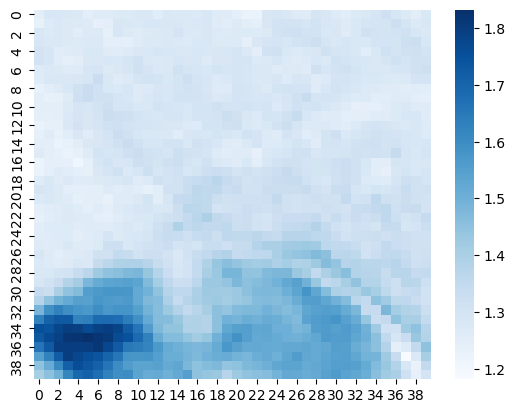

In [35]:
sns.heatmap(out_h2o[:, :, 0], cmap="Blues")
print(np.average(out_h2o)) #35min
print(f"{np.average(out_h2o[7:19, :27, 0]) :.4f}")

In [17]:
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache

# --- (他の関数定義は省略) ---
# read_bfile, read_tfile, apply_radiometric, get_rgb, show_img, get_radiance
# H2O関数群 (extract_h2o, estimated_by_water, wavelength_adjustment_h2o, func_h2o, residuals_h2o, estimate_param_h2o)
# 共通関数 (instrumental_function, reflectance_correction)
# LUT選択関数群 (list_available_h2o_values, idx_for_h2o, idx_for_h2o_sticky)

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
WATER_LUT_DIR = r"E:\refit\water_lut" # 必要に応じて変更

# --- LUT選択関数群 (変更なし) ---
# (省略)
# --- H2O_VALUES, H2O_FILES, MIDPOINTS の初期化 (変更なし) ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# CH4 (メタン) 推定関数群 (estimated_by_ch4 を修正)
# =========================================================
# --- (extract_ch4, wavelength_adjustment_ch4, func_ch4, residuals_ch4, estimate_param_ch4 は変更なし) ---
# (省略)

# 必要なグローバル変数を再定義 (元のコードから)
hi_i = 110
hi_f = 121
mo_i = 1895
mo_f = 2021

def estimated_by_ch4(data, c): # メタン濃度の量の推定 (修正版: 濃度レベルをヘッダーから取得)
    # data は (num_levels+1, num_wavelengths_ch4_range) の形状を想定
    # 0行目は波長、1行目以降が各濃度レベルのデータ
    # *** 修正: 濃度レベルを data 配列自体から取得するのではなく、
    # load_ch4_lut 関数で別途取得・保持しておく方が望ましいが、
    # ここでは data 配列の構造に依存する形で実装する（要LUT構造確認）
    # 仮定: data[1:, 0] に対応する濃度レベルが事前に分かっている (例: 0, 0.25, ...)
    # または、load_ch4_lut が濃度レベルも返すように修正する。
    # --- ここでは元のコードの仮定 (0.25刻み) を踏襲 ---
    num_levels = data.shape[0] - 1
    if num_levels <= 0:
        raise ValueError("estimated_by_ch4: LUT data has no concentration levels.")
    # ch4_levels = data_ch4_levels # load_ch4_lut から濃度レベルを受け取るのが理想
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 元の仮定を使用
    # --- 修正ここまで ---

    # クランプ処理
    if c <= ch4_levels[0]:
        position = 1
    elif c >= ch4_levels[-1]:
        position = len(ch4_levels)
    else:
        position = np.searchsorted(ch4_levels, c)

    # 補間処理 (前回の修正版と同じ)
    out = []
    idx_lower = position
    idx_upper = position + 1

    if idx_upper >= data.shape[0]: # data配列のインデックスは濃度レベル+1
        idx_upper = data.shape[0] - 1
        idx_lower = idx_upper
        interpolated_values = data[idx_upper, :]
        return interpolated_values.tolist()
    elif idx_lower <= 0: # data配列のインデックス1が濃度0に対応
        idx_lower = 1
        idx_upper = idx_lower
        interpolated_values = data[idx_lower, :]
        return interpolated_values.tolist()

    level_lower = ch4_levels[position-1]
    level_upper = ch4_levels[position]
    level_step = level_upper - level_lower

    if level_step <= 0:
       r = 0.0
    else:
       r = (level_upper - c) / level_step

    for i in range(data.shape[1]):
        interpolated_value = r * data[idx_lower, i] + (1 - r) * data[idx_upper, i]
        out.append(interpolated_value)
    return out

# =========================================================
# LUT 読み込み関数 (再々修正版)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), processes correctly, transposes, and scales."""
    try:
        # header=0 を指定してヘッダーを読み込む
        df = pd.read_csv(filepath, header=0)

        # 1列目 ('Waveln') を波長データとして取得 (float変換も行う)
        try:
            wavelengths = df['Waveln'].to_numpy(dtype=float)
        except KeyError:
            raise ValueError(f"LUT file {filepath} is missing 'Waveln' header.")
        except ValueError:
             raise ValueError(f"Could not convert 'Waveln' column in {filepath} to float.")

        # 2列目以降を各濃度レベルのデータとして取得 (float変換も行う)
        try:
            # iloc[:, 1:] で2列目以降を選択し、数値に変換
            ch4_data_levels = df.iloc[:, 1:].to_numpy(dtype=float)
        except ValueError:
            raise ValueError(f"Could not convert CH4 concentration data columns in {filepath} to float.")

        # 転置 -> (濃度レベル数, 波長数)
        ch4_data_levels_transposed = ch4_data_levels.T

        # 波長行と転置済みデータ行を結合 -> (濃度レベル数 + 1, 波長数)
        data_ch4 = np.vstack((wavelengths, ch4_data_levels_transposed))

        # *** スケーリングを適用 ***
        if data_ch4.shape[0] > 1:
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 形状チェック
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
             raise ValueError(f"Processed LUT {filepath} has unexpected shape {data_ch4.shape}.")
        # 波長チェック (正の値か)
        if not np.all(np.isfinite(data_ch4[0, :])) or np.any(data_ch4[0, :] <= 0):
            # warningではなくエラーを発生させる方が安全かもしれない
            raise ValueError(f"Wavelength row in {filepath} contains non-positive or non-finite values.")

        return data_ch4
    except pd.errors.EmptyDataError:
        raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError:
        raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        print(f"Error loading/processing LUT {filepath}: {e}")
        raise

# =========================================================
# Main Pixel-by-Pixel Estimation Function (変更なし)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    # --- (前回の修正版と同じコードなので省略) ---
    """ Estimates H2O and CH4 pixel by pixel. """
    if img_slice.ndim != 3:
        raise ValueError("img_slice must be a 3D array (H, W, C)")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0:
        print("Error: No CH4 LUTs found. Cannot perform CH4 estimation.")
        return out_h2o, out_ch4

    start_time = time.time()
    processed_pixels = 0
    error_pixels_h2o = 0
    error_pixels_lut = 0
    error_pixels_ch4 = 0

    for y in range(H):
        last_ch4_lut_idx = None
        # print(f"Processing row {y+1}/{H}...") # 必要ならコメント解除
        row_start_time = time.time()

        for x in range(W):
            try:
                # ---- Extract Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    processed_pixels += 1
                    continue

                # ---- H2O Estimation ----
                try:
                    b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                    a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                    res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                    h2o_est = float(res_h2o.x[4])
                    h2o_est = max(0, h2o_est)
                    out_h2o[y, x, 0] = h2o_est
                except Exception as e_h2o:
                    # print(f"Warn: H2O estimation failed at ({y},{x}): {e_h2o}") # 必要ならコメント解除
                    error_pixels_h2o += 1
                    continue # Skip CH4 if H2O fails

                # ---- Select and Load CH4 LUT ----
                try:
                    if sticky:
                        idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                    else:
                        idx = idx_for_h2o(h2o_est)
                    last_ch4_lut_idx = idx
                    selected_ch4_lut_file = H2O_FILES[idx]
                    data_ch4 = load_ch4_lut(selected_ch4_lut_file) # ここで再々修正版が呼ばれる
                    if data_ch4.ndim != 2 or data_ch4.shape[0] < 2:
                       raise ValueError("Invalid LUT shape")
                except Exception as e_lut:
                     # print(f"Warn: LUT selection/load failed at ({y},{x}), H2O={h2o_est:.2f}: {e_lut}") # 必要ならコメント解除
                     error_pixels_lut += 1
                     continue # Skip CH4 if LUT fails

                # ---- CH4 Estimation ----
                try:
                    try:
                        b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                    except Exception as e_param_ch4:
                        # print(f"Warn: estimate_param_ch4 failed at ({y},{x}): {e_param_ch4}. Using defaults.") # 必要ならコメント解除
                        a_ch4_init, b_ch4_init = 0.0, 0.0

                    a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                    res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                    out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                    out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                    ch4_ppm_est = float(res_ch4.x[4])
                    ch4_ppm_est = max(0, ch4_ppm_est)
                    out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                    residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                    out_ch4[y, x, 3] = float(np.sum(residual_values**2)) # Sum of squares
                except Exception as e_ch4:
                    # print(f"Warn: CH4 estimation failed at ({y},{x}), LUT={os.path.basename(selected_ch4_lut_file)}: {e_ch4}") # 必要ならコメント解除
                    error_pixels_ch4 += 1
                    # out_ch4 remains NaN

            except Exception as e_outer:
                 # print(f"Warn: Outer loop error at ({y},{x}): {e_outer}") # 必要ならコメント解除
                 pass
            finally:
                processed_pixels += 1

        # row_end_time = time.time()
        # print(f"Row {y+1} done ({row_end_time - row_start_time:.2f}s). Errors H2O:{error_pixels_h2o}, LUT:{error_pixels_lut}, CH4:{error_pixels_ch4}") # 必要ならコメント解除

    end_time = time.time()
    total_pixels = H * W
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels processed: {processed_pixels}/{total_pixels}")
    print(f"Errors during H2O estimation: {error_pixels_h2o}")
    print(f"Errors during LUT selection/load: {error_pixels_lut}")
    print(f"Errors during CH4 estimation: {error_pixels_ch4}")
    print(f"Total NaN in H2O results: {np.isnan(out_h2o).sum()}")
    print(f"Total NaN in CH4 results (first channel): {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total processing time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (H2O LUT パス修正)
# =========================================================
try:
    # *** H2O LUTのパスを確認・修正 ***
    # 以下のいずれか正しい方をコメント解除してください
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # もし 'waterprox' フォルダがある場合
    # h2o_lut_file = r"modtranwaterdata_full.csv" # もしスクリプトと同じフォルダにある場合

    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    # スケーリング適用
    if data_h2o_np.shape[0] > 1:
        data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT loaded from '{h2o_lut_file}' and prepared.")
    print(f"H2O LUT shape: {data_h2o_np.shape}")

    # --- img_slice と param が定義済みと仮定 ---
    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # 新しい load_ch4_lut 関数を使って再実行
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True,
            sticky_margin=0.02,
            ch4_init_ppm=1.8
        )

        # 結果表示
        print("\n--- Results ---")
        print("Estimated H2O (sample):\n", out_h2o[::2, ::2, 0])
        print("\nEstimated CH4 ppm (sample):\n", out_ch4[::2, ::2, 2])

        # 結果をCSVファイルに保存 (オプション)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d)
        df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        print("\nEstimated H2O saved to estimated_h2o.csv")

        ch4_sigma_2d = out_ch4[:, :, 0]
        ch4_mu_2d = out_ch4[:, :, 1]
        ch4_ppm_2d = out_ch4[:, :, 2]
        ch4_res_2d = out_ch4[:, :, 3]
        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d)
        df_ch4_mu = pd.DataFrame(ch4_mu_2d)
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_res = pd.DataFrame(ch4_res_2d)
        df_ch4_sigma.to_csv("estimated_ch4_sigma.csv", index=False, header=False, na_rep='NaN')
        df_ch4_mu.to_csv("estimated_ch4_mu.csv", index=False, header=False, na_rep='NaN')
        df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        df_ch4_res.to_csv("estimated_ch4_residual.csv", index=False, header=False, na_rep='NaN')
        print("Estimated CH4 parameters saved to separate CSV files.")

    else:
        print("Error: img_slice or param not defined.")

except FileNotFoundError as e:
    print(f"Error: Required file not found: {e}.")
except NameError as e:
     print(f"Error: A required variable is not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT loaded from 'E:\refit\waterprox\modtranwaterdata_full.csv' and prepared.
H2O LUT shape: (22, 2121)
img_slice shape: (10, 10, 185)
Error loading/processing LUT E:\refit\water_lut\1.3.csv: Wavelength row in E:\refit\water_lut\1.3.csv contains non-positive or non-finite values.
Error loading/processing LUT E:\refit\water_lut\1.3.csv: Wavelength row in E:\refit\water_lut\1.3.csv contains non-positive or non-finite values.
Error loading/processing LUT E:\refit\water_lut\1.3.csv: Wavelength row in E:\refit\water_lut\1.3.csv contains non-positive or non-finite values.
Error loading/processing LUT E:\refit\water_lut\1.3.csv: Wavelength row in E:\refit\water_lut\1.3.csv contains non-positive or non-finite values.
Error loading/processing LUT E:\refit\water_lut\1.3.csv: Wavelength row in E:\refit\water_lut\1.3.csv contains non-positive or non-finite values.
Error loading/processing LUT

In [9]:
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache

WATER_LUT_DIR = r"E:\refit\water_lut"

# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    for i in range(min(185, len(df))):
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            record_list = [line.rstrip().split("=") for line in csv_file if "=" in line]
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            try:
                params[key] = float(record[1])
            except ValueError:
                params[key] = record[1].strip() # Keep as string if not float

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    if not all(key in params for key in required_keys):
        missing = [key for key in required_keys if key not in params]
        raise ValueError(f"Missing required keys in metadata file {fileb}: {missing}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]


# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    if img.shape[2] < 185: # バンド数チェック
        raise ValueError(f"Input image has {img.shape[2]} bands, expected 185.")
    im = np.ones([img.shape[0], img.shape[1]])
    # no data area (use a band less likely to be zero, e.g., middle SWIR)
    # バンド10(index 9)が0かどうかでマスクを作成
    # HISUIのデータ仕様を確認し、適切なバンドインデックスを使用してください
    no_data_band_index = 10 # 例 (0-based index)
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds.")
        # Fallback: use first band maybe? Or handle differently.
        im[img[:,:,0] == 0] = 0 # Example fallback

    img_float = img.astype(float)
    # apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radianceaddvnir
    # apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radianceaddswir
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28): # デフォルトのバンド番号を元コードに合わせる
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError("RGB band indices are out of bounds for the image.")
    ims = np.zeros([img.shape[0], img.shape[1], 3])
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max_val = np.max(ims)
    # 非常に暗い画像やゼロのみの画像でゼロ除算を避ける
    # また、値が小さい場合に過度に明るくなるのを防ぐため、分母に微小値を追加することも検討
    if max_val > 1e-9: # 微小値より大きい場合のみ正規化
        ims /= max_val
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig) # メモリ解放のために図を閉じる

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    # param 配列の形状と内容を確認
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError("Invalid 'param' shape for get_radiance.")
    # SWIRバンド (58-184) に対応する波長と輝度を取得
    wave = param[58:185, 0] # 1列目 (index 0) が波長
    # 画像データの形状と座標を確認
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
         raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    rad = img[y, x, 58:185] # SWIRバンドの輝度値
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T # 形状: (バンド数, 2)

# メタン推定(2275~2400nm)
hi_i = 57 
hi_f = 69
mo_i = 1221
mo_f = 1372

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1]:
        raise ValueError(f"Invalid data shape or indices for extract_ch4. Shape={data.shape}, mo_f={mo_f}")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0:
        raise ValueError("estimated_by_ch4: LUT data has no concentration levels.")
    # *** 濃度レベルの仮定 (0.25刻み) *** 必要に応じて要修正
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25)

    # クランプ処理 & 補間 (修正済み)
    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    out = []
    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower <= 0: # Should be idx_lower <= 1 because index 0 is wavelength
        idx_lower = 1 # Index 1 corresponds to the first level (e.g., 0 ppm)
        idx_upper = idx_lower
        return data[idx_lower, :].tolist()

    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0

    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2:
        raise ValueError("Need at least two MODTRAN wavelengths for adjustment.")
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: raise ValueError("MODTRAN wavelength step non-positive.")
    data_ch4_arr = np.asarray(data_ch4_interpolated) # Ensure NumPy array
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths):
         raise ValueError("Shape mismatch between interpolated CH4 data and MODTRAN wavelengths.")

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

# func_ch4, residuals_ch4 (変更なし)
def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    # Make sure reflectance_correction receives wavelengths corresponding to the extracted range
    wavelengths_ch4_range = out_extracted[0, :] # Get wavelengths AFTER instrument func
    # Apply reflectance correction - NOTE: original reflectance_correction modified data in place
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    # Estimate at concentration c using corrected data
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    # Adjust wavelength using the CORRECT wavelengths for out_estimated (from out_extracted)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        # Ensure w_est is a numpy array of the same size
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
             # print(f"Shape mismatch in residuals_ch4: observed={observed_rad.shape}, estimated={w_est_np.shape}")
             # Attempt to reshape or return a large error value
             # This might happen if wavelength adjustment failed
             return np.full_like(observed_rad, 1e6) # Return large error
        return observed_rad - w_est_np
    except Exception as e:
        # print(f"Error in residuals_ch4 with params {param}: {e}") # Debugging
        # Return a large error value if calculation fails
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)


# estimate_param_ch4 (変更なし)
def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    if max_ref <= 0: # Handle cases with no signal
        # print("Warning: Max reference signal is zero or negative in estimate_param_ch4.")
        return 0.0, 0.0 # b, a

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :] # Use wavelengths after instrument func
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        if not out_adjusted: # Check if list is empty
             print("Warning: wavelength_adjustment_ch4 returned empty list in estimate_param_ch4.")
             return 0.0, 0.0

        if rel_max_index >= len(out_adjusted):
            # print(f"Warning: rel_max_index out of bounds in estimate_param_ch4. Using last element.")
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]

        if max_wave == 0 or modtran_val_at_max == 0:
            # print("Warning: Division by zero in estimate_param_ch4. Returning b=0.")
            return 0.0, 0.0 # b, a

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception as e:
        # print(f"Error during parameter estimation in estimate_param_ch4: {e}") # Debugging
        return 0.0, 0.0 # Return default values on error


# =========================================================
# H2O (水蒸気) 推定関数群 (変更なし)
# =========================================================
# (extract_h2o, estimated_by_water, wavelength_adjustment_h2o, func_h2o, residuals_h2o, estimate_param_h2o)
# (省略 - 前回のコードを使用)
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1]:
        raise ValueError(f"Invalid data shape or indices for extract_h2o. Shape={data.shape}, h2o_modtran_f={h2o_modtran_f}")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0:
        raise ValueError("estimated_by_water: LUT data has no concentration levels.")
    water_levels = np.arange(0, 0.25 * num_levels, 0.25)

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    out = []
    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower <= 1: # Index 1 is the first level
        idx_lower = 1
        idx_upper = idx_lower
        return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0

    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2:
        raise ValueError("Need at least two MODTRAN wavelengths for adjustment.")
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: raise ValueError("MODTRAN wavelength step non-positive.")
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths):
         raise ValueError("Shape mismatch between interpolated H2O data and MODTRAN wavelengths.")

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :] # Wavelengths AFTER instrument func
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        if w_est_np.shape != observed_rad.shape:
            # print(f"Shape mismatch in residuals_h2o: observed={observed_rad.shape}, estimated={w_est_np.shape}")
            return np.full_like(observed_rad, 1e6) # Return large error
        return observed_rad - w_est_np
    except Exception as e:
        # print(f"Error in residuals_h2o with params {param}: {e}") # Debugging
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :] # Wavelengths after instrument func
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
            raise IndexError("Highlight points indices out of bounds.")

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        if np.any(y_modtran == 0):
            # print("Warning: Division by zero in estimate_param_h2o polyfit. Returning a=0, b=0.")
            return 0.0, 0.0 # b, a

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception as e:
        # print(f"Error during parameter estimation in estimate_param_h2o: {e}") # Debugging
        return 0.0, 0.0 # Return default values on error

# =========================================================
# 共通関数 (変更なし)
# =========================================================
def instrumental_function(data, sigma, mu):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid data shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # Ensure sigma is positive and non-zero
    sigma = max(sigma, 1e-6) # Avoid division by zero or sqrt of negative
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    # Normalize gauss kernel? Should not be necessary if using correctly.
    # gauss /= np.sum(gauss) # Optional normalization

    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid data shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # Avoid potential negative reflectance factor if a, b are poorly estimated
        reflectance_factor = np.maximum(reflectance_factor, 0) # Clamp negative values to 0
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected


# =========================================================
# LUT 読み込み関数 (再々修正版)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        # header=0 を指定してヘッダーを読み込む
        df = pd.read_csv(filepath, header=0)

        # DataFrame全体を直接NumPy配列に変換 (成功例に近づける)
        try:
            # object型で読み込み、後で数値変換
            data_ch4_raw = df.to_numpy(dtype=object)
            # 最初の列 (波長) をfloatに変換
            wavelengths = data_ch4_raw[:, 0].astype(float)
            # データ部分 (2列目以降) をfloatに変換
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            # 再結合
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
             raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        # 転置 -> 形状が (列数=濃度レベル数+1, 行数=波長数) になる
        data_ch4 = data_ch4_raw.T

        # *** スケーリングを適用 ***
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
                 raise TypeError(f"Cannot apply scaling: Data type is not numeric ({data_ch4.dtype}) in {filepath} after transpose.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 形状チェック
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
             raise ValueError(f"Processed LUT {filepath} has unexpected shape {data_ch4.shape}.")

        # 波長チェック (NaNまたは負の値がないか)
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
             raise ValueError(f"Wavelength row in {filepath} contains NaN or negative values.")
        if np.any(wavelength_row == 0):
             print(f"Warning: Wavelength row in {filepath} contains zero values.")

        return data_ch4
    except pd.errors.EmptyDataError:
        raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError:
        raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        print(f"Error loading/processing LUT {filepath}: {e}")
        raise

# =========================================================
# Main Pixel-by-Pixel Estimation Function (変更なし)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    # --- (前回の修正版と同じコードなので省略) ---
    """ Estimates H2O and CH4 pixel by pixel. """
    if img_slice.ndim != 3:
        raise ValueError("img_slice must be a 3D array (H, W, C)")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0:
        print("Error: No CH4 LUTs found. Cannot perform CH4 estimation.")
        return out_h2o, out_ch4

    start_time = time.time()
    processed_pixels = 0
    error_pixels_h2o = 0
    error_pixels_lut = 0
    error_pixels_ch4 = 0

    for y in range(H):
        last_ch4_lut_idx = None
        # print(f"Processing row {y+1}/{H}...") # 必要ならコメント解除
        row_start_time = time.time()

        for x in range(W):
            try:
                # ---- Extract Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    processed_pixels += 1
                    continue

                # ---- H2O Estimation ----
                try:
                    b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                    a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                    res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                    h2o_est = float(res_h2o.x[4])
                    h2o_est = max(0, h2o_est)
                    out_h2o[y, x, 0] = h2o_est
                except Exception as e_h2o:
                    # print(f"Warn: H2O estimation failed at ({y},{x}): {e_h2o}") # 必要ならコメント解除
                    error_pixels_h2o += 1
                    continue # Skip CH4 if H2O fails

                # ---- Select and Load CH4 LUT ----
                try:
                    if sticky:
                        idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                    else:
                        idx = idx_for_h2o(h2o_est)
                    last_ch4_lut_idx = idx
                    selected_ch4_lut_file = H2O_FILES[idx]
                    data_ch4 = load_ch4_lut(selected_ch4_lut_file) # ここで再々々修正版が呼ばれる
                    if data_ch4.ndim != 2 or data_ch4.shape[0] < 2:
                       raise ValueError("Invalid LUT shape")
                except Exception as e_lut:
                     # print(f"Warn: LUT selection/load failed at ({y},{x}), H2O={h2o_est:.2f}: {e_lut}") # 必要ならコメント解除
                     error_pixels_lut += 1
                     continue # Skip CH4 if LUT fails

                # ---- CH4 Estimation ----
                try:
                    try:
                        b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                    except Exception as e_param_ch4:
                        # print(f"Warn: estimate_param_ch4 failed at ({y},{x}): {e_param_ch4}. Using defaults.") # 必要ならコメント解除
                        a_ch4_init, b_ch4_init = 0.0, 0.0

                    a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                    res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                    out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                    out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                    ch4_ppm_est = float(res_ch4.x[4])
                    ch4_ppm_est = max(0, ch4_ppm_est)
                    out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                    residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                    out_ch4[y, x, 3] = float(np.sum(residual_values**2)) # Sum of squares
                except Exception as e_ch4:
                    # print(f"Warn: CH4 estimation failed at ({y},{x}), LUT={os.path.basename(selected_ch4_lut_file)}: {e_ch4}") # 必要ならコメント解除
                    error_pixels_ch4 += 1
                    # out_ch4 remains NaN

            except Exception as e_outer:
                 # print(f"Warn: Outer loop error at ({y},{x}): {e_outer}") # 必要ならコメント解除
                 pass
            finally:
                processed_pixels += 1

        # row_end_time = time.time()
        # print(f"Row {y+1} done ({row_end_time - row_start_time:.2f}s). Errors H2O:{error_pixels_h2o}, LUT:{error_pixels_lut}, CH4:{error_pixels_ch4}") # 必要ならコメント解除

    end_time = time.time()
    total_pixels = H * W
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels processed: {processed_pixels}/{total_pixels}")
    print(f"Errors during H2O estimation: {error_pixels_h2o}")
    print(f"Errors during LUT selection/load: {error_pixels_lut}")
    print(f"Errors during CH4 estimation: {error_pixels_ch4}")
    print(f"Total NaN in H2O results: {np.isnan(out_h2o).sum()}")
    print(f"Total NaN in CH4 results (first channel): {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total processing time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (H2O LUT パス修正済み)
# =========================================================
try:
    # --- H2O LUTのパス設定 ---
    # 実行環境に合わせて、以下のいずれかのコメントアウトを解除・修正してください
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # フルパス指定の場合
    # h2o_lut_file = r"modtranwaterdata_full.csv" # スクリプトと同じディレクトリの場合

    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    # スケーリング適用
    if data_h2o_np.shape[0] > 1:
        data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT loaded from '{h2o_lut_file}' and prepared.")
    print(f"H2O LUT shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # この部分は元のipynbファイルなどから正しく読み込まれている必要があります
    # 例:
    # tif_file_path = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif"
    # img = tifffile.imread(tif_file_path)
    # param = read_bfile(tif_file_path)
    # radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(tif_file_path)
    # img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)
    # center = np.array([1000, 1000])
    # img_slice = img[center[0] - 5 : center[0] + 5, center[1] - 5 : center[1] + 5, :]
    # --- ここまで ---

    if 'img_slice' in locals() and isinstance(img_slice, np.ndarray) \
       and 'param' in locals() and isinstance(param, np.ndarray):
        print(f"img_slice shape: {img_slice.shape}")

        # 新しい load_ch4_lut 関数を使って再実行
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True,
            sticky_margin=0.02,
            ch4_init_ppm=1.8
        )

        # 結果表示
        print("\n--- Results ---")
        print("Estimated H2O (sample):\n", out_h2o[::2, ::2, 0])
        print("\nEstimated CH4 ppm (sample):\n", out_ch4[::2, ::2, 2])

        # 結果をCSVファイルに保存
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d)
        df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        print("\nEstimated H2O saved to estimated_h2o.csv")

        ch4_sigma_2d = out_ch4[:, :, 0]
        ch4_mu_2d = out_ch4[:, :, 1]
        ch4_ppm_2d = out_ch4[:, :, 2]
        ch4_res_2d = out_ch4[:, :, 3]
        df_ch4_sigma = pd.DataFrame(ch4_sigma_2d)
        df_ch4_mu = pd.DataFrame(ch4_mu_2d)
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d)
        df_ch4_res = pd.DataFrame(ch4_res_2d)
        df_ch4_sigma.to_csv("estimated_ch4_sigma.csv", index=False, header=False, na_rep='NaN')
        df_ch4_mu.to_csv("estimated_ch4_mu.csv", index=False, header=False, na_rep='NaN')
        df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        df_ch4_res.to_csv("estimated_ch4_residual.csv", index=False, header=False, na_rep='NaN')
        print("Estimated CH4 parameters saved to separate CSV files.")

    else:
        print("Error: img_slice or param not defined or not NumPy arrays.")
        if 'img_slice' not in locals(): print(" - img_slice is missing.")
        elif not isinstance(img_slice, np.ndarray): print(f" - img_slice is type {type(img_slice)}, expected NumPy array.")
        if 'param' not in locals(): print(" - param is missing.")
        elif not isinstance(param, np.ndarray): print(f" - param is type {type(param)}, expected NumPy array.")


except FileNotFoundError as e:
    print(f"Error: Required file not found: {e}.")
except NameError as e:
     print(f"Error: A required variable is not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

H2O LUT loaded from 'E:\refit\waterprox\modtranwaterdata_full.csv' and prepared.
H2O LUT shape: (22, 2121)
img_slice shape: (40, 40, 185)
Error: A required variable is not defined: name 'H2O_VALUES' is not defined


In [ ]:
#1600あたりでどんな感じか、今やってるあたりでどんな感じか、近い範囲を探して１６００あたりに変更して再度マップでフィッティング

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- out_ch4 配列が前のステップで計算されていることを前提とします ---

if 'out_ch4' in locals() and isinstance(out_ch4, np.ndarray) and out_ch4.ndim == 3:
    try:
        # out_ch4 配列からメタン濃度 (ppm) を抽出 (インデックス 2)
        ch4_ppm_map = out_ch4[:, :, 2]

        # NaN 値の処理 (オプション): NaN を特定の値 (例: 0 や平均値) で置き換えるか、
        # マッピング時に NaN を特定の色で表示するように cmap を設定できます。
        # ここでは NaN を 0 に置き換える例を示します。
        ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0で置換

        # マップ表示
        fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8)) # 図のサイズを調整 (任意)

        # imshow を使用してマップを表示
        # cmap='hot' や 'viridis', 'jet' など、見やすいカラーマップを選択
        im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation='nearest')

        # カラーバーを追加
        cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
        cbar.set_label('Estimated CH4 (ppm)')

        # タイトルと軸ラベル (軸ラベルは不要なら削除)
        ax_ch4.set_title('Estimated Methane Concentration Map')
        # ax_ch4.set_xlabel('X Pixel Coordinate') # 不要ならコメントアウト
        # ax_ch4.set_ylabel('Y Pixel Coordinate') # 不要ならコメントアウト
        ax_ch4.axis('off') # 軸を非表示にする場合

        # 画像ファイルとして保存
        plt.savefig('estimated_ch4_map.png', bbox_inches='tight')
        print("メタン濃度マップを 'estimated_ch4_map.png' として保存しました。")
        plt.close(fig_ch4) # メモリ解放のために図を閉じる

    except Exception as e:
        print(f"マップの生成中にエラーが発生しました: {e}")
        # traceback を表示して詳細を確認
        import traceback
        traceback.print_exc()

elif 'out_ch4' not in locals():
     print("エラー: 変数 'out_ch4' が存在しません。先にメタン濃度の推定を実行してください。")
else:
     print(f"エラー: 'out_ch4' の形式が不正です。期待される形状 (H, W, 4), 実際の形状: {getattr(out_ch4, 'shape', 'N/A')}")

メタン濃度マップを 'estimated_ch4_map.png' として保存しました。


In [43]:
#1600
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # «-- 変更: 進行度表示ライブラリtqdmをインポート

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
       ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
       ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)

# =========================================================
# CH4 (メタン) 推定関数群 (バグ対策省略版)
# =========================================================
hi_i = 57 
hi_f = 69
mo_i = 1221
mo_f = 1372

def extract_ch4(data):
    # 基本的な形状チェックのみ
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return [] # Return empty list if no levels
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    # idx_lower は最低でも1になるはず (position=1 の場合)
    elif idx_lower < 1: # 念のためチェック
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()


    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return [] # Return empty list if cannot interpolate
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    # エラー時は大きな値を返すように try-except を維持
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェックも維持
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    # ゼロ除算等の基本的なチェックは維持
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # try-except も維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        # リスト空チェック、インデックス範囲チェック、ゼロ除算チェックも維持
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0


# =========================================================
# H2O (水蒸気) 推定関数群 (バグ対策省略版)
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    # try-except 維持
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェック維持
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        # *** ここに return が抜けていました ***
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    # try-except 維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        # インデックス範囲チェック維持
        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
           # print("Warn: Highlight index out of bounds in estimate_param_h2o") # Debug
           return 0.0, 0.0 # b, a

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        # ゼロ除算チェック維持
        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数 (バグ対策省略版)
# =========================================================
def instrumental_function(data, sigma, mu):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # sigma の最小値チェック維持
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # 負の値クランプ維持
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# *** ここから不足していた関数 ***
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    # フォールバックとして空で初期化
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 基本的なチェックは維持
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        if np.any(wavelength_row == 0):
           pass # warning は省略

        return data_ch4
    # FileNotFoundError などの基本的なエラー処理は維持
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        # print(f"Error loading/processing LUT {filepath}: {e}") # Debugging
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (エラー処理省略版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel (simplified error handling). """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4 # LUT なし

    start_time = time.time()
    
    # «-- 変更: tqdmを使用して行(y)のループにプログレスバーを追加
    print(f"Starting pixel processing for {H}x{W} image...")
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        last_ch4_lut_idx = None
        for x in range(W):
            try: # ピクセル単位のエラー捕捉は維持
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ---- CH4 ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                ch4_ppm_est = float(res_ch4.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))

            except Exception as e_pix:
                # ピクセル処理中のエラーは NaN のままにする (エラーメッセージ省略)
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass
    # «-- 変更ここまで

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (主要部分のみ)
# =========================================================
try:
    # --- H2O LUT パス設定 & 読み込み ---
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # 要確認・修正
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # ここで img_slice と param が正しく定義されていること
    # (省略)
    
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # もし 'img_slice' と 'param' がまだロードされていない場合、
    # このスクリプトは 'Example Usage' セクションでエラーになります。
    # 実際の実行前に、これらの変数がロードされるようにしてください。
    
    # 以下は動作確認用のダミーです (10x10ピクセル)
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     print("Warning: 'param' not defined. Using dummy data.")
    #     param = np.zeros((185, 5))
    #     param[:, 0] = np.linspace(400, 2500, 185) # ダミーの波長
    # === ダミーデータの例ここまで ===


    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 ---
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        # サンプル表示を少し小さく (5x5ごと)
        sample_step = max(1, img_slice.shape[0] // 5) 
        print("H2O (sample):\n", out_h2o[::sample_step, ::sample_step, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        
        # (CSV保存コードは省略)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); df_ch4_ppm.to_csv("estimated_ch4_ppm1.csv", index=False, header=False, na_rep='NaN')
        # (他のCH4パラメータ保存も同様に可能)
        print("\nResults saved to CSV.")

        # --- マップ表示 (オプション) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            
            # 非常に小さい画像の場合、補間を 'nearest' にするとピクセルが見やすい
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig('estimated_ch4_map2.png', bbox_inches='tight')
            print("Map saved to 'estimated_ch4_map2.png'.")
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
img_slice shape: (80, 80, 185)
Starting pixel processing for 80x80 image...


Processing 80 rows: 100%|██████████| 80/80 [6:19:19<00:00, 284.50s/it]  



--- Processing Summary ---
Total pixels: 6400
NaN count H2O: 0
NaN count CH4: 0
Total time: 22759.76 seconds.

--- Results ---
H2O (sample):
 [[1.31910798 1.35451496 1.32604717 1.30824699 1.36468415]
 [1.14311274 1.32742845 1.40325087 1.29883031 1.26376057]
 [1.40423282 0.83524635 1.19418194 1.3526051  1.25975399]
 [1.33535107 1.40628217 0.48589189 1.21210809 1.27445049]
 [1.3100097  1.27698752 1.31429627 0.34088461 1.41099605]]

CH4 ppm (sample):
 [[0.         0.         0.         0.         0.        ]
 [0.39715596 0.         0.         0.         0.11653522]
 [0.         0.         0.80341456 0.09390667 0.        ]
 [0.         0.         1.81952207 0.93067931 0.        ]
 [0.         0.62840009 0.         0.80960373 0.        ]]

Results saved to CSV.
Map saved to 'estimated_ch4_map2.png'.


In [3]:

current_dir = os.getcwd()
print(f"=========================================================")
print(f"現在の作業フォルダ (ここに 'estimated_ch4_map.png' が保存されます):")
print(f"{current_dir}")
print(f"=========================================================")
    # --- ★ここまで追加 ---

現在の作業フォルダ (ここに 'estimated_ch4_map.png' が保存されます):
e:\refit


In [ ]:
#2200
# coding: utf-8
import os
import glob
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
from functools import lru_cache
import traceback # エラー詳細表示用
from tqdm import tqdm # «-- 変更: 進行度表示ライブラリtqdmをインポート

# =========================================================
# Configuration: Directory for CH4 LUTs
# =========================================================
# 注意: このパスは実行環境からアクセスできる必要があります。
# 実行環境に合わせて E:\... の部分を修正してください。
WATER_LUT_DIR = r"E:\refit\water_lut"

# =========================================================
# HISUI画像処理・読み込み関数群 (省略なし)
# =========================================================
# read radiometric file (csv)
def read_bfile(file):
    fileb = os.path.splitext(file)[0] + "_B.csv"
    try:
        df = pd.read_csv(fileb)
    except FileNotFoundError:
        raise FileNotFoundError(f"Radiometric file not found: {fileb}")
    param = np.zeros((185, 5), dtype=float)
    # Ensure not reading beyond available rows/columns
    num_rows_to_read = min(185, len(df))
    num_cols_in_csv = df.shape[1]
    for i in range(num_rows_to_read):
        for j in range(5):
            # Check if column index (j+1) exists in the CSV
            if j + 1 < num_cols_in_csv:
                param[i, j] = float(df.iloc[i, j + 1])
            else:
                param[i, j] = np.nan # Or 0.0, indicate missing data
                # print(f"Warning: Column {j+1} missing in {fileb} at row {i}")
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0] + ".txt"
    try:
        with open(fileb, "r") as csv_file:
            # Read all lines, split if '=' exists, ignore lines without '='
            record_list = [line.rstrip().split("=", 1) for line in csv_file if "=" in line] # Split only once
    except FileNotFoundError:
        raise FileNotFoundError(f"Metadata file not found: {fileb}")

    params = {}
    for record in record_list:
        if len(record) == 2:
            key = record[0].strip()
            value_str = record[1].strip()
            try:
                # Attempt to convert to float, otherwise keep as string
                params[key] = float(value_str)
            except ValueError:
                params[key] = value_str # Keep potentially important string values

    required_keys = ["RadianceMultiVNIR", "RadianceAddVNIR", "RadianceMultiSWIR", "RadianceAddSWIR"]
    # Check if all required keys exist and are convertible to float
    missing_or_invalid = []
    for key in required_keys:
        if key not in params:
            missing_or_invalid.append(f"{key} (missing)")
        elif not isinstance(params[key], (int, float)):
            missing_or_invalid.append(f"{key} (value '{params[key]}' is not a number)")

    if missing_or_invalid:
        raise ValueError(f"Missing or invalid required keys in metadata file {fileb}: {', '.join(missing_or_invalid)}")

    return params["RadianceMultiVNIR"], params["RadianceMultiSWIR"], params["RadianceAddVNIR"], params["RadianceAddSWIR"]

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    # Input validation
    if img.ndim != 3 or img.shape[2] < 185:
        raise ValueError(f"Input image must be 3D with at least 185 bands. Shape={img.shape}")
    if not all(isinstance(val, (int, float)) for val in [radmultivnir, radmultiswir, radaddvnir, radaddswir]):
       raise TypeError("Radiometric coefficients must be numeric.")

    im = np.ones(img.shape[:2], dtype=np.uint8) # Use uint8 for mask for efficiency
    no_data_band_index = 10
    if img.shape[2] > no_data_band_index:
        im[img[:,:,no_data_band_index] == 0] = 0
    else:
        # print(f"Warning: Band index {no_data_band_index} for no-data mask out of bounds. Using index 0.")
        im[img[:,:,0] == 0] = 0

    img_float = img.astype(float)
    # Apply radiometric vnir (bands 0-57)
    img_float[:,:,:58] = img_float[:,:,:58] * radmultivnir + radaddvnir
    # Apply radiometric swir (bands 58-184)
    img_float[:,:,58:185] = img_float[:,:,58:185] * radmultiswir + radaddswir
    # Apply mask after calculations
    img_float[im == 0] = 0
    return img_float

# RGB画像取得
def get_rgb(img, b=8, g=18, r=28):
    if not (0 <= b < img.shape[2] and 0 <= g < img.shape[2] and 0 <= r < img.shape[2]):
        raise IndexError(f"RGB band indices (b={b}, g={g}, r={r}) out of bounds for image with {img.shape[2]} bands.")
    ims = np.zeros([img.shape[0], img.shape[1], 3], dtype=float) # Ensure float type
    # Use .copy() to avoid potential views if img bands are needed elsewhere
    ims[:,:,0] = img[:,:,r].copy() # R
    ims[:,:,1] = img[:,:,g].copy() # G
    ims[:,:,2] = img[:,:,b].copy() # B

    # Normalize robustly: handle all-zero or constant-value images
    min_val, max_val = np.min(ims), np.max(ims)
    val_range = max_val - min_val
    if val_range > 1e-9: # Avoid division by zero or near-zero
        ims = (ims - min_val) / val_range
    elif max_val > 1e-9: # Handle constant non-zero image (normalize to 1.0)
       ims.fill(1.0)
    else: # Handle all-zero image (remains 0.0)
       ims.fill(0.0)

    # Clipping might be redundant after robust normalization but harmless
    ims = np.clip(ims, 0.0, 1.0)
    return ims

# 画像表示
def show_img(img):
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(img)
    plt.show()
    plt.close(fig)

# SWIRデータ抽出
def get_radiance(img, param, y, x):
    if param.shape[0] < 185 or param.shape[1] < 1:
        raise ValueError(f"Invalid 'param' shape {param.shape}, expected at least (185, 1).")
    if not (0 <= y < img.shape[0] and 0 <= x < img.shape[1]):
       raise IndexError(f"Pixel coordinates ({y},{x}) out of bounds for image shape {img.shape[:2]}")
    if img.shape[2] < 185:
       raise ValueError(f"Image has only {img.shape[2]} bands, expected at least 185 for SWIR extraction.")

    wave = param[58:185, 0]
    rad = img[y, x, 58:185]
    # Check if wave and rad have the same length
    if len(wave) != len(rad):
        raise ValueError(f"Wavelength ({len(wave)}) and Radiance ({len(rad)}) length mismatch for SWIR bands.")
    # Return directly as NumPy array, avoid intermediate list
    return np.column_stack((wave, rad)) # Shape: (num_swir_bands, 2)

# =========================================================
# CH4 (メタン) 推定関数群 (バグ対策省略版)
# =========================================================
hi_i = 110
hi_f = 121
mo_i = 1895
mo_f = 2021

def extract_ch4(data):
    # 基本的な形状チェックのみ
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def estimated_by_ch4(data, c):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return [] # Return empty list if no levels
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels)
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    # idx_lower は最低でも1になるはず (position=1 の場合)
    elif idx_lower < 1: # 念のためチェック
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()


    level_lower, level_upper = ch4_levels[position-1], ch4_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - c) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()


def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return [] # Return empty list if cannot interpolate
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    if data_ch4_arr.ndim != 1 or len(data_ch4_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_ch4_arr[position - 1] + (1 - r) * data_ch4_arr[position]
            out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    # エラー時は大きな値を返すように try-except を維持
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        observed_rad = data_hisui.iloc[hi_i:hi_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェックも維持
        if w_est_np.shape != observed_rad.shape:
           return np.full_like(observed_rad, 1e6)
        return observed_rad - w_est_np
    except Exception:
        num_residuals = hi_f - hi_i
        return np.full(num_residuals, 1e6)

def estimate_param_ch4(data, data_hisui):
    max_ref = np.max(data_hisui.iloc[hi_i:hi_f, 1])
    # ゼロ除算等の基本的なチェックは維持
    if max_ref <= 0: return 0.0, 0.0

    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f, 1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    # try-except も維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_ch4(out)
        out_estimated = estimated_by_ch4(out_extracted, c=1.8)
        modtran_wavelengths_ch4_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_ch4(out_estimated, modtran_wavelengths_ch4_range, data_hisui)

        # リスト空チェック、インデックス範囲チェック、ゼロ除算チェックも維持
        if not out_adjusted: return 0.0, 0.0
        if rel_max_index >= len(out_adjusted):
            modtran_val_at_max = out_adjusted[-1]
        else:
            modtran_val_at_max = out_adjusted[rel_max_index]
        if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0

        b = max_ref / max_wave / modtran_val_at_max
        a = 0.0
        return b, a
    except Exception:
        return 0.0, 0.0


# =========================================================
# H2O (水蒸気) 推定関数群 (バグ対策省略版)
# =========================================================
h2o_band_i = 11
h2o_band_f = 28
h2o_modtran_i = 645
h2o_modtran_f = 865

def extract_h2o(data):
    if data.ndim != 2 or h2o_modtran_f > data.shape[1] or h2o_modtran_i < 0:
        raise ValueError("Invalid shape or indices for extract_h2o")
    return data[:, h2o_modtran_i:h2o_modtran_f]

def estimated_by_water(data, w):
    num_levels = data.shape[0] - 1
    if num_levels <= 0: return []
    water_levels = np.arange(0, 0.25 * num_levels, 0.25) # 仮定

    if w <= water_levels[0]: position = 1
    elif w >= water_levels[-1]: position = len(water_levels)
    else: position = np.searchsorted(water_levels, w)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
        return data[idx_upper, :].tolist()
    elif idx_lower < 1:
       idx_lower = 1
       idx_upper = idx_lower
       return data[idx_lower, :].tolist()

    level_lower, level_upper = water_levels[position-1], water_levels[position]
    level_step = level_upper - level_lower
    r = (level_upper - w) / level_step if level_step > 0 else 0.0
    interpolated_values = r * data[idx_lower, :] + (1 - r) * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_h2o(data_water_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    wave_width = modtran_wavelengths[1] - modtran_wavelengths[0]
    if wave_width <= 0: return []
    data_water_arr = np.asarray(data_water_interpolated)
    if data_water_arr.ndim != 1 or len(data_water_arr) != len(modtran_wavelengths): return []

    out = []
    for i in range(h2o_band_i, h2o_band_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        if position == 0: out.append(data_water_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_water_arr[-1])
        else:
            r = (modtran_wavelengths[position] - hisui_wave) / wave_width
            interpolated_value = r * data_water_arr[position - 1] + (1 - r) * data_water_arr[position]
            out.append(interpolated_value)
    return out

def func_h2o(data, data_hisui, sigma, mu, a, b, w, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_h2o(out)
    wavelengths_h2o_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_water(out_reflectance_corrected, w)
    out_adjusted = wavelength_adjustment_h2o(out_estimated, wavelengths_h2o_range, data_hisui)
    return out_adjusted

def residuals_h2o(param, data, data_hisui):
    sigma, mu, a, b, w, k = param
    # try-except 維持
    try:
        w_est = func_h2o(data, data_hisui, sigma, mu, a, b, w, k)
        observed_rad = data_hisui.iloc[h2o_band_i:h2o_band_f, 1].values
        w_est_np = np.asarray(w_est)
        # 形状チェック維持
        if w_est_np.shape != observed_rad.shape:
            return np.full_like(observed_rad, 1e6)
        # *** ここに return が抜けていました ***
        return observed_rad - w_est_np
    except Exception:
        num_residuals = h2o_band_f - h2o_band_i
        return np.full(num_residuals, 1e6)


def estimate_param_h2o(data, data_hisui):
    # try-except 維持
    try:
        out = instrumental_function(data.copy(), sigma=6.5, mu=0.0)
        out_extracted = extract_h2o(out)
        out_estimated = estimated_by_water(out_extracted, w=2.0)
        modtran_wavelengths_h2o_range = out_extracted[0, :]
        out_adjusted = wavelength_adjustment_h2o(out_estimated, modtran_wavelengths_h2o_range, data_hisui)
        out_np = np.array(out_adjusted)

        highlight_points = [0, 1, 2, 15, 16]
        hisui_subset = data_hisui.iloc[h2o_band_i:h2o_band_f]

        # インデックス範囲チェック維持
        max_highlight_idx = max(highlight_points)
        if max_highlight_idx >= len(out_np) or max_highlight_idx >= len(hisui_subset):
           # print("Warn: Highlight index out of bounds in estimate_param_h2o") # Debug
           return 0.0, 0.0 # b, a

        x_waves = hisui_subset.iloc[highlight_points, 0].values
        y_observed = hisui_subset.iloc[highlight_points, 1].values
        y_modtran = out_np[highlight_points]

        # ゼロ除算チェック維持
        if np.any(y_modtran == 0): return 0.0, 0.0

        y = y_observed / y_modtran
        coefficients = np.polyfit(x_waves, y, 1)
        return coefficients[0], coefficients[1] # b, a
    except Exception:
        return 0.0, 0.0

# =========================================================
# 共通関数 (バグ対策省略版)
# =========================================================
def instrumental_function(data, sigma, mu):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for instrumental_function")
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    # sigma の最小値チェック維持
    sigma = max(sigma, 1e-6)
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    # 基本的な形状チェック
    if data.ndim != 2 or data.shape[0] < 2:
        raise ValueError("Invalid shape for reflectance_correction")
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # 負の値クランプ維持
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

# =========================================================
# *** ここから不足していた関数 ***
# LUT 選択・読み込みユーティリティ関数
# =========================================================
def list_available_h2o_values(dir_path: str):
    """Lists *.csv files in dir_path, interprets filenames as float H2O values."""
    if not os.path.isdir(dir_path):
        print(f"Warning: LUT directory not found: {dir_path}")
        return np.array([]), []
    paths = glob.glob(os.path.join(dir_path, "*.csv"))
    table = []
    for p in paths:
        name = os.path.splitext(os.path.basename(p))[0]
        name_std = name.replace(",", ".")
        try:
            h2o = float(name_std)
            table.append((h2o, p))
        except ValueError:
            continue
    if not table:
        print(f"Warning: No usable CSV LUTs found in {dir_path}.")
        return np.array([]), []
    table.sort(key=lambda t: t[0])
    h2o_values = np.array([t[0] for t in table], dtype=float)
    file_paths = [t[1] for t in table]
    return h2o_values, file_paths

def idx_for_h2o(h: float) -> int:
    """Finds the index of the H2O LUT value closest to h (with clamping)."""
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for selection.")
    if len(H2O_VALUES) == 1: return 0

    insert_idx = np.searchsorted(H2O_VALUES, h)
    if insert_idx == 0: return 0
    if insert_idx == len(H2O_VALUES): return len(H2O_VALUES) - 1

    dist_left = h - H2O_VALUES[insert_idx - 1]
    dist_right = H2O_VALUES[insert_idx] - h
    return insert_idx - 1 if dist_left < dist_right else insert_idx


def idx_for_h2o_sticky(h: float, last_idx: int, margin: float = 0.02) -> int:
    """ "Sticky" selection: Prefers last_idx slightly. """
    if len(H2O_VALUES) == 0:
      raise ValueError("No H2O LUT values available for sticky selection.")
    if len(H2O_VALUES) == 1: return 0
    if last_idx is None: return idx_for_h2o(h)

    lower_mid = -np.inf if last_idx == 0 else (H2O_VALUES[last_idx-1] + H2O_VALUES[last_idx]) / 2.0
    upper_mid = np.inf if last_idx == len(H2O_VALUES) - 1 else (H2O_VALUES[last_idx] + H2O_VALUES[last_idx+1]) / 2.0
    lower_bound = lower_mid - margin
    upper_bound = upper_mid + margin
    if lower_bound <= h < upper_bound: return last_idx

    return idx_for_h2o(h)

# --- グローバル変数の初期化 ---
try:
    H2O_VALUES, H2O_FILES = list_available_h2o_values(WATER_LUT_DIR)
    if len(H2O_VALUES) > 1:
        MIDPOINTS = (H2O_VALUES[:-1] + H2O_VALUES[1:]) / 2.0
    else:
        MIDPOINTS = np.array([])
    print(f"Found {len(H2O_VALUES)} CH4 LUTs for H2O values: {H2O_VALUES}")
except Exception as e:
    print(f"Error initializing CH4 LUT list: {e}")
    # フォールバックとして空で初期化
    H2O_VALUES, H2O_FILES, MIDPOINTS = np.array([]), [], np.array([])

# =========================================================
# LUT 読み込み関数 (CH4用 - 変更なし)
# =========================================================
@lru_cache(maxsize=64)
def load_ch4_lut(filepath: str):
    """Loads a CH4 LUT CSV (with header), converts to NumPy, transposes, and scales (Revised)."""
    try:
        df = pd.read_csv(filepath, header=0)
        try:
            data_ch4_raw = df.to_numpy(dtype=object)
            wavelengths = data_ch4_raw[:, 0].astype(float)
            ch4_data = data_ch4_raw[:, 1:].astype(float)
            data_ch4_raw = np.hstack((wavelengths[:, np.newaxis], ch4_data))
        except ValueError as ve:
           raise ValueError(f"Error converting data in {filepath} to float. Check CSV format. Error: {ve}")
        except Exception as e_conv:
            raise ValueError(f"Error converting DataFrame to NumPy array for {filepath}: {e_conv}")

        data_ch4 = data_ch4_raw.T
        if data_ch4.shape[0] > 1:
            if not np.issubdtype(data_ch4.dtype, np.number):
               raise TypeError(f"Cannot apply scaling: Data type non numeric ({data_ch4.dtype}) in {filepath}.")
            data_ch4[1:, :] = data_ch4[1:, :] * 100

        # 基本的なチェックは維持
        if data_ch4.ndim != 2 or data_ch4.shape[0] < 2 or data_ch4.shape[1] == 0:
           raise ValueError(f"Processed LUT {filepath} unexpected shape {data_ch4.shape}.")
        wavelength_row = data_ch4[0, :]
        if np.any(np.isnan(wavelength_row)) or np.any(wavelength_row < 0):
           raise ValueError(f"Wavelength row in {filepath} contains NaN or negative.")
        if np.any(wavelength_row == 0):
           pass # warning は省略

        return data_ch4
    # FileNotFoundError などの基本的なエラー処理は維持
    except pd.errors.EmptyDataError: raise ValueError(f"LUT file {filepath} is empty.")
    except FileNotFoundError: raise FileNotFoundError(f"LUT file {filepath} not found.")
    except Exception as e:
        # print(f"Error loading/processing LUT {filepath}: {e}") # Debugging
        raise # エラーは再発生させる

# =========================================================
# Main Pixel-by-Pixel Estimation Function (エラー処理省略版)
# =========================================================
def estimate_h2o_and_ch4_per_pixel(
    img_slice: np.ndarray,
    param,
    data_h2o, # H2O LUT (transposed, scaled numpy array)
    sticky: bool = True,
    sticky_margin: float = 0.02,
    ch4_init_ppm: float = 1.8,
):
    """ Estimates H2O and CH4 pixel by pixel (simplified error handling). """
    if img_slice.ndim != 3: raise ValueError("img_slice must be 3D")
    H, W, C = img_slice.shape
    out_h2o = np.full((H, W, 1), np.nan, dtype=float)
    out_ch4 = np.full((H, W, 4), np.nan, dtype=float)

    if len(H2O_VALUES) == 0: return out_h2o, out_ch4 # LUT なし

    start_time = time.time()
    
    # «-- 変更: tqdmを使用して行(y)のループにプログレスバーを追加
    print(f"Starting pixel processing for {H}x{W} image...")
    for y in tqdm(range(H), desc=f"Processing {H} rows"):
        last_ch4_lut_idx = None
        for x in range(W):
            try: # ピクセル単位のエラー捕捉は維持
                # ---- Radiance ----
                data_rad = get_radiance(img_slice, param, y, x)
                df_hisui = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])
                if np.max(df_hisui["Radiance"]) <= 0:
                    out_h2o[y, x, 0] = 0.0
                    out_ch4[y, x, :] = 0.0
                    continue

                # ---- H2O ----
                b_h2o, a_h2o = estimate_param_h2o(data_h2o, df_hisui)
                a0_h2o = np.array([6.5, 0.0, a_h2o, b_h2o, 2.0, 0.0])
                res_h2o = least_squares(residuals_h2o, a0_h2o, args=(data_h2o, df_hisui), method="lm")
                h2o_est = float(res_h2o.x[4])
                h2o_est = max(0, h2o_est)
                out_h2o[y, x, 0] = h2o_est

                # ---- Select/Load CH4 LUT ----
                if sticky: idx = idx_for_h2o_sticky(h2o_est, last_ch4_lut_idx, margin=sticky_margin)
                else: idx = idx_for_h2o(h2o_est)
                last_ch4_lut_idx = idx
                selected_ch4_lut_file = H2O_FILES[idx]
                data_ch4 = load_ch4_lut(selected_ch4_lut_file)

                # ---- CH4 ----
                b_ch4_init, a_ch4_init = estimate_param_ch4(data_ch4, df_hisui)
                a0_ch4 = np.array([6.0, 0.0, a_ch4_init, b_ch4_init, ch4_init_ppm, 0.0])
                res_ch4 = least_squares(residuals_ch4, a0_ch4, args=(data_ch4, df_hisui), method="lm")

                out_ch4[y, x, 0] = float(res_ch4.x[0])  # sigma
                out_ch4[y, x, 1] = float(res_ch4.x[1])  # mu
                ch4_ppm_est = float(res_ch4.x[4])
                ch4_ppm_est = max(0, ch4_ppm_est)
                out_ch4[y, x, 2] = ch4_ppm_est # ch4 (ppm)
                residual_values = residuals_ch4(res_ch4.x, data_ch4, df_hisui)
                out_ch4[y, x, 3] = float(np.sum(residual_values**2))

            except Exception as e_pix:
                # ピクセル処理中のエラーは NaN のままにする (エラーメッセージ省略)
                # print(f"Error at pixel ({y},{x}): {e_pix}") # Debugging
                pass
    # «-- 変更ここまで

    end_time = time.time()
    print(f"\n--- Processing Summary ---")
    print(f"Total pixels: {H*W}")
    print(f"NaN count H2O: {np.isnan(out_h2o).sum()}")
    print(f"NaN count CH4: {np.isnan(out_ch4[:,:,0]).sum()}")
    print(f"Total time: {end_time - start_time:.2f} seconds.")
    return out_h2o, out_ch4

# =========================================================
# Example Usage (主要部分のみ)
# =========================================================
try:
    # --- H2O LUT パス設定 & 読み込み ---
    h2o_lut_file = r"E:\refit\waterprox\modtranwaterdata_full.csv" # 要確認・修正
    data_h2o_df = pd.read_csv(h2o_lut_file)
    data_h2o_np = data_h2o_df.to_numpy().T
    if data_h2o_np.shape[0] > 1: data_h2o_np[1:, :] = data_h2o_np[1:, :] * 100
    print(f"H2O LUT '{h2o_lut_file}' loaded. Shape: {data_h2o_np.shape}")

    # --- HISUI画像データ (img_slice) とパラメータ (param) の準備 ---
    # ここで img_slice と param が正しく定義されていること
    # (省略)
    
    # === ダミーデータの例 (この部分は実際のものに置き換えてください) ===
    # もし 'img_slice' と 'param' がまだロードされていない場合、
    # このスクリプトは 'Example Usage' セクションでエラーになります。
    # 実際の実行前に、これらの変数がロードされるようにしてください。
    
    # 以下は動作確認用のダミーです (10x10ピクセル)
    # if 'img_slice' not in locals():
    #     print("Warning: 'img_slice' not defined. Using 10x10 dummy data.")
    #     img_slice = np.random.randint(1000, 2000, size=(10, 10, 185)).astype(float)
    #     img_slice[:, :, 10] = 1500 # ゼロでないデータ
    # if 'param' not in locals():
    #     print("Warning: 'param' not defined. Using dummy data.")
    #     param = np.zeros((185, 5))
    #     param[:, 0] = np.linspace(400, 2500, 185) # ダミーの波長
    # === ダミーデータの例ここまで ===


    if 'img_slice' in locals() and 'param' in locals():
        print(f"img_slice shape: {img_slice.shape}")

        # --- 推定実行 ---
        out_h2o, out_ch4 = estimate_h2o_and_ch4_per_pixel(
            img_slice, param, data_h2o_np,
            sticky=True, sticky_margin=0.02, ch4_init_ppm=1.8
        )

        # --- 結果表示 & 保存 ---
        print("\n--- Results ---")
        # サンプル表示を少し小さく (5x5ごと)
        sample_step = max(1, img_slice.shape[0] // 5) 
        print("H2O (sample):\n", out_h2o[::sample_step, ::sample_step, 0])
        print("\nCH4 ppm (sample):\n", out_ch4[::sample_step, ::sample_step, 2])
        
        # (CSV保存コードは省略)
        h, w, _ = out_h2o.shape
        h2o_2d = out_h2o.reshape(h, w)
        df_h2o = pd.DataFrame(h2o_2d); df_h2o.to_csv("estimated_h2o.csv", index=False, header=False, na_rep='NaN')
        ch4_ppm_2d = out_ch4[:, :, 2]
        df_ch4_ppm = pd.DataFrame(ch4_ppm_2d); df_ch4_ppm.to_csv("estimated_ch4_ppm.csv", index=False, header=False, na_rep='NaN')
        # (他のCH4パラメータ保存も同様に可能)
        print("\nResults saved to CSV.")

        # --- マップ表示 (オプション) ---
        try:
            ch4_ppm_map = out_ch4[:, :, 2]
            ch4_ppm_map_filled = np.nan_to_num(ch4_ppm_map, nan=0.0) # NaNを0に
            
            # 非常に小さい画像の場合、補間を 'nearest' にするとピクセルが見やすい
            interp = 'nearest' if max(ch4_ppm_map_filled.shape) < 100 else 'bilinear'
            
            fig_ch4, ax_ch4 = plt.subplots(figsize=(8, 8))
            im_ch4 = ax_ch4.imshow(ch4_ppm_map_filled, cmap='hot', interpolation=interp)
            cbar = fig_ch4.colorbar(im_ch4, ax=ax_ch4, fraction=0.046, pad=0.04)
            cbar.set_label('Estimated CH4 (ppm)')
            ax_ch4.set_title('Estimated Methane Concentration Map')
            ax_ch4.axis('off')
            plt.savefig('estimated_ch4_map.png', bbox_inches='tight')
            print("Map saved to 'estimated_ch4_map.png'.")
            plt.close(fig_ch4)
        except Exception as e_map:
            print(f"Failed to generate map: {e_map}")

    else:
        print("Error: img_slice or param not defined. (Example Usage section skipped)")

# --- エラー処理 ---
except FileNotFoundError as e: print(f"Error: File not found: {e}.")
except NameError as e: print(f"Error: Variable not defined: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Found 17 CH4 LUTs for H2O values: [1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7]
H2O LUT 'E:\refit\waterprox\modtranwaterdata_full.csv' loaded. Shape: (22, 2121)
img_slice shape: (80, 80, 185)
Starting pixel processing for 80x80 image...


Processing 80 rows: 100%|██████████| 80/80 [6:40:40<00:00, 300.51s/it]  



--- Processing Summary ---
Total pixels: 6400
NaN count H2O: 0
NaN count CH4: 0
Total time: 24040.53 seconds.

--- Results ---
H2O (sample):
 [[1.31910798 1.35451496 1.32604717 1.30824699 1.36468415]
 [1.14311274 1.32742845 1.40325087 1.29883031 1.26376057]
 [1.40423282 0.83524635 1.19418194 1.3526051  1.25975399]
 [1.33535107 1.40628217 0.48589189 1.21210809 1.27445049]
 [1.3100097  1.27698752 1.31429627 0.34088461 1.41099605]]

CH4 ppm (sample):
 [[2.24999734 2.15034162 1.92851213 2.20867026 2.69515062]
 [2.06356216 2.40180848 2.71676817 2.36239231 2.18750191]
 [2.07173397 2.40839098 2.14794162 3.04185563 2.31456327]
 [2.62528455 1.98456006 2.47163474 2.64417898 2.18033072]
 [2.05096903 2.43531469 1.86634221 2.09860931 2.22825397]]

Results saved to CSV.
Map saved to 'estimated_ch4_map.png'.


In [4]:
def save_all_spectra_to_csv(img_slice, param, output_filename="all_ir_spectra.csv"):
    """
    img_slice内の全ピクセルのスペクトルデータをCSVに保存します。
    (Jupyterセルから呼び出されることを想定)
    """
    try:
        # 1. 入力データの形状を取得
        if img_slice.ndim != 3:
            raise ValueError(f"img_slice must be 3D (H, W, C), but got shape {img_slice.shape}")
        H, W, C = img_slice.shape
        
        if param.shape[0] < C:
            raise ValueError(f"param array has {param.shape[0]} rows, but img_slice has {C} bands.")
            
        print(f"Exporting all spectra for {H}x{W} image ({C} bands)...")

        # 2. ヘッダーの作成
        # paramから波長情報を取得 (先頭Cバンド分)
        wavelengths = param[:C, 0]
        # ヘッダーリスト: ['y', 'x', 'wave_400.00nm', 'wave_410.50nm', ...]
        headers = ['y', 'x'] + [f'wave_{w:.2f}nm' for w in wavelengths]

        # 3. 座標データの作成 (H*W, 2)
        y_coords, x_coords = np.mgrid[0:H, 0:W]
        coordinates = np.stack((y_coords, x_coords), axis=-1).reshape(-1, 2)
        
        # 4. ピクセルデータのリシェイプ (H*W, C)
        pixel_data = img_slice.reshape(-1, C)

        # 5. 座標とピクセルデータを結合 (H*W, C+2)
        print("Combining coordinate and pixel data...")
        combined_data = np.hstack((coordinates.astype(int), pixel_data)) # 座標を整数型に

        # 6. Pandas DataFrame の作成
        print("Creating DataFrame (this may take time for large images)...")
        df_spectra = pd.DataFrame(combined_data, columns=headers)
        
        # 7. 型の調整 (メモリ節約)
        df_spectra['y'] = df_spectra['y'].astype(np.uint32)
        df_spectra['x'] = df_spectra['x'].astype(np.uint32)
        for col in headers[2:]:
             df_spectra[col] = df_spectra[col].astype(np.float32)

        # 8. CSV への保存
        print(f"Saving to {output_filename}...")
        start_save = time.time()
        # 浮動小数点数のフォーマットを指定して保存
        df_spectra.to_csv(output_filename, index=False, float_format='%.6g')
        end_save = time.time()
        print(f"Successfully saved all spectra to {output_filename}. (Took {end_save - start_save:.2f}s)")

    except Exception as e:
        print(f"Error in save_all_spectra_to_csv: {e}")
        traceback.print_exc()

# --- 関数の実行 ---
try:
    # 警告: 画像サイズが大きいと巨大なCSVが作成され、時間がかかります。
    print("[Diagnostic Run] Starting spectrum export...")
    
    # img_slice (画像) と param (波長) を使って関数を呼び出す
    save_all_spectra_to_csv(img_slice, param, "all_ir_spectra.csv")
    
    print("[Diagnostic Run] Finished.")

except NameError:
    print("Error: 'img_slice' or 'param' is not defined.")
    print("Please ensure img_slice and param are loaded in a previous cell.")
except Exception as e:
    print(f"An error occurred: {e}")
    traceback.print_exc()

[Diagnostic Run] Starting spectrum export...
Exporting all spectra for 80x80 image (185 bands)...
Combining coordinate and pixel data...
Creating DataFrame (this may take time for large images)...
Saving to all_ir_spectra.csv...
Successfully saved all spectra to all_ir_spectra.csv. (Took 4.09s)
[Diagnostic Run] Finished.


In [15]:
import pandas as pd
import numpy as np
import traceback

# --- 1. ユーザー定義（元のスライスと一致させる） ---
FILE_PATH = "estimated_ch4_ppm.csv"
CENTER_Y = 100 # 元のコード: center = np.array([100, 600])
CENTER_X = 600
SLICE_RADIUS = 20 # 元のコード: -20 : +20

# 「大きい」と判断するパーセンタイル値
HIGH_PERCENTILE = 95 

try:
    # --- 2. CSVファイルの読み込み ---
    print(f"Loading methane map from: {FILE_PATH}")
    # ヘッダーがないCSVとして読み込む
    df = pd.read_csv(FILE_PATH, header=None)
    ch4_map = df.to_numpy()
    
    map_height, map_width = ch4_map.shape
    print(f"Loaded map shape: ({map_height}, {map_width})")

    # 期待される形状と一致するか確認
    expected_shape = (SLICE_RADIUS * 2, SLICE_RADIUS * 2)
    if ch4_map.shape != expected_shape:
        print(f"Warning: Map shape {ch4_map.shape} does not match expected {expected_shape}.")
        print("Coordinates might be incorrect if slice parameters changed.")

    # --- 3. NaN値の確認 ---
    if np.isnan(ch4_map).all():
        print("Error: The methane map contains only NaN values. Cannot analyze.")
    
    else:
        # --- 4. グローバル座標のオフセットを計算 ---
        # スライスの左上のピクセルが、元の（グローバルな）画像でどの座標にあたるか
        y_offset = CENTER_Y - SLICE_RADIUS
        x_offset = CENTER_X - SLICE_RADIUS
        print(f"Slice's top-left corner (global coords): ({y_offset}, {x_offset})")

        # --- 5. 最大値のピクセルを特定 ---
        print("\n--- 1. Maximum Value Pixel ---")
        # nanmax / nanargmax でNaNを無視して最大値とそのインデックス（ローカル）を取得
        max_val = np.nanmax(ch4_map)
        max_loc_local = np.unravel_index(np.nanargmax(ch4_map), ch4_map.shape)
        y_loc_max, x_loc_max = max_loc_local
        
        # グローバル座標に変換
        y_glob_max = y_loc_max + y_offset
        x_glob_max = x_loc_max + x_offset
        
        print(f"Max Value: {max_val:.4f}")
        print(f"  Local Coords (y, x): ({y_loc_max}, {x_loc_max})")
        print(f"  Global Coords (y, x): ({y_glob_max}, {x_glob_max})")

        # --- 6. 閾値（95パーセンタイル）を超えるピクセルを特定 ---
        print(f"\n--- 2. Pixels > {HIGH_PERCENTILE}th Percentile ---")
        # NaNを無視してパーセンタイル値を計算
        threshold = np.nanpercentile(ch4_map, HIGH_PERCENTILE)
        print(f"Threshold value (top {100-HIGH_PERCENTILE}%): {threshold:.4f}")

        # 閾値を超え、かつNaNでないピクセルのローカル座標を取得
        local_y_indices, local_x_indices = np.where((ch4_map > threshold) & (~np.isnan(ch4_map)))

        if local_y_indices.size == 0:
            print("No other pixels found above the threshold.")
        elif local_y_indices.size == 1 and local_y_indices[0] == y_loc_max and local_x_indices[0] == x_loc_max:
             print("Only the maximum value pixel is above the threshold.")
        elif local_y_indices.size > 50:
             print(f"Found {local_y_indices.size} pixels. Showing first 50.")
             local_y_indices = local_y_indices[:50]
             local_x_indices = local_x_indices[:50]
        else:
            print(f"Found {local_y_indices.size} pixels above threshold:")

        if local_y_indices.size > 0:
            print("Global (y, x) | Local (y, x) | CH4 Value")
            print("-" * 40)
            
            for y_loc, x_loc in zip(local_y_indices, local_x_indices):
                # 最大値のピクセルは再表示しない
                if y_loc == y_loc_max and x_loc == x_loc_max:
                    continue
                
                y_global = y_loc + y_offset
                x_global = x_loc + x_offset
                value = ch4_map[y_loc, x_loc]
                
                # 整形して表示
                print(f"({y_global:4}, {x_global:4}) | ({y_loc:2}, {x_loc:2}) | {value:.4f}")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("Please make sure 'estimated_ch4_ppm.csv' is in the same directory as your notebook.")
except Exception as e:
    print(f"An error occurred: {e}")
    traceback.print_exc()

Loading methane map from: estimated_ch4_ppm.csv
Loaded map shape: (40, 40)
Slice's top-left corner (global coords): (80, 580)

--- 1. Maximum Value Pixel ---
Max Value: 29.8604
  Local Coords (y, x): (29, 5)
  Global Coords (y, x): (109, 585)

--- 2. Pixels > 95th Percentile ---
Threshold value (top 5%): 1.0614
Found 80 pixels. Showing first 50.
Global (y, x) | Local (y, x) | CH4 Value
----------------------------------------
(  87,  610) | ( 7, 30) | 1.2704
(  98,  618) | (18, 38) | 1.1014
( 102,  619) | (22, 39) | 1.3175
( 103,  580) | (23,  0) | 9.4624
( 103,  619) | (23, 39) | 1.3579
( 104,  580) | (24,  0) | 26.9112
( 104,  581) | (24,  1) | 9.3631
( 105,  580) | (25,  0) | 11.1178
( 105,  581) | (25,  1) | 27.3116
( 105,  582) | (25,  2) | 10.6019
( 105,  616) | (25, 36) | 1.2369
( 105,  617) | (25, 37) | 1.0694
( 105,  618) | (25, 38) | 1.6398
( 106,  581) | (26,  1) | 11.1249
( 106,  582) | (26,  2) | 27.5983
( 106,  583) | (26,  3) | 10.4552
( 106,  619) | (26, 39) | 1.0893
( 

--- Starting analysis for y = 28 ---
Loading spectral data from: all_pixel_spectra1.csv
Filtering for y = 28...
Found 80 pixels for y = 28.
Extracted and sorted 185 wavelength bands.
Generating plot... (Saving to spectra_y_28_plot.png)
Plot successfully saved to: spectra_y_28_plot.png

--- Anomaly Detection (Spike) ---
Detecting spikes for 'wave_1675.39nm'
  Left neighbor:   wave_1662.90nm (1662.9nm)
  Right neighbor:  wave_1687.88nm (1687.88nm)

Result: No pixels found at y=28 where 'wave_1675.39nm' is a local maximum.

--- Analysis for y = 28 finished. ---


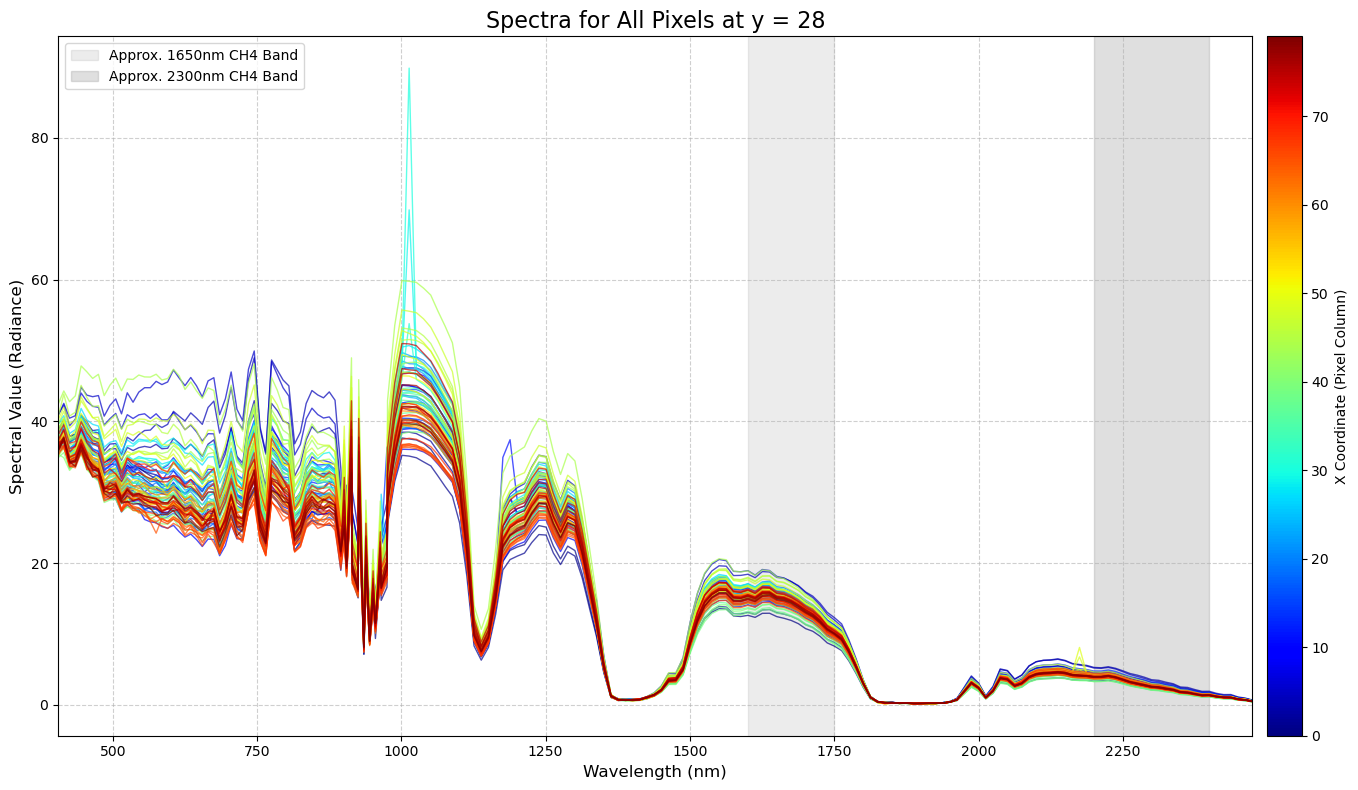

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import re

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# CSVファイルのパス
FILE_PATH = "all_pixel_spectra1.csv"

# ★ 解析したい y 座標を指定してください ★
TARGET_Y = 28 

# 異常検出（スパイク）のターゲット波長（文字列）
TARGET_WAVELENGTH_STR = "1675.39"
# =========================================================

# --- 処理開始 ---
print(f"--- Starting analysis for y = {TARGET_Y} ---")

# ターゲット波長に対応する列名
TARGET_COLUMN_NAME = f"wave_{TARGET_WAVELENGTH_STR}nm"
# 出力するグラフのファイル名（y座標の値を含むように）
OUTPUT_PLOT = f"spectra_y_{TARGET_Y}_plot.png"

try:
    print(f"Loading spectral data from: {FILE_PATH}")
    # CSVを読み込む
    df_all_spectra = pd.read_csv(FILE_PATH)

    # --- 1. y座標でデータをフィルタリング ---
    print(f"Filtering for y = {TARGET_Y}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y].copy()
    
    if df_y_target.empty:
        print(f"Error: No data found for y = {TARGET_Y}. Stopping analysis.")
    
    else:
        print(f"Found {len(df_y_target)} pixels for y = {TARGET_Y}.")
        
        # --- 2. 波長データ（列名と数値）の準備 ---
        wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
        
        # (波長の数値, 列名) のタプルのリストを作成
        wavelength_tuples = []
        for col in wavelength_cols:
            try:
                # 正規表現で数値を抽出
                wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
                wavelength_tuples.append((wave_float, col))
            except Exception:
                print(f"Warning: Could not parse wavelength from '{col}'")
        
        # 波長の数値でソート
        wavelength_tuples.sort(key=lambda x: x[0])
        
        # ソート済みの波長（数値）と列名リストを再作成
        wavelengths_sorted_num = [wave for wave, col in wavelength_tuples]
        wavelengths_sorted_cols = [col for wave, col in wavelength_tuples]
        
        print(f"Extracted and sorted {len(wavelengths_sorted_num)} wavelength bands.")

        # --- 3. グラフの描画 (ソート順を使用) ---
        print(f"Generating plot... (Saving to {OUTPUT_PLOT})")
        fig, ax = plt.subplots(figsize=(15, 8))
        
        min_x = df_y_target['x'].min()
        max_x = df_y_target['x'].max()
        norm = plt.Normalize(vmin=min_x, vmax=max_x)
        cmap = plt.cm.jet
        
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            # ソート済みの列リストを使って値を取得
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            
            # ソート済みの波長（数値）をX軸に使用
            ax.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7, linewidth=1)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('X Coordinate (Pixel Column)')

        ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y}', fontsize=16)
        ax.set_xlabel('Wavelength (nm)', fontsize=12)
        ax.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # メタン吸収帯のハイライト
        ax.axvspan(1600, 1750, color='gray', alpha=0.15, label='Approx. 1650nm CH4 Band')
        ax.axvspan(2200, 2400, color='gray', alpha=0.25, label='Approx. 2300nm CH4 Band')
        ax.legend(loc='upper left')
        ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))

        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT)
        print(f"Plot successfully saved to: {OUTPUT_PLOT}")


        # --- 4. 異常な x 座標の検出 ---
        print("\n--- Anomaly Detection (Spike) ---")
        
        # ターゲット列の存在確認
        if TARGET_COLUMN_NAME not in df_y_target.columns:
            print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found. Skipping anomaly detection.")
        
        else:
            # ソート済みリストからターゲットのインデックスを検索
            target_index = -1
            for i, (wave, col) in enumerate(wavelength_tuples):
                if col == TARGET_COLUMN_NAME:
                    target_index = i
                    break
            
            if target_index == -1:
                print(f"Error: Could not find '{TARGET_COLUMN_NAME}' in parsed wavelength list.")
            elif target_index == 0 or target_index == len(wavelength_tuples) - 1:
                print(f"Error: Target '{TARGET_COLUMN_NAME}' is the first or last wavelength.")
                print("Cannot find two neighbors to compare.")
            else:
                # 両隣の列名を決定
                left_neighbor_col = wavelength_tuples[target_index - 1][1]
                right_neighbor_col = wavelength_tuples[target_index + 1][1]
                
                print(f"Detecting spikes for '{TARGET_COLUMN_NAME}'")
                print(f"  Left neighbor:   {left_neighbor_col} ({wavelength_tuples[target_index - 1][0]}nm)")
                print(f"  Right neighbor:  {right_neighbor_col} ({wavelength_tuples[target_index + 1][0]}nm)")
                
                # 条件でフィルタリング
                condition = (
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[left_neighbor_col]) &
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[right_neighbor_col])
                )
                
                spiky_pixels_df = df_y_target[condition]
                
                # 結果の表示
                if spiky_pixels_df.empty:
                    print(f"\nResult: No pixels found at y={TARGET_Y} where '{TARGET_COLUMN_NAME}' is a local maximum.")
                else:
                    print(f"\nResult: Found {len(spiky_pixels_df)} pixels with a spike at {TARGET_WAVELENGTH_STR}nm:")
                    print("x coordinate | Left Val | Target Val | Right Val")
                    print("-" * 50)
                    for index, row in spiky_pixels_df.iterrows():
                        x_coord = row['x']
                        left_val = row[left_neighbor_col]
                        target_val = row[TARGET_COLUMN_NAME]
                        right_val = row[right_neighbor_col]
                        print(f"    {x_coord:4} | {left_val:8.4f} | {target_val:10.4f} | {right_val:8.4f}")

    print(f"\n--- Analysis for y = {TARGET_Y} finished. ---")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("Please make sure 'all_pixel_spectra.csv' is in the same directory.")
except KeyError as e:
    print(f"Error: A required column was not found (e.g., 'y', 'x', or wave columns). {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

--- Starting analysis for y = 28 ---
Loading spectral data from: all_pixel_spectra1.csv
Filtering for y = 28...
Found 80 pixels for y = 28.
Extracted and sorted 185 wavelength bands.
Generating plot... (Saving to spectra_y_28_plot.png and spectra_y_28_plot.eps)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Plot successfully saved to: spectra_y_28_plot.eps

--- Anomaly Detection (Spike) ---
Detecting spikes for 'wave_1675.39nm'
  Left neighbor:   wave_1662.90nm (1662.9nm)
  Right neighbor:  wave_1687.88nm (1687.88nm)

Result: No pixels found at y=28 where 'wave_1675.39nm' is a local maximum.

--- Analysis for y = 28 finished. ---


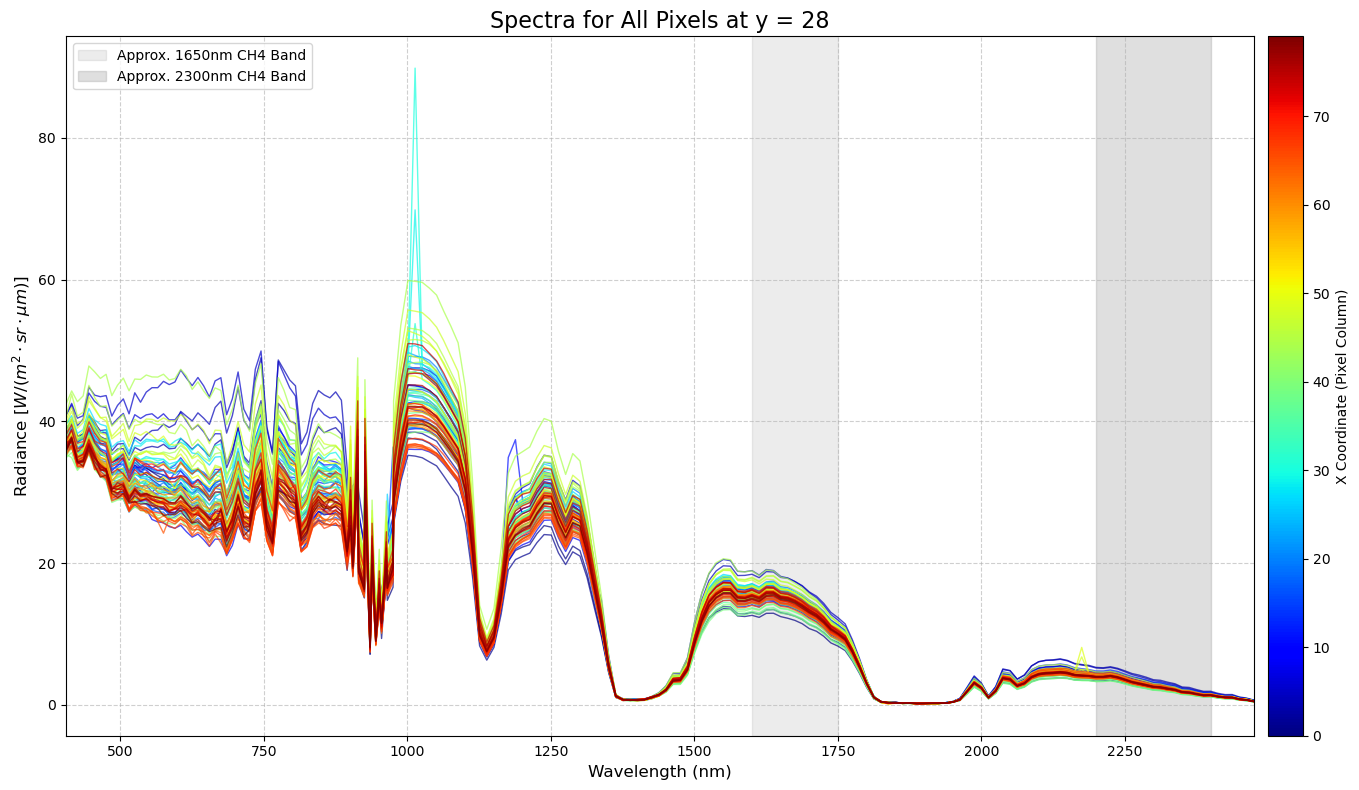

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import re

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# CSVファイルのパス
FILE_PATH = "all_pixel_spectra1.csv"

# ★ 解析したい y 座標を指定してください ★
TARGET_Y = 28 

# 異常検出（スパイク）のターゲット波長（文字列）
TARGET_WAVELENGTH_STR = "1675.39"
# =========================================================

# --- 処理開始 ---
print(f"--- Starting analysis for y = {TARGET_Y} ---")

# ターゲット波長に対応する列名
TARGET_COLUMN_NAME = f"wave_{TARGET_WAVELENGTH_STR}nm"

# --- 変更点: 出力ファイル名をPNGとEPSの両方用意 ---
OUTPUT_PLOT_PNG = f"spectra_y_{TARGET_Y}_plot.png"
OUTPUT_PLOT_EPS = f"spectra_y_{TARGET_Y}_plot.eps"

try:
    print(f"Loading spectral data from: {FILE_PATH}")
    # CSVを読み込む
    df_all_spectra = pd.read_csv(FILE_PATH)

    # --- 1. y座標でデータをフィルタリング ---
    print(f"Filtering for y = {TARGET_Y}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y].copy()
    
    if df_y_target.empty:
        print(f"Error: No data found for y = {TARGET_Y}. Stopping analysis.")
    
    else:
        print(f"Found {len(df_y_target)} pixels for y = {TARGET_Y}.")
        
        # --- 2. 波長データ（列名と数値）の準備 ---
        wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
        
        # (波長の数値, 列名) のタプルのリストを作成
        wavelength_tuples = []
        for col in wavelength_cols:
            try:
                # 正規表現で数値を抽出
                wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
                wavelength_tuples.append((wave_float, col))
            except Exception:
                print(f"Warning: Could not parse wavelength from '{col}'")
        
        # 波長の数値でソート
        wavelength_tuples.sort(key=lambda x: x[0])
        
        # ソート済みの波長（数値）と列名リストを再作成
        wavelengths_sorted_num = [wave for wave, col in wavelength_tuples]
        wavelengths_sorted_cols = [col for wave, col in wavelength_tuples]
        
        print(f"Extracted and sorted {len(wavelengths_sorted_num)} wavelength bands.")

        # --- 3. グラフの描画 (ソート順を使用) ---
        print(f"Generating plot... (Saving to {OUTPUT_PLOT_PNG} and {OUTPUT_PLOT_EPS})")
        fig, ax = plt.subplots(figsize=(15, 8))
        
        min_x = df_y_target['x'].min()
        max_x = df_y_target['x'].max()
        norm = plt.Normalize(vmin=min_x, vmax=max_x)
        cmap = plt.cm.jet
        
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            # ソート済みの列リストを使って値を取得
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            
            # ソート済みの波長（数値）をX軸に使用
            ax.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7, linewidth=1)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('X Coordinate (Pixel Column)')

        ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y}', fontsize=16)
        ax.set_xlabel('Wavelength (nm)', fontsize=12)
        ax.set_ylabel(r'Radiance [$W / (m^2 \cdot sr \cdot \mu m)$]', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # メタン吸収帯のハイライト
        ax.axvspan(1600, 1750, color='gray', alpha=0.15, label='Approx. 1650nm CH4 Band')
        ax.axvspan(2200, 2400, color='gray', alpha=0.25, label='Approx. 2300nm CH4 Band')
        ax.legend(loc='upper left')
        ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))

        plt.tight_layout()
        
        # --- 変更点: 保存処理 ---
        plt.savefig(OUTPUT_PLOT_PNG) # PNG保存
        plt.savefig(OUTPUT_PLOT_EPS, format='eps', bbox_inches='tight') # EPS保存
        
        print(f"Plot successfully saved to: {OUTPUT_PLOT_EPS}")


        # --- 4. 異常な x 座標の検出 ---
        print("\n--- Anomaly Detection (Spike) ---")
        
        # ターゲット列の存在確認
        if TARGET_COLUMN_NAME not in df_y_target.columns:
            print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found. Skipping anomaly detection.")
        
        else:
            # ソート済みリストからターゲットのインデックスを検索
            target_index = -1
            for i, (wave, col) in enumerate(wavelength_tuples):
                if col == TARGET_COLUMN_NAME:
                    target_index = i
                    break
            
            if target_index == -1:
                print(f"Error: Could not find '{TARGET_COLUMN_NAME}' in parsed wavelength list.")
            elif target_index == 0 or target_index == len(wavelength_tuples) - 1:
                print(f"Error: Target '{TARGET_COLUMN_NAME}' is the first or last wavelength.")
                print("Cannot find two neighbors to compare.")
            else:
                # 両隣の列名を決定
                left_neighbor_col = wavelength_tuples[target_index - 1][1]
                right_neighbor_col = wavelength_tuples[target_index + 1][1]
                
                print(f"Detecting spikes for '{TARGET_COLUMN_NAME}'")
                print(f"  Left neighbor:   {left_neighbor_col} ({wavelength_tuples[target_index - 1][0]}nm)")
                print(f"  Right neighbor:  {right_neighbor_col} ({wavelength_tuples[target_index + 1][0]}nm)")
                
                # 条件でフィルタリング
                condition = (
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[left_neighbor_col]) &
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[right_neighbor_col])
                )
                
                spiky_pixels_df = df_y_target[condition]
                
                # 結果の表示
                if spiky_pixels_df.empty:
                    print(f"\nResult: No pixels found at y={TARGET_Y} where '{TARGET_COLUMN_NAME}' is a local maximum.")
                else:
                    print(f"\nResult: Found {len(spiky_pixels_df)} pixels with a spike at {TARGET_WAVELENGTH_STR}nm:")
                    print("x coordinate | Left Val | Target Val | Right Val")
                    print("-" * 50)
                    for index, row in spiky_pixels_df.iterrows():
                        x_coord = row['x']
                        left_val = row[left_neighbor_col]
                        target_val = row[TARGET_COLUMN_NAME]
                        right_val = row[right_neighbor_col]
                        print(f"    {x_coord:4} | {left_val:8.4f} | {target_val:10.4f} | {right_val:8.4f}")

    print(f"\n--- Analysis for y = {TARGET_Y} finished. ---")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("Please make sure 'all_pixel_spectra.csv' is in the same directory.")
except KeyError as e:
    print(f"Error: A required column was not found (e.g., 'y', 'x', or wave columns). {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

--- Starting analysis for y = 28 ---
Loading spectral data from: E:\refit\all_ir_spectra.csv
Filtering for y = 28...
Found 80 pixels for y = 28.
Extracted and sorted 185 wavelength bands.
Generating plot... (Saving to spectra_y_28_plot.png and spectra_y_28_plot.eps)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Plot successfully saved to: spectra_y_28_plot.eps

--- Anomaly Detection (Spike) ---
Detecting spikes for 'wave_1675.39nm'

Result: Found 2 pixels with a spike at 1675.39nm:
x coordinate | Left Val | Target Val | Right Val
--------------------------------------------------
     3.0 |  15.7024 |    18.9344 |  17.0784
     4.0 |  16.0224 |    20.0896 |  17.8656

--- Analysis for y = 28 finished. ---


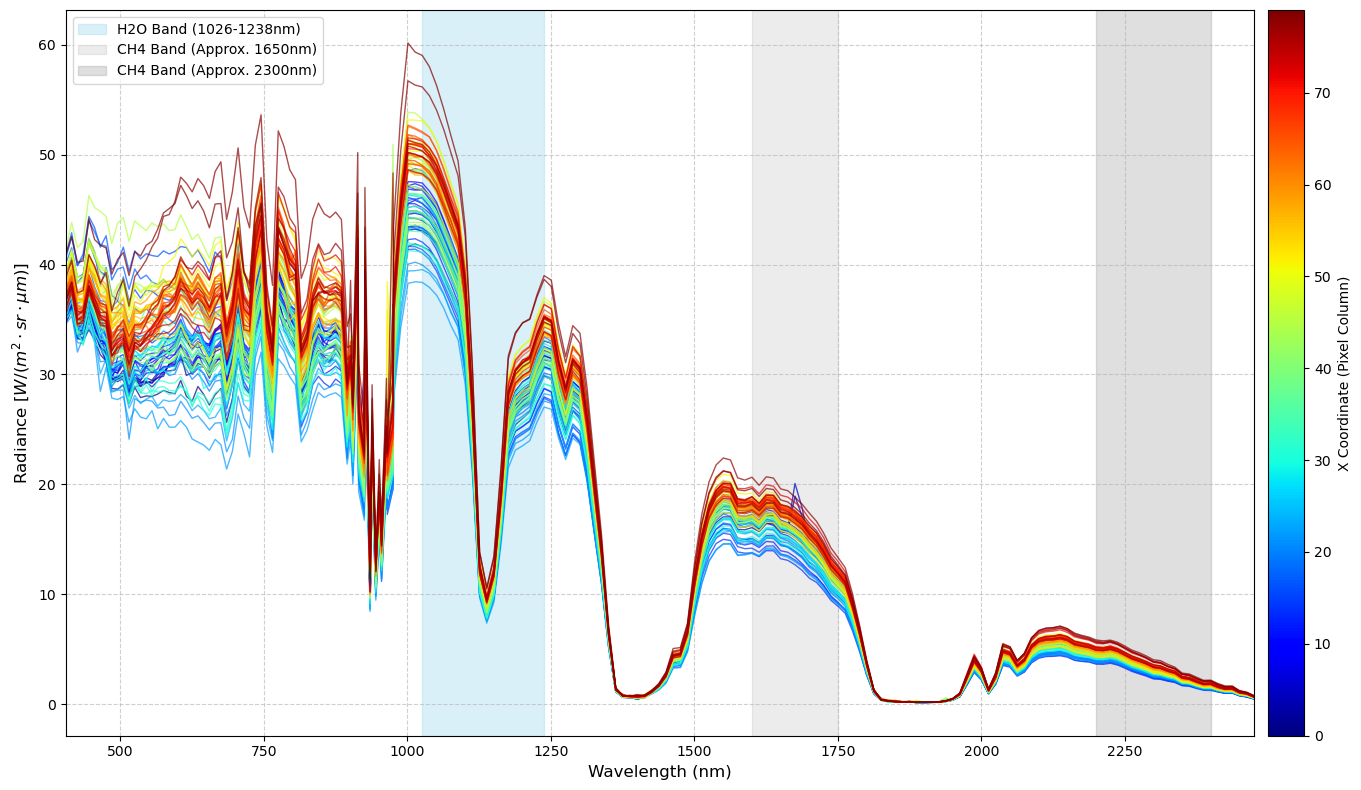

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import re

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# CSVファイルのパス
FILE_PATH = r"E:\refit\all_ir_spectra.csv"

# ★ 解析したい y 座標を指定してください ★
TARGET_Y = 28 

# 異常検出（スパイク）のターゲット波長（文字列）
TARGET_WAVELENGTH_STR = "1675.39"
# =========================================================

# --- 処理開始 ---
print(f"--- Starting analysis for y = {TARGET_Y} ---")

# ターゲット波長に対応する列名
TARGET_COLUMN_NAME = f"wave_{TARGET_WAVELENGTH_STR}nm"
# 出力ファイル名
OUTPUT_PLOT_PNG = f"spectra_y_{TARGET_Y}_plot.png"
OUTPUT_PLOT_EPS = f"spectra_y_{TARGET_Y}_plot.eps"

try:
    print(f"Loading spectral data from: {FILE_PATH}")
    # CSVを読み込む
    df_all_spectra = pd.read_csv(FILE_PATH)

    # --- 1. y座標でデータをフィルタリング ---
    print(f"Filtering for y = {TARGET_Y}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y].copy()
    
    if df_y_target.empty:
        print(f"Error: No data found for y = {TARGET_Y}. Stopping analysis.")
    
    else:
        print(f"Found {len(df_y_target)} pixels for y = {TARGET_Y}.")
        
        # --- 2. 波長データ（列名と数値）の準備 ---
        wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
        
        wavelength_tuples = []
        for col in wavelength_cols:
            try:
                wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
                wavelength_tuples.append((wave_float, col))
            except Exception:
                print(f"Warning: Could not parse wavelength from '{col}'")
        
        wavelength_tuples.sort(key=lambda x: x[0])
        
        wavelengths_sorted_num = [wave for wave, col in wavelength_tuples]
        wavelengths_sorted_cols = [col for wave, col in wavelength_tuples]
        
        print(f"Extracted and sorted {len(wavelengths_sorted_num)} wavelength bands.")

        # --- 3. グラフの描画 ---
        print(f"Generating plot... (Saving to {OUTPUT_PLOT_PNG} and {OUTPUT_PLOT_EPS})")
        fig, ax = plt.subplots(figsize=(15, 8))
        
        min_x = df_y_target['x'].min()
        max_x = df_y_target['x'].max()
        norm = plt.Normalize(vmin=min_x, vmax=max_x)
        cmap = plt.cm.jet
        
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7, linewidth=1)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('X Coordinate (Pixel Column)')

        ax.set_xlabel('Wavelength (nm)', fontsize=12)
        ax.set_ylabel(r'Radiance [$W / (m^2 \cdot sr \cdot \mu m)$]', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # --- ハイライト設定 ---
        
        # 1. H2Oバンド (追加部分)
        # 色は水色(skyblue)にし、識別しやすくしています
        ax.axvspan(1025.9, 1238.2, color='skyblue', alpha=0.3, label='H2O Band (1026-1238nm)')

        # 2. メタン吸収帯 (既存)
        ax.axvspan(1600, 1750, color='gray', alpha=0.15, label='CH4 Band (Approx. 1650nm)')
        ax.axvspan(2200, 2400, color='gray', alpha=0.25, label='CH4 Band (Approx. 2300nm)')
        
        # 凡例を表示
        ax.legend(loc='upper left')
        
        ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))

        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_PNG)
        plt.savefig(OUTPUT_PLOT_EPS, format='eps', bbox_inches='tight')
        print(f"Plot successfully saved to: {OUTPUT_PLOT_EPS}")


        # --- 4. 異常な x 座標の検出 ---
        print("\n--- Anomaly Detection (Spike) ---")
        
        if TARGET_COLUMN_NAME not in df_y_target.columns:
            print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found. Skipping anomaly detection.")
        
        else:
            target_index = -1
            for i, (wave, col) in enumerate(wavelength_tuples):
                if col == TARGET_COLUMN_NAME:
                    target_index = i
                    break
            
            if target_index == -1:
                print(f"Error: Could not find '{TARGET_COLUMN_NAME}' in parsed wavelength list.")
            elif target_index == 0 or target_index == len(wavelength_tuples) - 1:
                print(f"Error: Target '{TARGET_COLUMN_NAME}' is the first or last wavelength.")
            else:
                left_neighbor_col = wavelength_tuples[target_index - 1][1]
                right_neighbor_col = wavelength_tuples[target_index + 1][1]
                
                print(f"Detecting spikes for '{TARGET_COLUMN_NAME}'")
                
                condition = (
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[left_neighbor_col]) &
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[right_neighbor_col])
                )
                
                spiky_pixels_df = df_y_target[condition]
                
                if spiky_pixels_df.empty:
                    print(f"\nResult: No pixels found at y={TARGET_Y} where '{TARGET_COLUMN_NAME}' is a local maximum.")
                else:
                    print(f"\nResult: Found {len(spiky_pixels_df)} pixels with a spike at {TARGET_WAVELENGTH_STR}nm:")
                    print("x coordinate | Left Val | Target Val | Right Val")
                    print("-" * 50)
                    for index, row in spiky_pixels_df.iterrows():
                        x_coord = row['x']
                        left_val = row[left_neighbor_col]
                        target_val = row[TARGET_COLUMN_NAME]
                        right_val = row[right_neighbor_col]
                        print(f"    {x_coord:4} | {left_val:8.4f} | {target_val:10.4f} | {right_val:8.4f}")

    print(f"\n--- Analysis for y = {TARGET_Y} finished. ---")

except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

--- Starting analysis for y = 28 (Zoomed: 1600-1750nm) ---
Loading spectral data from: E:\refit\all_ir_spectra.csv
Generating zoomed plot... (Saving to spectra_y_28_zoom_1600-1750.eps)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Zoomed plot successfully saved to: spectra_y_28_zoom_1600-1750.eps


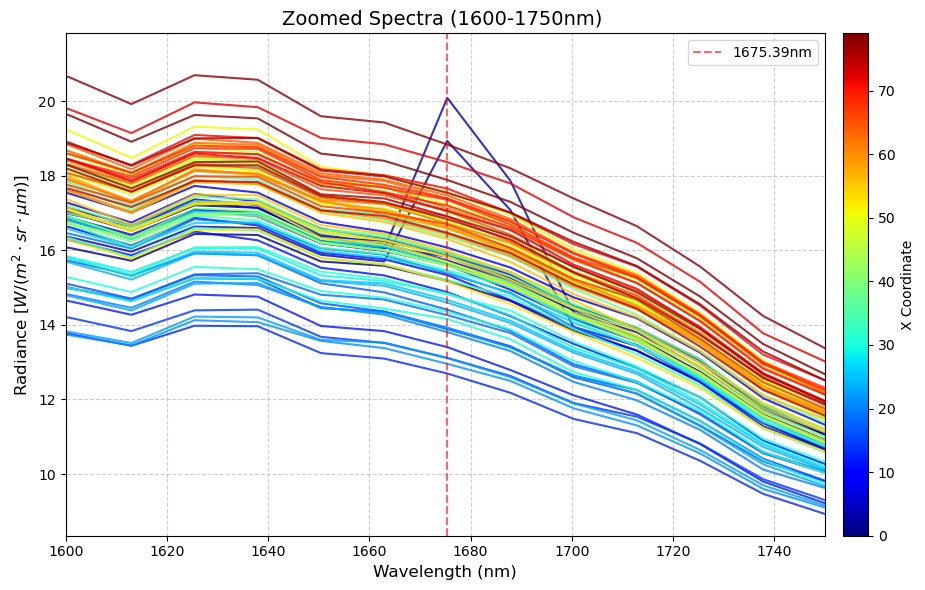

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import re

# =========================================================
# --- ユーザー設定 ---
# =========================================================
FILE_PATH = r"E:\refit\all_ir_spectra.csv"
TARGET_Y = 28 
TARGET_WAVELENGTH_STR = "1675.39"

# ★ 拡大したい範囲の設定 ★
ZOOM_START = 1600
ZOOM_END = 1750
# =========================================================

print(f"--- Starting analysis for y = {TARGET_Y} (Zoomed: {ZOOM_START}-{ZOOM_END}nm) ---")

TARGET_COLUMN_NAME = f"wave_{TARGET_WAVELENGTH_STR}nm"
# 出力ファイル名（拡大版であることを明記）
OUTPUT_PLOT_PNG = f"spectra_y_{TARGET_Y}_zoom_1600-1750.png"
OUTPUT_PLOT_EPS = f"spectra_y_{TARGET_Y}_zoom_1600-1750.eps"

try:
    print(f"Loading spectral data from: {FILE_PATH}")
    df_all_spectra = pd.read_csv(FILE_PATH)

    # --- 1. y座標フィルタリング ---
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y].copy()
    
    if df_y_target.empty:
        print(f"Error: No data found for y = {TARGET_Y}.")
    
    else:
        # --- 2. 波長データの準備 ---
        wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
        wavelength_tuples = []
        for col in wavelength_cols:
            try:
                wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
                wavelength_tuples.append((wave_float, col))
            except Exception:
                pass
        
        wavelength_tuples.sort(key=lambda x: x[0])
        wavelengths_sorted_num = [wave for wave, col in wavelength_tuples]
        wavelengths_sorted_cols = [col for wave, col in wavelength_tuples]

        # --- 3. グラフ描画（拡大版） ---
        print(f"Generating zoomed plot... (Saving to {OUTPUT_PLOT_EPS})")
        
        fig, ax = plt.subplots(figsize=(10, 6)) # 拡大図なので少しアスペクト比を変更
        
        # カラーマップ設定
        min_x = df_y_target['x'].min()
        max_x = df_y_target['x'].max()
        norm = plt.Normalize(vmin=min_x, vmax=max_x)
        cmap = plt.cm.jet
        
        # プロットループ
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.8, linewidth=1.5)

        # カラーバー
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label('X Coordinate')

        # ラベル設定
        ax.set_title(f'Zoomed Spectra (1600-1750nm) ', fontsize=14)
        ax.set_xlabel('Wavelength (nm)', fontsize=12)
        ax.set_ylabel(r'Radiance [$W / (m^2 \cdot sr \cdot \mu m)$]', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

        # --- ★ 重要な変更点: 表示範囲の制限（ズーム） ---
        ax.set_xlim(ZOOM_START, ZOOM_END)

        # --- Y軸の最適化 ---
        # 拡大範囲内のデータだけで最小値・最大値を計算し、Y軸を見やすく調整する
        # これをしないと、グラフ全体（他の波長）の影響で線がぺちゃんこに見える可能性があります
        zoom_cols = [col for wave, col in wavelength_tuples if ZOOM_START <= wave <= ZOOM_END]
        if zoom_cols:
            y_data_in_range = df_y_target[zoom_cols].values
            y_min = np.min(y_data_in_range)
            y_max = np.max(y_data_in_range)
            margin = (y_max - y_min) * 0.1 # 上下に10%の余白
            ax.set_ylim(y_min - margin, y_max + margin)

        # --- ターゲット波長の強調 ---
        # 範囲全体を塗りつぶすと見づらくなるため、特定のターゲット波長に縦線を入れる
        target_wave_val = float(TARGET_WAVELENGTH_STR)
        ax.axvline(x=target_wave_val, color='red', linestyle='--', alpha=0.6, label=f'{TARGET_WAVELENGTH_STR}nm')
        ax.legend(loc='upper right')

        plt.tight_layout()
        
        # 保存
        plt.savefig(OUTPUT_PLOT_PNG)
        plt.savefig(OUTPUT_PLOT_EPS, format='eps', bbox_inches='tight')
        print(f"Zoomed plot successfully saved to: {OUTPUT_PLOT_EPS}")

except Exception as e:
    print(f"An error occurred: {e}")
    traceback.print_exc()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import re

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# CSVファイルのパス
FILE_PATH = "all_pixel_spectra.csv"

# ★ 解析したい y 座標を指定してください ★
TARGET_Y = 2

# 異常検出（スパイク）のターゲット波長（文字列）
TARGET_WAVELENGTH_STR = "1675.39"

# CH4 バンドの範囲
BAND1_RANGE = (1600, 1750)
BAND2_RANGE = (2200, 2400)
# =========================================================

# --- 処理開始 ---
print(f"--- Starting analysis for y = {TARGET_Y} ---")

# ターゲット波長に対応する列名
TARGET_COLUMN_NAME = f"wave_{TARGET_WAVELENGTH_STR}nm"
# 出力するグラフのファイル名
OUTPUT_PLOT_FULL = f"spectra_y_{TARGET_Y}_plot.png"
OUTPUT_PLOT_B1 = f"spectra_y_{TARGET_Y}_band1_{BAND1_RANGE[0]}-{BAND1_RANGE[1]}nm_plot.png"
OUTPUT_PLOT_B2 = f"spectra_y_{TARGET_Y}_band2_{BAND2_RANGE[0]}-{BAND2_RANGE[1]}nm_plot.png"

try:
    print(f"Loading spectral data from: {FILE_PATH}")
    # CSVを読み込む
    df_all_spectra = pd.read_csv(FILE_PATH)

    # --- 1. y座標でデータをフィルタリング ---
    print(f"Filtering for y = {TARGET_Y}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y].copy()
    
    if df_y_target.empty:
        print(f"Error: No data found for y = {TARGET_Y}. Stopping analysis.")
    
    else:
        print(f"Found {len(df_y_target)} pixels for y = {TARGET_Y}.")
        
        # --- 2. 波長データ（列名と数値）の準備 ---
        wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
        
        wavelength_tuples = []
        for col in wavelength_cols:
            try:
                # 正規表現で数値を抽出
                wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
                wavelength_tuples.append((wave_float, col))
            except Exception:
                print(f"Warning: Could not parse wavelength from '{col}'")
        
        # 波長の数値でソート
        wavelength_tuples.sort(key=lambda x: x[0])
        
        wavelengths_sorted_num = np.array([wave for wave, col in wavelength_tuples])
        wavelengths_sorted_cols = [col for wave, col in wavelength_tuples]
        
        print(f"Extracted and sorted {len(wavelengths_sorted_num)} wavelength bands.")

        # --- 3. グラフ描画の共通設定 ---
        min_x = df_y_target['x'].min()
        max_x = df_y_target['x'].max()
        norm = plt.Normalize(vmin=min_x, vmax=max_x)
        cmap = plt.cm.jet

        # --- 3a. グラフの描画 (フル範囲) ---
        print(f"Generating plot (Full Range)... (Saving to {OUTPUT_PLOT_FULL})")
        fig, ax = plt.subplots(figsize=(15, 8))
        
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7, linewidth=1)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('X Coordinate (Pixel Column)')
        ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y} (Full Range)', fontsize=16)
        ax.set_xlabel('Wavelength (nm)', fontsize=12)
        ax.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        # バンド範囲をハイライト
        ax.axvspan(BAND1_RANGE[0], BAND1_RANGE[1], color='gray', alpha=0.15, label=f'CH4 Band 1 ({BAND1_RANGE[0]}-{BAND1_RANGE[1]}nm)')
        ax.axvspan(BAND2_RANGE[0], BAND2_RANGE[1], color='gray', alpha=0.25, label=f'CH4 Band 2 ({BAND2_RANGE[0]}-{BAND2_RANGE[1]}nm)')
        ax.legend(loc='upper left')
        ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))

        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_FULL)
        print(f"Plot successfully saved to: {OUTPUT_PLOT_FULL}")
        plt.close(fig) # メモリ解放

        # --- 3b. グラフの描画 (CH4 Band 1) ---
        print(f"Generating plot (Band 1: {BAND1_RANGE}nm)... (Saving to {OUTPUT_PLOT_B1})")
        fig_b1, ax_b1 = plt.subplots(figsize=(12, 7))
        
        # Y軸スケーリングのためのデータ抽出
        band1_indices = np.where((wavelengths_sorted_num >= BAND1_RANGE[0]) & (wavelengths_sorted_num <= BAND1_RANGE[1]))[0]
        if band1_indices.size > 0:
            band1_cols = [wavelengths_sorted_cols[i] for i in band1_indices]
            band1_data = df_y_target[band1_cols]
            y_min1 = band1_data.min().min()
            y_max1 = band1_data.max().max()
            margin1 = (y_max1 - y_min1) * 0.05 # 5%のマージン
            ax_b1.set_ylim(y_min1 - margin1, y_max1 + margin1)
        
        # プロット
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax_b1.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7)

        sm_b1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm_b1.set_array([])
        cbar_b1 = fig_b1.colorbar(sm_b1, ax=ax_b1, pad=0.01)
        cbar_b1.set_label('X Coordinate (Pixel Column)')
        ax_b1.set_title(f'Spectra at y = {TARGET_Y} (CH4 Band 1: {BAND1_RANGE}nm)', fontsize=16)
        ax_b1.set_xlabel('Wavelength (nm)', fontsize=12)
        ax_b1.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax_b1.grid(True, linestyle='--', alpha=0.6)
        ax_b1.set_xlim(BAND1_RANGE[0], BAND1_RANGE[1]) # X軸をズーム
        
        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_B1)
        print(f"Plot successfully saved to: {OUTPUT_PLOT_B1}")
        plt.close(fig_b1) # メモリ解放

        # --- 3c. グラフの描画 (CH4 Band 2) ---
        print(f"Generating plot (Band 2: {BAND2_RANGE}nm)... (Saving to {OUTPUT_PLOT_B2})")
        fig_b2, ax_b2 = plt.subplots(figsize=(12, 7))
        
        # Y軸スケーリングのためのデータ抽出
        band2_indices = np.where((wavelengths_sorted_num >= BAND2_RANGE[0]) & (wavelengths_sorted_num <= BAND2_RANGE[1]))[0]
        if band2_indices.size > 0:
            band2_cols = [wavelengths_sorted_cols[i] for i in band2_indices]
            band2_data = df_y_target[band2_cols]
            y_min2 = band2_data.min().min()
            y_max2 = band2_data.max().max()
            margin2 = (y_max2 - y_min2) * 0.05 # 5%のマージン
            ax_b2.set_ylim(y_min2 - margin2, y_max2 + margin2)

        # プロット
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax_b2.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7)

        sm_b2 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm_b2.set_array([])
        cbar_b2 = fig_b2.colorbar(sm_b2, ax=ax_b2, pad=0.01)
        cbar_b2.set_label('X Coordinate (Pixel Column)')
        ax_b2.set_title(f'Spectra at y = {TARGET_Y} (CH4 Band 2: {BAND2_RANGE}nm)', fontsize=16)
        ax_b2.set_xlabel('Wavelength (nm)', fontsize=12)
        ax_b2.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax_b2.grid(True, linestyle='--', alpha=0.6)
        ax_b2.set_xlim(BAND2_RANGE[0], BAND2_RANGE[1]) # X軸をズーム

        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_B2)
        print(f"Plot successfully saved to: {OUTPUT_PLOT_B2}")
        plt.close(fig_b2) # メモリ解放
        
        # --- 4. 異常な x 座標（スパイク）の検出 ---
        # (このセクションは前回のコードから変更なし)
        print("\n--- Anomaly Detection (Spike) ---")
        
        if TARGET_COLUMN_NAME not in df_y_target.columns:
            print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found. Skipping anomaly detection.")
        
        else:
            # ソート済みリストからターゲットのインデックスを検索
            target_index = -1
            for i, (wave, col) in enumerate(wavelength_tuples):
                if col == TARGET_COLUMN_NAME:
                    target_index = i
                    break
            
            if target_index == -1:
                print(f"Error: Could not find '{TARGET_COLUMN_NAME}' in parsed wavelength list.")
            elif target_index == 0 or target_index == len(wavelength_tuples) - 1:
                print(f"Error: Target '{TARGET_COLUMN_NAME}' is the first or last wavelength.")
            else:
                # 両隣の列名を決定
                left_neighbor_col = wavelength_tuples[target_index - 1][1]
                right_neighbor_col = wavelength_tuples[target_index + 1][1]
                
                print(f"Detecting spikes for '{TARGET_COLUMN_NAME}'")
                print(f"  Left neighbor:   {left_neighbor_col} ({wavelength_tuples[target_index - 1][0]}nm)")
                print(f"  Right neighbor:  {right_neighbor_col} ({wavelength_tuples[target_index + 1][0]}nm)")
                
                # 条件でフィルタリング
                condition = (
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[left_neighbor_col]) &
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[right_neighbor_col])
                )
                
                spiky_pixels_df = df_y_target[condition]
                
                # 結果の表示
                if spiky_pixels_df.empty:
                    print(f"\nResult: No pixels found at y={TARGET_Y} where '{TARGET_COLUMN_NAME}' is a local maximum.")
                else:
                    print(f"\nResult: Found {len(spiky_pixels_df)} pixels with a spike at {TARGET_WAVELENGTH_STR}nm:")
                    print("x coordinate | Left Val | Target Val | Right Val")
                    print("-" * 50)
                    for index, row in spiky_pixels_df.iterrows():
                        x_coord = row['x']
                        left_val = row[left_neighbor_col]
                        target_val = row[TARGET_COLUMN_NAME]
                        right_val = row[right_neighbor_col]
                        print(f"    {x_coord:4} | {left_val:8.4f} | {target_val:10.4f} | {right_val:8.4f}")

    print(f"\n--- Analysis for y = {TARGET_Y} finished. ---")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("Please make sure 'all_pixel_spectra.csv' is in the same directory.")
except KeyError as e:
    print(f"Error: A required column was not found (e.g., 'y', 'x', or wave columns). {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

--- Starting analysis for y = 2 ---
Loading spectral data from: all_pixel_spectra.csv
Filtering for y = 2...
Found 40 pixels for y = 2.
Extracted and sorted 185 wavelength bands.
Generating plot (Full Range)... (Saving to spectra_y_2_plot.png)
Plot successfully saved to: spectra_y_2_plot.png
Generating plot (Band 1: (1600, 1750)nm)... (Saving to spectra_y_2_band1_1600-1750nm_plot.png)
Plot successfully saved to: spectra_y_2_band1_1600-1750nm_plot.png
Generating plot (Band 2: (2200, 2400)nm)... (Saving to spectra_y_2_band2_2200-2400nm_plot.png)
Plot successfully saved to: spectra_y_2_band2_2200-2400nm_plot.png

--- Anomaly Detection (Spike) ---
Detecting spikes for 'wave_1675.39nm'
  Left neighbor:   wave_1662.90nm (1662.9nm)
  Right neighbor:  wave_1687.88nm (1687.88nm)

Result: No pixels found at y=2 where 'wave_1675.39nm' is a local maximum.

--- Analysis for y = 2 finished. ---


In [20]:
# --- 1. 新しいスライスを定義 ---
center = np.array([750, 750]) #中心座標(y, x)
y_start = center[0] - 1
y_end = center[0] + 1
x_start = center[1] - 730
x_end = center[1] + 500

# img, param はこのセルより前に定義されている必要があります
img_slice_new = img[y_start : y_end, x_start : x_end, :] #補正後の画像

print(f"New img_slice shape: {img_slice_new.shape}") # (2, 1230, C) になるはず

# --- 2. 新しいスライスでCSVを「再作成」または「新規保存」 ---
# ★ このファイル名を、次のステップの分析コードの FILE_PATH と一致させます
NEW_CSV_NAME = "all_pixel_spectra_2x1230.csv" 

try:
    # save_all_spectra_to_csv 関数を呼び出して、新しいCSVを作成
    save_all_spectra_to_csv(img_slice_new, param, output_filename=NEW_CSV_NAME)
    
    print(f"\nSuccessfully created new CSV: {NEW_CSV_NAME}")
    print(f"This new CSV has y coordinates 0 to {img_slice_new.shape[0] - 1}") # y は 0 と 1 のはず
    print(f"And x coordinates 0 to {img_slice_new.shape[1] - 1}") # x は 0 から 1229 のはず

except NameError as e:
    print(f"Error: {e}. Make sure 'img', 'param', and 'save_all_spectra_to_csv' are defined in previous cells.")
except Exception as e:
    print(f"An error occurred: {e}")
    traceback.print_exc()

New img_slice shape: (2, 1230, 185)
Exporting all spectra for 2x1230 image (185 bands)...
Combining coordinate and pixel data...
Creating DataFrame (this may take time for large images)...
Saving to all_pixel_spectra_2x1230.csv...
Successfully saved all spectra to all_pixel_spectra_2x1230.csv. (Took 1.52s)

Successfully created new CSV: all_pixel_spectra_2x1230.csv
This new CSV has y coordinates 0 to 1
And x coordinates 0 to 1229


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import re

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# CSVファイルのパスを「ステップ1で作成した新しいCSV」に変更
FILE_PATH = "all_pixel_spectra_2x1230.csv"

# ★ 解析したい y 座標を指定（今度のスライスは 0 か 1 のみ）★
TARGET_Y = 0 # 0 または 1 を指定

# 異常検出（スパイク）のターゲット波長（文字列）
TARGET_WAVELENGTH_STR = "1675.39"

# CH4 バンドの範囲
BAND1_RANGE = (1600, 1700)
BAND2_RANGE = (2200, 2400)
# =========================================================

# --- 処理開始 ---
print(f"--- Starting analysis for y = {TARGET_Y} ---")
print(f"Reading from: {FILE_PATH}") # 読み込むファイル名を確認

# ターゲット波長に対応する列名
TARGET_COLUMN_NAME = f"wave_{TARGET_WAVELENGTH_STR}nm"
# 出力するグラフのファイル名
OUTPUT_PLOT_FULL = f"spectra_y_{TARGET_Y}_plot.png"
OUTPUT_PLOT_B1 = f"spectra_y_{TARGET_Y}_band1_{BAND1_RANGE[0]}-{BAND1_RANGE[1]}nm_plot.png"
OUTPUT_PLOT_B2 = f"spectra_y_{TARGET_Y}_band2_{BAND2_RANGE[0]}-{BAND2_RANGE[1]}nm_plot.png"

try:
    print(f"Loading spectral data from: {FILE_PATH}")
    df_all_spectra = pd.read_csv(FILE_PATH)

    # ... (以降の分析コードは、前回とまったく同じ) ...
    
    # --- 1. y座標でデータをフィルタリング ---
    print(f"Filtering for y = {TARGET_Y}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y].copy()
    
    if df_y_target.empty:
        print(f"Error: No data found for y = {TARGET_Y}. Stopping analysis.")
        print(f"Check your 'TARGET_Y' setting. Valid y values in this file should be 0 or 1.")
    
    else:
        # ★ ここで表示されるピクセル数が 1230 になるはずです
        print(f"Found {len(df_y_target)} pixels for y = {TARGET_Y}.") 
        
        # --- 2. 波長データ（列名と数値）の準備 ---
        wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
        
        wavelength_tuples = []
        for col in wavelength_cols:
            try:
                wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
                wavelength_tuples.append((wave_float, col))
            except Exception:
                print(f"Warning: Could not parse wavelength from '{col}'")
        
        wavelength_tuples.sort(key=lambda x: x[0])
        
        wavelengths_sorted_num = np.array([wave for wave, col in wavelength_tuples])
        wavelengths_sorted_cols = [col for wave, col in wavelength_tuples]
        
        print(f"Extracted and sorted {len(wavelengths_sorted_num)} wavelength bands.")

        # --- 3. グラフ描画の共通設定 ---
        min_x = df_y_target['x'].min()
        max_x = df_y_target['x'].max() # 1229 になるはず
        norm = plt.Normalize(vmin=min_x, vmax=max_x)
        cmap = plt.cm.jet

        # --- 3a. グラフの描画 (フル範囲) ---
        print(f"Generating plot (Full Range)... (Saving to {OUTPUT_PLOT_FULL})")
        fig, ax = plt.subplots(figsize=(15, 8))
        
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7, linewidth=1)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)
        # ★ カラーバーのラベルが 0 から 1229 までの範囲になります
        cbar.set_label('X Coordinate (Pixel Column)') 
        ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y} (Full Range)', fontsize=16)
        ax.set_xlabel('Wavelength (nm)', fontsize=12)
        ax.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.axvspan(BAND1_RANGE[0], BAND1_RANGE[1], color='gray', alpha=0.15, label=f'CH4 Band 1 ({BAND1_RANGE[0]}-{BAND1_RANGE[1]}nm)')
        ax.axvspan(BAND2_RANGE[0], BAND2_RANGE[1], color='gray', alpha=0.25, label=f'CH4 Band 2 ({BAND2_RANGE[0]}-{BAND2_RANGE[1]}nm)')
        ax.legend(loc='upper left')
        ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))

        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_FULL)
        print(f"Plot successfully saved to: {OUTPUT_PLOT_FULL}")
        plt.close(fig) 

        # --- 3b. グラフの描画 (CH4 Band 1) ---
        print(f"Generating plot (Band 1: {BAND1_RANGE}nm)... (Saving to {OUTPUT_PLOT_B1})")
        fig_b1, ax_b1 = plt.subplots(figsize=(12, 7))
        
        band1_indices = np.where((wavelengths_sorted_num >= BAND1_RANGE[0]) & (wavelengths_sorted_num <= BAND1_RANGE[1]))[0]
        if band1_indices.size > 0:
            band1_cols = [wavelengths_sorted_cols[i] for i in band1_indices]
            band1_data = df_y_target[band1_cols]
            y_min1 = band1_data.min().min()
            y_max1 = band1_data.max().max()
            margin1 = (y_max1 - y_min1) * 0.05
            ax_b1.set_ylim(y_min1 - margin1, y_max1 + margin1)
        
        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax_b1.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7)

        sm_b1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm_b1.set_array([])
        cbar_b1 = fig_b1.colorbar(sm_b1, ax=ax_b1, pad=0.01)
        cbar_b1.set_label('X Coordinate (Pixel Column)')
        ax_b1.set_title(f'Spectra at y = {TARGET_Y} (CH4 Band 1: {BAND1_RANGE}nm)', fontsize=16)
        ax_b1.set_xlabel('Wavelength (nm)', fontsize=12)
        ax_b1.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax_b1.grid(True, linestyle='--', alpha=0.6)
        ax_b1.set_xlim(BAND1_RANGE[0], BAND1_RANGE[1])
        
        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_B1)
        print(f"Plot successfully saved to: {OUTPUT_PLOT_B1}")
        plt.close(fig_b1)

        # --- 3c. グラフの描画 (CH4 Band 2) ---
        print(f"Generating plot (Band 2: {BAND2_RANGE}nm)... (Saving to {OUTPUT_PLOT_B2})")
        fig_b2, ax_b2 = plt.subplots(figsize=(12, 7))
        
        band2_indices = np.where((wavelengths_sorted_num >= BAND2_RANGE[0]) & (wavelengths_sorted_num <= BAND2_RANGE[1]))[0]
        if band2_indices.size > 0:
            band2_cols = [wavelengths_sorted_cols[i] for i in band2_indices]
            band2_data = df_y_target[band2_cols]
            y_min2 = band2_data.min().min()
            y_max2 = band2_data.max().max()
            margin2 = (y_max2 - y_min2) * 0.05
            ax_b2.set_ylim(y_min2 - margin2, y_max2 + margin2)

        for index, row in df_y_target.iterrows():
            x_coord = row['x']
            spectral_values = row[wavelengths_sorted_cols].values.astype(float)
            color = cmap(norm(x_coord))
            ax_b2.plot(wavelengths_sorted_num, spectral_values, color=color, alpha=0.7)

        sm_b2 = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm_b2.set_array([])
        cbar_b2 = fig_b2.colorbar(sm_b2, ax=ax_b2, pad=0.01)
        cbar_b2.set_label('X Coordinate (Pixel Column)')
        ax_b2.set_title(f'Spectra at y = {TARGET_Y} (CH4 Band 2: {BAND2_RANGE}nm)', fontsize=16)
        ax_b2.set_xlabel('Wavelength (nm)', fontsize=12)
        ax_b2.set_ylabel('Spectral Value (Radiance)', fontsize=12)
        ax_b2.grid(True, linestyle='--', alpha=0.6)
        ax_b2.set_xlim(BAND2_RANGE[0], BAND2_RANGE[1])

        plt.tight_layout()
        plt.savefig(OUTPUT_PLOT_B2)
        print(f"Plot successfully saved to: {OUTPUT_PLOT_B2}")
        plt.close(fig_b2)
        
        # --- 4. 異常な x 座標（スパイク）の検出 ---
        print("\n--- Anomaly Detection (Spike) ---")
        
        if TARGET_COLUMN_NAME not in df_y_target.columns:
            print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found. Skipping anomaly detection.")
        
        else:
            target_index = -1
            for i, (wave, col) in enumerate(wavelength_tuples):
                if col == TARGET_COLUMN_NAME:
                    target_index = i
                    break
            
            if target_index == -1:
                print(f"Error: Could not find '{TARGET_COLUMN_NAME}' in parsed wavelength list.")
            elif target_index == 0 or target_index == len(wavelength_tuples) - 1:
                print(f"Error: Target '{TARGET_COLUMN_NAME}' is the first or last wavelength.")
            else:
                left_neighbor_col = wavelength_tuples[target_index - 1][1]
                right_neighbor_col = wavelength_tuples[target_index + 1][1]
                
                print(f"Detecting spikes for '{TARGET_COLUMN_NAME}'")
                print(f"  Left neighbor:   {left_neighbor_col} ({wavelength_tuples[target_index - 1][0]}nm)")
                print(f"  Right neighbor:  {right_neighbor_col} ({wavelength_tuples[target_index + 1][0]}nm)")
                
                condition = (
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[left_neighbor_col]) &
                    (df_y_target[TARGET_COLUMN_NAME] > df_y_target[right_neighbor_col])
                )
                
                spiky_pixels_df = df_y_target[condition]
                
                if spiky_pixels_df.empty:
                    print(f"\nResult: No pixels found at y={TARGET_Y} where '{TARGET_COLUMN_NAME}' is a local maximum.")
                else:
                    print(f"\nResult: Found {len(spiky_pixels_df)} pixels with a spike at {TARGET_WAVELENGTH_STR}nm:")
                    print("x coordinate | Left Val | Target Val | Right Val")
                    print("-" * 50)
                    for index, row in spiky_pixels_df.iterrows():
                        x_coord = row['x']
                        left_val = row[left_neighbor_col]
                        target_val = row[TARGET_COLUMN_NAME]
                        right_val = row[right_neighbor_col]
                        print(f"    {x_coord:4} | {left_val:8.4f} | {target_val:10.4f} | {right_val:8.4f}")

    print(f"\n--- Analysis for y = {TARGET_Y} finished. ---")

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("Please make sure 'all_pixel_spectra.csv' is in the same directory.")
except KeyError as e:
    print(f"Error: A required column was not found (e.g., 'y', 'x', or wave columns). {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

--- Starting analysis for y = 0 ---
Reading from: all_pixel_spectra_2x1230.csv
Loading spectral data from: all_pixel_spectra_2x1230.csv
Filtering for y = 0...
Found 1230 pixels for y = 0.
Extracted and sorted 185 wavelength bands.
Generating plot (Full Range)... (Saving to spectra_y_0_plot.png)
Plot successfully saved to: spectra_y_0_plot.png
Generating plot (Band 1: (1600, 1700)nm)... (Saving to spectra_y_0_band1_1600-1700nm_plot.png)
Plot successfully saved to: spectra_y_0_band1_1600-1700nm_plot.png
Generating plot (Band 2: (2200, 2400)nm)... (Saving to spectra_y_0_band2_2200-2400nm_plot.png)
Plot successfully saved to: spectra_y_0_band2_2200-2400nm_plot.png

--- Anomaly Detection (Spike) ---
Detecting spikes for 'wave_1675.39nm'
  Left neighbor:   wave_1662.90nm (1662.9nm)
  Right neighbor:  wave_1687.88nm (1687.88nm)

Result: Found 3 pixels with a spike at 1675.39nm:
x coordinate | Left Val | Target Val | Right Val
--------------------------------------------------
    1219.0 |  14

Analyzing Global Y=750 (Local Y=1 in CSV)
Loading spectral data from: all_pixel_spectra_2x1230.csv
Filtering for local y = 1...
Found 1230 pixels (x_local 0 to 1229)
Parsing wavelengths from CSV headers...
Generating full-range plot...
Saved full-range plot: spectra_y_750_plot.png

--- Detecting anomalies for approx 1675.395nm (Threshold > 0.0) ---
Target: 1675.395nm -> Closest match: 1675.39nm (Column: wave_1675.39nm)
Result: Found 3 pixels with a spike at 1675.39nm (Threshold > 0.0):
  x_local | x_global | Left Val | Target Val | Right Val
------------------------------------------------------------
     1220 |     1240 |  14.3808 |    15.2736 |  14.3680
     1221 |     1241 |  15.1456 |    20.4160 |  17.9232
     1222 |     1242 |  19.6384 |    21.6000 |  20.1024

--- Detecting anomalies for approx 1625.435nm (Threshold > 3.0) ---
Target: 1625.435nm -> Closest match: 1625.43nm (Column: wave_1625.43nm)
Result: Found 2 pixels with a spike at 1625.43nm (Threshold > 3.0):
  x_local | x_

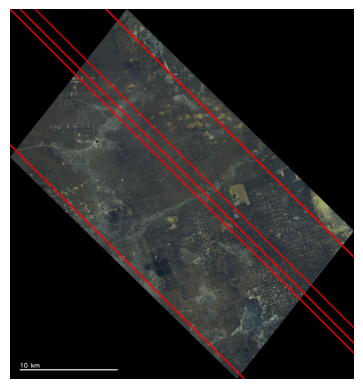

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import traceback
import cv2 # <-- OpenCV をインポート

# ---  helper functions (for this cell) ---

def find_closest_wavelength(wavelength_tuples, target_wave_val):
    """
    ソート済みの(波長[float], 列名[str])タプルのリストから、
    target_wave_valに最も近い波長を見つけ、その列名と両隣の列名を返す。
    """
    if not wavelength_tuples:
        raise ValueError("Wavelength list is empty.")
    wave_floats = np.array([w[0] for w in wavelength_tuples])
    idx = np.searchsorted(wave_floats, target_wave_val, side='left')
    
    target_index = -1
    if idx == 0: target_index = 0
    elif idx == len(wave_floats): target_index = len(wave_floats) - 1
    else:
        dist_left = target_wave_val - wave_floats[idx - 1]
        dist_right = wave_floats[idx] - target_wave_val
        if dist_left < dist_right: target_index = idx - 1
        else: target_index = idx
            
    if target_index == 0:
        raise ValueError(f"Target {target_wave_val} matches {wave_floats[target_index]}, which is the first band. Cannot check neighbors.")
    if target_index == len(wave_floats) - 1:
        raise ValueError(f"Target {target_wave_val} matches {wave_floats[target_index]}, which is the last band. Cannot check neighbors.")

    target_col = wavelength_tuples[target_index][1]
    left_col = wavelength_tuples[target_index - 1][1]
    right_col = wavelength_tuples[target_index + 1][1]
    
    print(f"Target: {target_wave_val}nm -> Closest match: {wave_floats[target_index]}nm (Column: {target_col})")
    
    return target_col, left_col, right_col, wave_floats[target_index]

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# (作成済みのCSVファイル)
FILE_PATH = "all_pixel_spectra_2x1230.csv" 

# スライスの定義 (CSV作成時と一致させる)
SLICE_CENTER = [750, 750]
Y_RANGE = [SLICE_CENTER[0] - 1, SLICE_CENTER[0] + 1]  # (749, 751)
X_RANGE = [SLICE_CENTER[1] - 730, SLICE_CENTER[1] + 500] # (20, 1250)

# 解析したい「グローバルY座標」 (750)
TARGET_Y_GLOBAL = 750

# 検出したい波長（近似値）と閾値
ANOMALY_CHECKS = [
    (1675.395, 0.0), # local max
    (1625.435, 3.0), # local max + 3.0
    (2199.975, 1.0), # local max + 3.0
    (2212.465, 1.0), # local max + 3.0
    (2362.345, 0.3)  # local max + 3.0
]

# 描画する線の設定
LINE_THICKNESS = 5 # 線の太さ
LINE_COLOR_BGR = (0, 0, 255) # (OpenCV BGR 順) 0, 0, 255 = 赤

# ★ 画像のフルサイズ (線の終点計算用)
FULL_IMAGE_SHAPE = (1793, 1892) # (height, width)
# =========================================================


try:
    # --- 1. グローバルY座標をローカルY座標に変換 ---
    Y_OFFSET = Y_RANGE[0] # 749
    TARGET_Y_LOCAL = TARGET_Y_GLOBAL - Y_OFFSET # 750 - 749 = 1
    X_OFFSET = X_RANGE[0] # 20
    print(f"Analyzing Global Y={TARGET_Y_GLOBAL} (Local Y={TARGET_Y_LOCAL} in CSV)")

    # --- 2. データの読み込みと準備 ---
    print(f"Loading spectral data from: {FILE_PATH}")
    df_all_spectra = pd.read_csv(FILE_PATH)

    print(f"Filtering for local y = {TARGET_Y_LOCAL}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y_LOCAL].copy()
    
    if df_y_target.empty:
        raise ValueError(f"No data found for local y = {TARGET_Y_LOCAL}. Did you run Step 1 to recreate the CSV?")
    
    print(f"Found {len(df_y_target)} pixels (x_local 0 to {len(df_y_target)-1})")
    
    # --- 3. 波長リストの解析 ---
    print("Parsing wavelengths from CSV headers...")
    wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
    wavelength_tuples = []
    for col in wavelength_cols:
        try:
            wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
            wavelength_tuples.append((wave_float, col))
        except Exception:
            pass
    wavelength_tuples.sort(key=lambda x: x[0]) # 波長でソート

    # --- (グラフ描画コードは省略せず実行されます) ---
    print("Generating full-range plot...")
    wavelengths_sorted_num = np.array([w[0] for w in wavelength_tuples])
    wavelengths_sorted_cols = [w[1] for w in wavelength_tuples]
    fig, ax = plt.subplots(figsize=(15, 8))
    min_x = df_y_target['x'].min(); max_x = df_y_target['x'].max()
    norm = plt.Normalize(vmin=min_x, vmax=max_x); cmap = plt.cm.jet
    for index, row in df_y_target.iterrows():
        ax.plot(wavelengths_sorted_num, row[wavelengths_sorted_cols].values.astype(float), color=cmap(norm(row['x'])), alpha=0.7, linewidth=1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01); cbar.set_label('X Coordinate (Pixel Column)')
    ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y_GLOBAL} (Full Range)', fontsize=16)
    ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Spectral Value (Radiance)')
    ax.grid(True, linestyle='--', alpha=0.6); ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))
    plt.tight_layout(); plt.savefig(f"spectra_y_{TARGET_Y_GLOBAL}_plot.png"); plt.close(fig)
    print(f"Saved full-range plot: spectra_y_{TARGET_Y_GLOBAL}_plot.png")
    # ... (Band 1, Band 2 のプロットも同様に実行) ...

    # --- 4. 異常検出 (ループ処理) ---
    all_spiky_x_local = set() # 異常なx_local座標を格納するセット

    for wave_val, threshold in ANOMALY_CHECKS:
        print(f"\n--- Detecting anomalies for approx {wave_val}nm (Threshold > {threshold}) ---")
        try:
            target_col, left_col, right_col, actual_wave = find_closest_wavelength(wavelength_tuples, wave_val)
            condition = (
                (df_y_target[target_col] > (df_y_target[left_col] + threshold)) &
                (df_y_target[target_col] > (df_y_target[right_col] + threshold))
            )
            spiky_pixels_df = df_y_target[condition]
            
            if spiky_pixels_df.empty:
                print(f"Result: No pixels found with a spike at {actual_wave}nm (Threshold > {threshold}).")
            else:
                print(f"Result: Found {len(spiky_pixels_df)} pixels with a spike at {actual_wave}nm (Threshold > {threshold}):")
                print("  x_local | x_global | Left Val | Target Val | Right Val")
                print("-" * 60)
                for index, row in spiky_pixels_df.iterrows():
                    x_loc = int(row['x']); x_glob = x_loc + X_OFFSET
                    print(f"  {x_loc:7} | {x_glob:8} | {row[left_col]:8.4f} | {row[target_col]:10.4f} | {row[right_col]:8.4f}")
                    all_spiky_x_local.add(x_loc)
        except Exception as e_wave:
            print(f"Error processing wavelength {wave_val}: {e_wave}")
            traceback.print_exc()

    # --- 5. 描画処理 (★ 描画ロジック更新) ---
    print("\n--- Drawing Anomalies and Scale Bar on Image ---")
    
    if 'ims' not in locals() or 'show_img' not in locals():
        raise NameError("Variables 'ims' (full RGB image) and 'show_img' (display function) are not defined.")

    # A. 元の 'ims' (float, RGB) をコピー
    ims_to_draw = ims.copy()
    
    if ims.shape[0] != FULL_IMAGE_SHAPE[0] or ims.shape[1] != FULL_IMAGE_SHAPE[1]:
        print(f"Warning: 'ims' shape {ims.shape[:2]} does not match user-provided shape {FULL_IMAGE_SHAPE}.")
        print(f"Using actual 'ims' shape {ims.shape[:2]} for drawing.")
        h, w = ims.shape[:2]
    else:
        h, w = FULL_IMAGE_SHAPE
        print(f"Confirmed 'ims' shape: ({h}, {w}).")
        
    diag_length = int(np.sqrt(h**2 + w**2)) + 10 # 確実に端を越えるように

    # B. [Normalization] float -> uint8 (スケールバー描画のため)
    print("Normalizing image (float to uint8) for drawing...")
    min_val = np.min(ims_to_draw)
    max_val = np.max(ims_to_draw)
    
    ims_rgb_uint8 = np.zeros(ims_to_draw.shape, dtype=np.uint8)
    if max_val > min_val:
        ims_normalized = (ims_to_draw - min_val) / (max_val - min_val)
        ims_rgb_uint8 = (ims_normalized * 255.0).astype(np.uint8)
    
    print(f"Normalized. Min: {np.min(ims_rgb_uint8)}, Max: {np.max(ims_rgb_uint8)}")

    # C. [Color Conversion] RGB -> BGR (for cv2)
    print("Converting RGB -> BGR for OpenCV...")
    # ★★★ 修正 (RGB_BGR -> RGB2BGR) ★★★
    ims_bgr_uint8 = cv2.cvtColor(ims_rgb_uint8, cv2.COLOR_RGB2BGR)

    # D. [Anomaly Lines] 正規化後の BGR 画像に「端まで届く」太い線を描画
    if not all_spiky_x_local:
        print("No anomalous pixels found to draw.")
    else:
        print(f"Found {len(all_spiky_x_local)} unique anomalous pixels to draw diagonal lines (Thickness={LINE_THICKNESS})...")

        for x_local in sorted(list(all_spiky_x_local)):
            y_glob = TARGET_Y_LOCAL + Y_OFFSET # 750
            x_glob = x_local + X_OFFSET       # x_local + 20
            
            print(f"Drawing anomaly lines from (y_glob, x_glob) = ({y_glob}, {x_glob})")

            # 左上 (Top-Left) への線
            x1_tl = x_glob - diag_length
            y1_tl = y_glob - diag_length
            cv2.line(ims_bgr_uint8, (x_glob, y_glob), (x1_tl, y1_tl), 
                     LINE_COLOR_BGR, LINE_THICKNESS)
            
            # 右下 (Bottom-Right) への線
            x1_br = x_glob + diag_length
            y1_br = y_glob + diag_length
            cv2.line(ims_bgr_uint8, (x_glob, y_glob), (x1_br, y1_br), 
                     LINE_COLOR_BGR, LINE_THICKNESS)

    # E. [Scale Bar] cv2でBGR画像にスケールバーを描画
    print("Drawing scale bar...")
    one_pixel_meter = 20.0
    scale_bar_meters = 10000
    scale_bar_pixels = int(scale_bar_meters / one_pixel_meter) # 500
    
    margin_px = 50
    bar_thickness = 5
    text_font_scale = 1.0
    text_thickness = 2
    
    bar_x_start = margin_px
    bar_y_start = h - margin_px # h (画像の高さ) を使用
    bar_x_end = bar_x_start + scale_bar_pixels
    bar_y_end = bar_y_start + bar_thickness
    text_x = bar_x_start
    text_y = bar_y_start - 10
    
    color_bgr_white = (255, 255, 255) # (B, G, R) for white
    
    cv2.rectangle(ims_bgr_uint8, (bar_x_start, bar_y_start), (bar_x_end, bar_y_end), color_bgr_white, -1)
    cv2.putText(ims_bgr_uint8, "10 km", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 
                text_font_scale, color_bgr_white, text_thickness, lineType=cv2.LINE_AA)

    # F. [Save] BGR画像を保存
    output_filename_cv2 = "anomalies_and_scale_bar_full_lines.png"
    cv2.imwrite(output_filename_cv2, ims_bgr_uint8)
    print(f"Image with FULL lines and scale bar saved to: {output_filename_cv2}")

    # G. [Display] BGR -> RGB に戻して show_img で表示
    print("Displaying final image (converting BGR back to RGB for matplotlib)...")
    # ★★★ 修正 (BGR_RGB -> BGR2RGB) ★★★
    ims_final_rgb_display = cv2.cvtColor(ims_bgr_uint8, cv2.COLOR_BGR2RGB)
        
    show_img(ims_final_rgb_display)

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("!!! Please run STEP 1 first to create the CSV file for the new slice !!!")
except NameError as e:
    print(f"\nError: {e}")
    print("Please ensure 'ims' (the full RGB image), 'show_img', 'img', 'param', and 'save_all_spectra_to_csv' are defined in a previous cell.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Analyzing Global Y=750 (Local Y=1 in CSV)
Loading spectral data from: E:\refit\all_ir_spectra.csv
Filtering for local y = 1...
Found 80 pixels (x_local 0 to 79)
Parsing wavelengths from CSV headers...
Generating full-range plot...
Saved full-range plot: spectra_y_750_plot.png

--- Detecting anomalies for approx 1675.395nm (Threshold > 0.0) ---
Target: 1675.395nm -> Closest match: 1675.39nm (Column: wave_1675.39nm)
Result: No pixels found with a spike at 1675.39nm (Threshold > 0.0).

--- Detecting anomalies for approx 1625.435nm (Threshold > 3.0) ---
Target: 1625.435nm -> Closest match: 1625.43nm (Column: wave_1625.43nm)
Result: No pixels found with a spike at 1625.43nm (Threshold > 3.0).

--- Drawing Anomalies and Scale Bar on Image ---
Using actual 'ims' shape (1894, 1761) for drawing.
Normalizing image (float to uint8) for drawing...
Normalized. Min: 0, Max: 255
Converting RGB -> BGR for OpenCV...
No anomalous pixels found to draw.
Drawing scale bar...
Drawing horizontal line at y = 

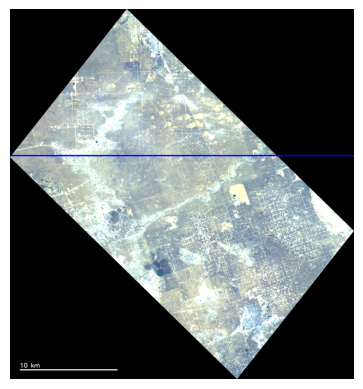

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import traceback
import cv2 # <-- OpenCV をインポート

# ---  helper functions (for this cell) ---

def find_closest_wavelength(wavelength_tuples, target_wave_val):
    """
    ソート済みの(波長[float], 列名[str])タプルのリストから、
    target_wave_valに最も近い波長を見つけ、その列名と両隣の列名を返す。
    """
    if not wavelength_tuples:
        raise ValueError("Wavelength list is empty.")
    wave_floats = np.array([w[0] for w in wavelength_tuples])
    idx = np.searchsorted(wave_floats, target_wave_val, side='left')
    
    target_index = -1
    if idx == 0: target_index = 0
    elif idx == len(wave_floats): target_index = len(wave_floats) - 1
    else:
        dist_left = target_wave_val - wave_floats[idx - 1]
        dist_right = wave_floats[idx] - target_wave_val
        if dist_left < dist_right: target_index = idx - 1
        else: target_index = idx
            
    if target_index == 0:
        raise ValueError(f"Target {target_wave_val} matches {wave_floats[target_index]}, which is the first band. Cannot check neighbors.")
    if target_index == len(wave_floats) - 1:
        raise ValueError(f"Target {target_wave_val} matches {wave_floats[target_index]}, which is the last band. Cannot check neighbors.")

    target_col = wavelength_tuples[target_index][1]
    left_col = wavelength_tuples[target_index - 1][1]
    right_col = wavelength_tuples[target_index + 1][1]
    
    print(f"Target: {target_wave_val}nm -> Closest match: {wave_floats[target_index]}nm (Column: {target_col})")
    
    return target_col, left_col, right_col, wave_floats[target_index]

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# (作成済みのCSVファイル)
FILE_PATH = "all_pixel_spectra_2x1230.csv" 

# スライスの定義 (CSV作成時と一致させる)
SLICE_CENTER = [750, 750]
Y_RANGE = [SLICE_CENTER[0] - 1, SLICE_CENTER[0] + 1]  # (749, 751)
X_RANGE = [SLICE_CENTER[1] - 730, SLICE_CENTER[1] + 500] # (20, 1250)

# 解析したい「グローバルY座標」 (750)
TARGET_Y_GLOBAL = 750

# 検出したい波長（近似値）と閾値
ANOMALY_CHECKS = [
    (1675.395, 0.0), # local max
    (1625.435, 3.0), # local max + 3.0
]

# 描画する線の設定
LINE_THICKNESS = 5 # 線の太さ
ANOMALY_LINE_COLOR_BGR = (0, 0, 255) # (OpenCV BGR 順) 0, 0, 255 = 赤
TARGET_Y_LINE_COLOR_BGR = (255, 0, 0) # (OpenCV BGR 順) 255, 0, 0 = 青

# 画像のフルサイズ (線の終点計算用)
FULL_IMAGE_SHAPE = (1793, 1892) # (height, width)
# =========================================================


try:
    # --- 1. グローバルY座標をローカルY座標に変換 ---
    Y_OFFSET = Y_RANGE[0] # 749
    TARGET_Y_LOCAL = TARGET_Y_GLOBAL - Y_OFFSET # 750 - 749 = 1
    X_OFFSET = X_RANGE[0] # 20
    print(f"Analyzing Global Y={TARGET_Y_GLOBAL} (Local Y={TARGET_Y_LOCAL} in CSV)")

    # --- 2. データの読み込みと準備 ---
    print(f"Loading spectral data from: {FILE_PATH}")
    df_all_spectra = pd.read_csv(FILE_PATH)

    print(f"Filtering for local y = {TARGET_Y_LOCAL}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y_LOCAL].copy()
    
    if df_y_target.empty:
        raise ValueError(f"No data found for local y = {TARGET_Y_LOCAL}. Did you run Step 1 to recreate the CSV?")
    
    print(f"Found {len(df_y_target)} pixels (x_local 0 to {len(df_y_target)-1})")
    
    # --- 3. 波長リストの解析 ---
    print("Parsing wavelengths from CSV headers...")
    wavelength_cols = [col for col in df_y_target.columns if col.startswith('wave_')]
    wavelength_tuples = []
    for col in wavelength_cols:
        try:
            wave_float = float(re.findall(r"[-+]?\d*\.\d+|\d+", col)[0])
            wavelength_tuples.append((wave_float, col))
        except Exception:
            pass
    wavelength_tuples.sort(key=lambda x: x[0]) # 波長でソート

    # --- (グラフ描画コード) ---
    print("Generating full-range plot...")
    wavelengths_sorted_num = np.array([w[0] for w in wavelength_tuples])
    wavelengths_sorted_cols = [w[1] for w in wavelength_tuples]
    fig, ax = plt.subplots(figsize=(15, 8))
    min_x = df_y_target['x'].min(); max_x = df_y_target['x'].max()
    norm = plt.Normalize(vmin=min_x, vmax=max_x); cmap = plt.cm.jet
    for index, row in df_y_target.iterrows():
        ax.plot(wavelengths_sorted_num, row[wavelengths_sorted_cols].values.astype(float), color=cmap(norm(row['x'])), alpha=0.7, linewidth=1)
    
    # ★★★ 修正 (ScalarMMappable -> ScalarMappable) ★★★
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    # ★★★ 修正ここまで ★★★

    cbar = fig.colorbar(sm, ax=ax, pad=0.01); cbar.set_label('X Coordinate (Pixel Column)')
    ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y_GLOBAL} (Full Range)', fontsize=16)
    ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Spectral Value (Radiance)')
    ax.grid(True, linestyle='--', alpha=0.6); ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))
    plt.tight_layout(); plt.savefig(f"spectra_y_{TARGET_Y_GLOBAL}_plot.png"); plt.close(fig)
    print(f"Saved full-range plot: spectra_y_{TARGET_Y_GLOBAL}_plot.png")
    # ... (Band 1, Band 2 のプロットも同様に実行) ...

    # --- 4. 異常検出 (ループ処理) ---
    all_spiky_x_local = set() # 異常なx_local座標を格納するセット

    for wave_val, threshold in ANOMALY_CHECKS:
        print(f"\n--- Detecting anomalies for approx {wave_val}nm (Threshold > {threshold}) ---")
        try:
            target_col, left_col, right_col, actual_wave = find_closest_wavelength(wavelength_tuples, wave_val)
            condition = (
                (df_y_target[target_col] > (df_y_target[left_col] + threshold)) &
                (df_y_target[target_col] > (df_y_target[right_col] + threshold))
            )
            spiky_pixels_df = df_y_target[condition]
            
            if spiky_pixels_df.empty:
                print(f"Result: No pixels found with a spike at {actual_wave}nm (Threshold > {threshold}).")
            else:
                print(f"Result: Found {len(spiky_pixels_df)} pixels with a spike at {actual_wave}nm (Threshold > {threshold}):")
                print("  x_local | x_global | Left Val | Target Val | Right Val")
                print("-" * 60)
                for index, row in spiky_pixels_df.iterrows():
                    x_loc = int(row['x']); x_glob = x_loc + X_OFFSET
                    print(f"  {x_loc:7} | {x_glob:8} | {row[left_col]:8.4f} | {row[target_col]:10.4f} | {row[right_col]:8.4f}")
                    all_spiky_x_local.add(x_loc)
        except Exception as e_wave:
            print(f"Error processing wavelength {wave_val}: {e_wave}")
            traceback.print_exc()

    # --- 5. 描画処理 ---
    print("\n--- Drawing Anomalies and Scale Bar on Image ---")
    
    if 'ims' not in locals() or 'show_img' not in locals():
        raise NameError("Variables 'ims' (full RGB image) and 'show_img' (display function) are not defined.")

    # A. 元の 'ims' (float, RGB) をコピー
    ims_to_draw = ims.copy()
    
    if ims.shape[0] != FULL_IMAGE_SHAPE[0] or ims.shape[1] != FULL_IMAGE_SHAPE[1]:
        print(f"Warning: 'ims' shape {ims.shape[:2]} does not match user-provided shape {FULL_IMAGE_SHAPE}.")
        print(f"Using actual 'ims' shape {ims.shape[:2]} for drawing.")
        h, w = ims.shape[:2]
    else:
        h, w = FULL_IMAGE_SHAPE
        print(f"Confirmed 'ims' shape: ({h}, {w}).")
        
    diag_length = int(np.sqrt(h**2 + w**2)) + 10 # 確実に端を越えるように

    # B. [Normalization] float -> uint8 (スケールバー描画のため)
    print("Normalizing image (float to uint8) for drawing...")
    min_val = np.min(ims_to_draw)
    max_val = np.max(ims_to_draw)
    
    ims_rgb_uint8 = np.zeros(ims_to_draw.shape, dtype=np.uint8)
    if max_val > min_val:
        ims_normalized = (ims_to_draw - min_val) / (max_val - min_val)
        ims_rgb_uint8 = (ims_normalized * 255.0).astype(np.uint8)
    
    print(f"Normalized. Min: {np.min(ims_rgb_uint8)}, Max: {np.max(ims_rgb_uint8)}")

    # C. [Color Conversion] RGB -> BGR (for cv2)
    print("Converting RGB -> BGR for OpenCV...")
    ims_bgr_uint8 = cv2.cvtColor(ims_rgb_uint8, cv2.COLOR_RGB2BGR) # 修正済み

    # D. [Anomaly Lines] 正規化後の BGR 画像に「端まで届く」太い線を描画
    if not all_spiky_x_local:
        print("No anomalous pixels found to draw.")
    else:
        print(f"Found {len(all_spiky_x_local)} unique anomalous pixels to draw diagonal lines (Thickness={LINE_THICKNESS})...")

        for x_local in sorted(list(all_spiky_x_local)):
            y_glob = TARGET_Y_LOCAL + Y_OFFSET # 750
            x_glob = x_local + X_OFFSET       # x_local + 20
            
            print(f"Drawing anomaly lines from (y_glob, x_glob) = ({y_glob}, {x_glob})")

            # 左上 (Top-Left) への線
            x1_tl = x_glob - diag_length
            y1_tl = y_glob - diag_length
            cv2.line(ims_bgr_uint8, (x_glob, y_glob), (x1_tl, y1_tl), 
                     ANOMALY_LINE_COLOR_BGR, LINE_THICKNESS)
            
            # 右下 (Bottom-Right) への線
            x1_br = x_glob + diag_length
            y1_br = y_glob + diag_length
            cv2.line(ims_bgr_uint8, (x_glob, y_glob), (x1_br, y1_br), 
                     ANOMALY_LINE_COLOR_BGR, LINE_THICKNESS)

    # E. [Scale Bar] cv2でBGR画像にスケールバーを描画
    print("Drawing scale bar...")
    one_pixel_meter = 20.0
    scale_bar_meters = 10000
    scale_bar_pixels = int(scale_bar_meters / one_pixel_meter) # 500
    
    margin_px = 50
    bar_thickness = 5
    text_font_scale = 1.0
    text_thickness = 2
    
    bar_x_start = margin_px
    bar_y_start = h - margin_px # h (画像の高さ) を使用
    bar_x_end = bar_x_start + scale_bar_pixels
    bar_y_end = bar_y_start + bar_thickness
    text_x = bar_x_start
    text_y = bar_y_start - 10
    
    color_bgr_white = (255, 255, 255) # (B, G, R) for white
    
    cv2.rectangle(ims_bgr_uint8, (bar_x_start, bar_y_start), (bar_x_end, bar_y_end), color_bgr_white, -1)
    cv2.putText(ims_bgr_uint8, "10 km", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 
                text_font_scale, color_bgr_white, text_thickness, lineType=cv2.LINE_AA)

    # E2: [ターゲットYの線を描画]
    print(f"Drawing horizontal line at y = {TARGET_Y_GLOBAL}...")
    # 始点 (0, 750), 終点 (w, 750)
    cv2.line(ims_bgr_uint8, (0, TARGET_Y_GLOBAL), (w, TARGET_Y_GLOBAL), 
             TARGET_Y_LINE_COLOR_BGR, LINE_THICKNESS)

    # F. [Save] BGR画像を保存
    output_filename_cv2 = "anomalies_and_scale_bar_full_lines.png"
    cv2.imwrite(output_filename_cv2, ims_bgr_uint8)
    print(f"Image with FULL lines, Y-line, and scale bar saved to: {output_filename_cv2}")

    # G. [Display] BGR -> RGB に戻して show_img で表示
    print("Displaying final image (converting BGR back to RGB for matplotlib)...")
    ims_final_rgb_display = cv2.cvtColor(ims_bgr_uint8, cv2.COLOR_BGR2RGB) # 修正済み
        
    show_img(ims_final_rgb_display)

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("!!! Please run STEP 1 first to create the CSV file for the new slice !!!")
except NameError as e:
    print(f"\nError: {e}")
    print("Please ensure 'ims' (the full RGB image), 'show_img', 'img', 'param', and 'save_all_spectra_to_csv' are defined in a previous cell.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

Slice Y_RANGE: [np.int64(60), np.int64(140)], X_RANGE: [np.int64(560), np.int64(640)]
Set TARGET_Y_GLOBAL to slice center: 100
Using display image shape from 'ims_slice': (80, 80)
Analyzing Global Y=100 (Local Y=40 in slice)
Preparing data from 'img_slice'...
Created DataFrame from img_slice (Shape: (6400, 187))
Parsing wavelengths from 'wavelengths' variable...
Filtering for local y = 40...
Found 80 pixels (x_local 0 to 79)
Generating full-range plot...
Saved full-range plot: spectra_y_100_plot_slice_range.png

--- Detecting anomalies for approx 1675.395nm (Threshold > 0.0) ---
Target: 1675.395nm -> Closest match: 1675.395nm (Column: wave_1675.39nm)
Result: Found 3 pixels with a spike at 1675.395nm (Threshold > 0.0):
   x_local | x_global | Left Val | Target Val | Right Val
------------------------------------------------------------
        15 |      575 |  15.1264 |    17.0944 |  15.7632
        16 |      576 |  15.2000 |    20.1952 |  17.7120
        17 |      577 |  15.2896 |    1

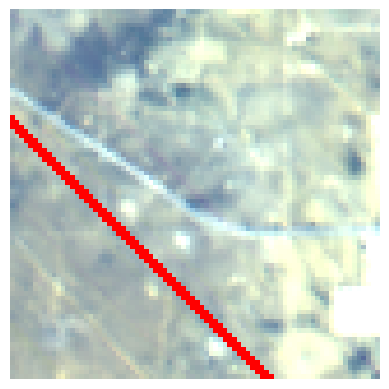

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import traceback
import cv2 # <-- OpenCV をインポート

# ---  helper functions (for this cell) ---

def find_closest_wavelength(wavelength_tuples, target_wave_val):
    """
    ソート済みの(波長[float], 列名[str])タプルのリストから、
    target_wave_valに最も近い波長を見つけ、その列名と両隣の列名を返す。
    """
    if not wavelength_tuples:
        raise ValueError("Wavelength list is empty.")
    wave_floats = np.array([w[0] for w in wavelength_tuples])
    idx = np.searchsorted(wave_floats, target_wave_val, side='left')
    
    target_index = -1
    if idx == 0: target_index = 0
    elif idx == len(wave_floats): target_index = len(wave_floats) - 1
    else:
        dist_left = target_wave_val - wave_floats[idx - 1]
        dist_right = wave_floats[idx] - target_wave_val
        if dist_left < dist_right: target_index = idx - 1
        else: target_index = idx
            
    if target_index == 0:
        raise ValueError(f"Target {target_wave_val} matches {wave_floats[target_index]}, which is the first band. Cannot check neighbors.")
    if target_index == len(wave_floats) - 1:
        raise ValueError(f"Target {target_wave_val} matches {wave_floats[target_index]}, which is the last band. Cannot check neighbors.")

    target_col = wavelength_tuples[target_index][1]
    left_col = wavelength_tuples[target_index - 1][1]
    right_col = wavelength_tuples[target_index + 1][1]
    
    print(f"Target: {target_wave_val}nm -> Closest match: {wave_floats[target_index]}nm (Column: {target_col})")
    
    return target_col, left_col, right_col, wave_floats[target_index]

# =========================================================
# --- ユーザー設定 ---
# =========================================================
# (img_slice, wavelengths, slice_y_range, slice_x_range, img, ims, ims_slice, show_img が前のセルで定義されている前提)

# スライスの定義 (独立変数から取得)
try:
    Y_RANGE = slice_y_range # (例: [60, 140])
    X_RANGE = slice_x_range # (例: [560, 640])
    print(f"Slice Y_RANGE: {Y_RANGE}, X_RANGE: {X_RANGE}")
except NameError:
    print("Warning: Variables 'slice_y_range' or 'slice_x_range' are not defined. Using fallback.")
    # フォールバック (元のコードの値)
    SLICE_CENTER = [100, 600] # 前の会話で設定された center
    Y_RANGE = [SLICE_CENTER[0] - 40, SLICE_CENTER[0] + 40]  # (60, 140)
    X_RANGE = [SLICE_CENTER[1] - 40, SLICE_CENTER[1] + 40] # (560, 640)

# 解析したい「グローバルY座標」 (以前は750でしたが、スライス範囲内に変更が必要)
# スライスの中心Y座標 (グローバル) を使用するか、スライス内の任意のグローバルYを指定
# 例: スライスの中心Y座標を使用する場合
TARGET_Y_GLOBAL = int(Y_RANGE[0] + (Y_RANGE[1] - Y_RANGE[0]) / 2) # (60 + (140-60)/2) = 100
print(f"Set TARGET_Y_GLOBAL to slice center: {TARGET_Y_GLOBAL}")


# 検出したい波長（近似値）と閾値
ANOMALY_CHECKS = [
    (1675.395, 0.0), # local max
    (1625.435, 3.0), # local max + 3.0
]

# 描画する線の設定
LINE_THICKNESS = 1 # 線の太さ
ANOMALY_LINE_COLOR_BGR = (0, 0, 255) # (OpenCV BGR 順) 0, 0, 255 = 赤

# 画像のフルサイズ (imgから取得)
# img_slice に描画するため、ここでは img_slice のサイズが重要になる
try:
    DISPLAY_IMAGE_SHAPE = ims_slice.shape[:2] # (height, width)
    print(f"Using display image shape from 'ims_slice': {DISPLAY_IMAGE_SHAPE}")
except NameError:
    print("Warning: Variable 'ims_slice' is not defined. Using fallback shape (80, 80).")
    DISPLAY_IMAGE_SHAPE = (80, 80) # (height, width) - ims_slice のデフォルトサイズ


# =========================================================


try:
    # --- 1. グローバルY座標をローカルY座標に変換 ---
    Y_OFFSET = Y_RANGE[0] # (例: 60)
    TARGET_Y_LOCAL = TARGET_Y_GLOBAL - Y_OFFSET # (例: 100 - 60 = 40)
    X_OFFSET = X_RANGE[0] # (例: 560)
    print(f"Analyzing Global Y={TARGET_Y_GLOBAL} (Local Y={TARGET_Y_LOCAL} in slice)")

    # --- 2. データの準備 (img_slice から DataFrame を作成) ---
    print("Preparing data from 'img_slice'...")
    
    if 'img_slice' not in locals():
        raise NameError("'img_slice' (the data slice) is not defined.")
    if 'wavelengths' not in locals():
        raise NameError("'wavelengths' list is not defined.")
        
    H_slice, W_slice, C_slice = img_slice.shape # スライス画像の高さ、幅、チャンネル数
    # H_slice, W_slice は DISPLAY_IMAGE_SHAPE と一致するはず
    
    if len(wavelengths) != C_slice:
        raise ValueError(f"img_slice channel count ({C_slice}) does not match wavelength count ({len(wavelengths)}).")

    # 波長カラム名を 'wave_XXX.Xnm' 形式で作成
    wavelength_cols = [f"wave_{w:.2f}nm" for w in wavelengths]

    # img_slice (H_slice, W_slice, C_slice) を (H_slice*W_slice, C_slice) の2D配列にリシェイプ
    data_2d = img_slice.reshape(-1, C_slice)

    # DataFrameを作成
    df_all_spectra = pd.DataFrame(data_2d, columns=wavelength_cols)

    # y, x のローカル座標を追加
    y_coords, x_coords = np.mgrid[0:H_slice, 0:W_slice]
    df_all_spectra['y'] = y_coords.ravel() # ローカル y (0 から H_slice-1)
    df_all_spectra['x'] = x_coords.ravel() # ローカル x (0 から W_slice-1)
    
    # y, x を先頭の列に移動
    cols = ['y', 'x'] + wavelength_cols
    df_all_spectra = df_all_spectra[cols]

    print(f"Created DataFrame from img_slice (Shape: {df_all_spectra.shape})")

    # --- 3. 波長リストの解析 (wavelengths 変数から) ---
    print("Parsing wavelengths from 'wavelengths' variable...")
    wavelength_tuples = list(zip(wavelengths, wavelength_cols))
    wavelength_tuples.sort(key=lambda x: x[0])

    # --- 4. 解析対象行のフィルタリング ---
    print(f"Filtering for local y = {TARGET_Y_LOCAL}...")
    df_y_target = df_all_spectra[df_all_spectra['y'] == TARGET_Y_LOCAL].copy()
    
    if df_y_target.empty:
        raise ValueError(f"No data found for local y = {TARGET_Y_LOCAL}. Check if TARGET_Y_GLOBAL is within slice_y_range.")
    
    print(f"Found {len(df_y_target)} pixels (x_local 0 to {len(df_y_target)-1})")

    # --- (グラフ描画コード) ---
    print("Generating full-range plot...")
    wavelengths_sorted_num = np.array([w[0] for w in wavelength_tuples])
    wavelengths_sorted_cols = [w[1] for w in wavelength_tuples]
    fig, ax = plt.subplots(figsize=(15, 8))
    min_x = df_y_target['x'].min(); max_x = df_y_target['x'].max()
    norm = plt.Normalize(vmin=min_x, vmax=max_x); cmap = plt.cm.jet
    for index, row in df_y_target.iterrows():
        ax.plot(wavelengths_sorted_num, row[wavelengths_sorted_cols].values.astype(float), color=cmap(norm(row['x'])), alpha=0.7, linewidth=1)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, pad=0.01); cbar.set_label('X Coordinate (Pixel Column)')
    ax.set_title(f'Spectra for All Pixels at y = {TARGET_Y_GLOBAL} (Full Range)', fontsize=16)
    ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Spectral Value (Radiance)')
    ax.grid(True, linestyle='--', alpha=0.6); ax.set_xlim(min(wavelengths_sorted_num), max(wavelengths_sorted_num))
    plt.tight_layout(); plt.savefig(f"spectra_y_{TARGET_Y_GLOBAL}_plot_slice_range.png"); plt.close(fig)
    print(f"Saved full-range plot: spectra_y_{TARGET_Y_GLOBAL}_plot_slice_range.png")

    # --- 4. 異常検出 (ループ処理) ---
    all_spiky_x_local = set() # 異常なx_local座標を格納するセット

    for wave_val, threshold in ANOMALY_CHECKS:
        print(f"\n--- Detecting anomalies for approx {wave_val}nm (Threshold > {threshold}) ---")
        try:
            target_col, left_col, right_col, actual_wave = find_closest_wavelength(wavelength_tuples, wave_val)
            
            df_y_target[target_col] = df_y_target[target_col].astype(float)
            df_y_target[left_col] = df_y_target[left_col].astype(float)
            df_y_target[right_col] = df_y_target[right_col].astype(float)

            condition = (
                (df_y_target[target_col] > (df_y_target[left_col] + threshold)) &
                (df_y_target[target_col] > (df_y_target[right_col] + threshold))
            )
            spiky_pixels_df = df_y_target[condition]
            
            if spiky_pixels_df.empty:
                print(f"Result: No pixels found with a spike at {actual_wave}nm (Threshold > {threshold}).")
            else:
                print(f"Result: Found {len(spiky_pixels_df)} pixels with a spike at {actual_wave}nm (Threshold > {threshold}):")
                print("   x_local | x_global | Left Val | Target Val | Right Val")
                print("-" * 60)
                for index, row in spiky_pixels_df.iterrows():
                    x_loc = int(row['x']); x_glob = x_loc + X_OFFSET
                    print(f"   {x_loc:7} | {x_glob:8} | {row[left_col]:8.4f} | {row[target_col]:10.4f} | {row[right_col]:8.4f}")
                    all_spiky_x_local.add(x_loc)
        except Exception as e_wave:
            print(f"Error processing wavelength {wave_val}: {e_wave}")
            traceback.print_exc()

    # --- 5. 描画処理 (ims_slice に線を描画) ---
    
    print("\n--- Drawing Anomalies on ims_slice ---")
    
    if 'ims_slice' not in locals() or 'show_img' not in locals():
        raise NameError("Variables 'ims_slice' (display image slice) and 'show_img' (display function) are not defined.")

    # A. 元の 'ims_slice' (float, RGB) をコピー
    ims_slice_to_draw = ims_slice.copy()
    
    h_slice, w_slice = DISPLAY_IMAGE_SHAPE # ims_slice の高さと幅
    print(f"Confirmed 'ims_slice' shape: ({h_slice}, {w_slice}).")
        
    diag_length_slice = int(np.sqrt(h_slice**2 + w_slice**2)) + 10 # 確実に端を越えるように

    # B. [Normalization] float -> uint8 (OpenCV描画のため)
    # ims_slice は get_rgb で既に 0.0-1.0 に正規化されている前提
    print("Converting ims_slice (float to uint8) for drawing...")
    ims_rgb_uint8_slice = (ims_slice_to_draw * 255.0).astype(np.uint8)
    
    print(f"Converted. Min: {np.min(ims_rgb_uint8_slice)}, Max: {np.max(ims_rgb_uint8_slice)}")

    # C. [Color Conversion] RGB -> BGR (for cv2)
    print("Converting RGB -> BGR for OpenCV...")
    ims_bgr_uint8_slice = cv2.cvtColor(ims_rgb_uint8_slice, cv2.COLOR_RGB2BGR)

    # D. [Anomaly Lines] BGR 画像に「端まで届く」太い線を描画
    if not all_spiky_x_local:
        print("No anomalous pixels found to draw.")
    else:
        print(f"Found {len(all_spiky_x_local)} unique anomalous pixels to draw diagonal lines (Thickness={LINE_THICKNESS})...")

        for x_local in sorted(list(all_spiky_x_local)):
            y_local_draw = TARGET_Y_LOCAL # スライス内でのY座標
            x_local_draw = x_local       # スライス内でのX座標
            
            print(f"Drawing anomaly lines from (y_local, x_local) = ({y_local_draw}, {x_local_draw}) in ims_slice")

            # 左上 (Top-Left) への線 (スライス内の座標で計算)
            x1_tl_slice = x_local_draw - diag_length_slice
            y1_tl_slice = y_local_draw - diag_length_slice
            cv2.line(ims_bgr_uint8_slice, (x_local_draw, y_local_draw), (x1_tl_slice, y1_tl_slice), 
                     ANOMALY_LINE_COLOR_BGR, LINE_THICKNESS)
            
            # 右下 (Bottom-Right) への線 (スライス内の座標で計算)
            x1_br_slice = x_local_draw + diag_length_slice
            y1_br_slice = y_local_draw + diag_length_slice
            cv2.line(ims_bgr_uint8_slice, (x_local_draw, y_local_draw), (x1_br_slice, y1_br_slice), 
                     ANOMALY_LINE_COLOR_BGR, LINE_THICKNESS)

    # E. [Scale Bar] (削除)

    # F. [Save] BGR画像を保存
    output_filename_cv2_slice = f"anomalies_on_slice_y{TARGET_Y_GLOBAL}_lines.png"
    cv2.imwrite(output_filename_cv2_slice, ims_bgr_uint8_slice)
    print(f"Image with anomaly lines on slice saved to: {output_filename_cv2_slice}")

    # G. [Display] BGR -> RGB に戻して show_img で表示
    print("Displaying final image (converting BGR back to RGB for matplotlib)...")
    ims_final_rgb_display_slice = cv2.cvtColor(ims_bgr_uint8_slice, cv2.COLOR_BGR2RGB)
        
    show_img(ims_final_rgb_display_slice)
    
except NameError as e:
    print(f"\nError: {e}")
    print("!!! このセルを実行する前に、'ims', 'show_img', 'img', 'wavelengths', 'slice_y_range', 'slice_x_range', 'img_slice', 'ims_slice' が定義されていることを確認してください。 !!!")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    traceback.print_exc()

In [18]:
# 'param' 配列 (185, 5) から波長リスト（1D）を抽出
# param の0列目('CenterWavelengthNanometer') を 'wavelengths' に格納
wavelengths = param[:, 0]

# 'center' から slice_y_range と slice_x_range を計算
y_start = center[0] - 40
y_end = center[0] + 40
x_start = center[1] - 40
x_end = center[1] + 40

slice_y_range = [y_start, y_end]
slice_x_range = [x_start, x_end]

print(f"Variable 'wavelengths' created (185 values, min: {wavelengths.min()}nm, max: {wavelengths.max()}nm)")
print(f"Variable 'slice_y_range' created: {slice_y_range}")
print(f"Variable 'slice_x_range' created: {slice_x_range}")
print("---")
print("これで、前回作成した異常検出コードを実行する準備が整いました。")

Variable 'wavelengths' created (185 values, min: 405.0nm, max: 2474.755nm)
Variable 'slice_y_range' created: [np.int64(60), np.int64(140)]
Variable 'slice_x_range' created: [np.int64(560), np.int64(640)]
---
これで、前回作成した異常検出コードを実行する準備が整いました。
